In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# File system manangement
import os


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src import utils  
from src.config import Config as cfg  


TARGET = cfg.TARGET

# -------------------------------------------------------


from sklearn.model_selection import train_test_split

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



sys.path contains: /home/ismail/x42


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Load Data

In [2]:
from sklearn.model_selection import train_test_split


df_train = pd.read_csv("../test_data.csv")
df_target = df_train[TARGET]
df_train.drop(columns=[TARGET], inplace=True)


X_train, X_test, y_train, y_test = train_test_split(df_train, df_target, test_size=0.3, random_state=42, stratify=df_target)

In [ ]:
# X_train = df_train.drop(columns=[TARGET]) # delete id if exists
# y_train = df_train[TARGET]

X_train_original = X_train.copy()
X_test_original = X_test.copy()
y_train_original = y_train.copy()
y_test_original = y_test.copy()


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (80024, 132)
X_test shape: (34297, 132)


In [13]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)


### Load data

In [4]:
# -------------------------------
# Load Data
# -------------------------------
from src.data_loader import load_data, prepare_data


X_train, X_test, y_train, y_test = load_data("raw")
# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

# Ensure y is numpy array
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None

Number of classes: 2
X_train shape: (80024, 131)
X_test shape: (34297, 131)
y_train shape: (80024,)
y_test shape: (34297,)
Test IDs available: 34297


### Create folds

In [5]:
from src.data_splitter import DataSplitter

# ⚠️ If you don’t set folds_path, it will generate new random splits every time you call split().
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=3,
    random_state=42,
    # random_states=[42, 1337],  # multi-seed CV
    folds_path="data/folds.npy" # folds_xgb.npy?
)

folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))


✅ Loaded 3 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 3
Random seeds: [42]
Dataset size: 80024
Total folds: 3

Fold 0: Train size=53349, Val size=26675
Fold 1: Train size=53349, Val size=26675
Fold 2: Train size=53350, Val size=26674


In [ ]:
# clean columns

# import re
# def clean_feature_names(data):
#     cleaned_columns = []
#     for column in data.columns:
#         cleaned_column = re.sub('[^A-Za-z0-9_]+', '', column)
#         cleaned_columns.append(cleaned_column)
#     data.columns = cleaned_columns
#     return data


# df_train = clean_feature_names(df_train)
# X_test = clean_feature_names(X_test)
# df_train.columns

In [16]:
X_train.head()

,claim_amount_ratio,risk_score,claim_type,deductible_ratio,premium_payment_score,claim_reserve_amount,policy_value_score,days_since_policy_start,months_since_last_claim,claim_processing_days,...,payment_timeliness_score,claim_submission_completeness,follow_up_responsiveness_score,location_code,composite_risk_index,expedited_processing_score,claim_quality_index,customer_value_score,regulatory_compliance_score,final_decision_confidence
0,4.518807,6.198475,NaN,4.167944,10.345954,2.794333,1.983391,2.009122,11.799164,5.382933,...,9.958159,2.443859,1.975576,G,1.337431,1.337324,3.329780,0,2.305420,4.273505
1,1.007260,3.644213,C,2.496826,8.100906,1.899576,1.748336,5.610209,9.730942,0.218818,...,6.771300,5.915523,0.960236,CJ,1.445901,2.416061,1.528419,0,4.290658,0.580646
2,2.900623,3.609802,C,1.767901,8.340933,2.729997,1.650911,1.697892,9.393940,1.028447,...,6.902358,10.408994,1.268827,BY,1.467900,0.890592,1.418072,0,4.368716,1.739130
3,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,2.100657,...,NaN,NaN,NaN,BM,NaN,NaN,NaN,0,NaN,NaN
4,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,2.341358,...,NaN,NaN,NaN,L,NaN,NaN,NaN,0,NaN,NaN


In [17]:
X_test.head()

,claim_amount_ratio,risk_score,claim_type,deductible_ratio,premium_payment_score,claim_reserve_amount,policy_value_score,days_since_policy_start,months_since_last_claim,claim_processing_days,...,payment_timeliness_score,claim_submission_completeness,follow_up_responsiveness_score,location_code,composite_risk_index,expedited_processing_score,claim_quality_index,customer_value_score,regulatory_compliance_score,final_decision_confidence
0,1.769230,13.330271,NaN,7.921093,11.143242,2.561330,2.632017,0.170329,3.786982,5.251642,...,3.313610,1.525681,2.357001e-01,AR,1.490690,3.165281,9.428549,0,0.751974,3.865546
1,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,1.050329,...,NaN,NaN,NaN,CD,NaN,NaN,NaN,0,NaN,NaN
2,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,1.312910,...,NaN,NaN,NaN,AE,NaN,NaN,NaN,0,NaN,NaN
3,0.534167,10.983313,C,3.781044,8.211163,1.924927,2.810395,0.092599,11.005918,1.575492,...,8.757397,2.162110,-5.806322e-07,AL,1.557971,5.269490,1.381846,0,1.356164,0.606060
4,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,0.787746,...,NaN,NaN,NaN,CD,NaN,NaN,NaN,0,NaN,NaN


In [6]:
def print_duplicates(df, name):
    dup_count = df.duplicated().sum()
    total = len(df)
    print(f"{name}: {dup_count} duplicate rows ({dup_count / total:.2%})")

print_duplicates(df_train, "Train")
print_duplicates(X_test, "Test")


Train: 0 duplicate rows (0.00%)
Test: 0 duplicate rows (0.00%)


In [7]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()



from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)


# y_train_int = y_train.astype(int)
y_train_int = y_train_enc


all_cols = set(X_train.columns)
used_cols = set(cat_cols + num_cols)

leftover_cols = list(all_cols - used_cols)
print("Columns not in cat_cols or num_cols:", leftover_cols)

Columns not in cat_cols or num_cols: []


In [8]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (80024, 131)
X_test: (34297, 131)


**Take a First Look of our Data:**

I created the function below to simplify the analysis of general characteristics of the data. Inspired on the str function of R, this function returns the types, counts, distinct, count nulls, missing ratio and uniques values of each field/feature.

If the study involve some supervised learning, this function can return the study of the correlation, for this we just need provide the dependent variable to the pred parameter.

Also, if its return is stored in a variable you can evaluate it in more detail, focus on specific field, or sort them from different perspectives.

In [9]:
# from regex import T
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.width', None)

# def rstr(df, pred=None, rare_thresh=0.01):
#     obs = df.shape[0]

#     # =========================
#     # BASIC INFO
#     # =========================
#     types = df.dtypes
#     counts = df.count()
#     nulls = df.isnull().sum()
#     missing_ratio = (nulls / obs) * 100
#     distincts = df.nunique()

#     # =========================
#     # TOP VALUES (informative)
#     # =========================
#     top_values = df.apply(lambda x: x.value_counts().head(3).to_dict())

#     # =========================
#     # NUMERIC STATS
#     # =========================
#     num_df = df.select_dtypes(include=[np.number])

#     skewness = pd.Series(index=df.columns, dtype=float)
#     skewness.loc[num_df.columns] = num_df.skew()

#     # =========================
#     # CORRELATION (linear)
#     # =========================
#     if pred is not None and pred in num_df.columns:
#         corr = num_df.corr()[pred]
#         corr_col = 'corr_' + pred
#     else:
#         corr = pd.Series(index=df.columns, dtype=float)
#         corr_col = 'corr_' + str(pred)

#     # =========================
#     # RARE CATEGORY DETECTION
#     # =========================
#     def rare_ratio(col):
#         if col.dtype == "object" or col.nunique() < 50:
#             freq = col.value_counts(normalize=True)
#             return freq[freq < rare_thresh].sum()
#         return np.nan

#     rare_ratio_col = df.apply(rare_ratio)

#     # =========================
#     # DOMINANT VALUE (imbalance)
#     # =========================
#     dominant_ratio = df.apply(lambda x: x.value_counts(normalize=True).iloc[0])

#     # =========================
#     # ZERO RATIO (important for sparse)
#     # =========================
#     zero_ratio = (df == 0).sum() / obs

#     # =========================
#     # CARDINALITY TYPE
#     # =========================
#     def cardinality_type(n):
#         if n < 10:
#             return "low"
#         elif n < 50:
#             return "medium"
#         else:
#             return "high"

#     cardinality = distincts.apply(cardinality_type)

#     # =========================
#     # ID-LIKE DETECTION
#     # =========================
#     is_id_like = (distincts / obs) > 0.95

#     # =========================
#     # COMBINE
#     # =========================
#     result = pd.concat([
#         types, counts, distincts, nulls, missing_ratio,
#         top_values, skewness,
#         rare_ratio_col, dominant_ratio, zero_ratio,
#         cardinality, is_id_like,
#         corr
#     ], axis=1)

#     result.columns = [
#         'type', 'count', 'distincts', 'nulls', 'missing_%',
#         'top_values', 'skewness',
#         'rare_%', 'dominant_%', 'zero_%',
#         'cardinality', 'is_id_like',
#         corr_col
#     ]

#     # =========================
#     # PRINT SUMMARY
#     # =========================
#     print('Shape:', df.shape)
#     print('Types:\n', result['type'].value_counts())
#     print('-----------------------------')

#     return result

# X_train_tmp = X_train.copy()
# X_train_tmp[TARGET] = y_train

# details = rstr(X_train_tmp, TARGET)
# display(details.sort_values(by='corr_' + TARGET, ascending=False))

# del X_train_tmp

In [10]:
X_train_original.head(5)

NameError: name 'X_train_original' is not defined

In [ ]:
X_train.head(5)

,claim_amount_ratio,risk_score,claim_type,deductible_ratio,premium_payment_score,claim_reserve_amount,policy_value_score,days_since_policy_start,months_since_last_claim,claim_processing_days,...,payment_timeliness_score,claim_submission_completeness,follow_up_responsiveness_score,location_code,composite_risk_index,expedited_processing_score,claim_quality_index,customer_value_score,regulatory_compliance_score,final_decision_confidence
0,4.518807,6.198475,NaN,4.167944,10.345954,2.794333,1.983391,2.009122,11.799164,5.382933,...,9.958159,2.443859,1.975576,G,1.337431,1.337324,3.329780,0,2.305420,4.273505
1,1.007260,3.644213,C,2.496826,8.100906,1.899576,1.748336,5.610209,9.730942,0.218818,...,6.771300,5.915523,0.960236,CJ,1.445901,2.416061,1.528419,0,4.290658,0.580646
2,2.900623,3.609802,C,1.767901,8.340933,2.729997,1.650911,1.697892,9.393940,1.028447,...,6.902358,10.408994,1.268827,BY,1.467900,0.890592,1.418072,0,4.368716,1.739130
3,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,2.100657,...,NaN,NaN,NaN,BM,NaN,NaN,NaN,0,NaN,NaN
4,NaN,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,2.341358,...,NaN,NaN,NaN,L,NaN,NaN,NaN,0,NaN,NaN


### Save Data

In [ ]:
X_train.to_csv('../data/X_train_prep.csv', index=False)
X_test.to_csv('../data/X_test_prep.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)


### Drop Rows

**Target rate by missingness buckets**

    missing_group  target_rate  count       std        ci
0   (-0.001, 1.0]     0.737890  32307  0.439789  0.004796
1      (1.0, 2.0]     0.800486   9884  0.399656  0.007879
2    (2.0, 101.0]     0.755980  26297  0.429513  0.005191
3  (101.0, 118.0]     0.804698  11536  0.396450  0.007235


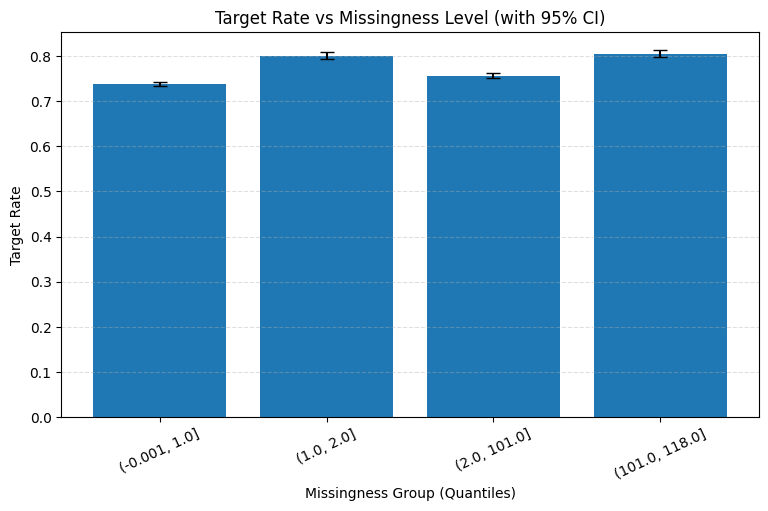

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================
# 1. Missing count per row
# =============================================================
missing_count = X_train.isna().sum(axis=1)

# =============================================================
# 2. Better grouping (quantile-based bins → more stable)
#    This avoids arbitrary thresholds like 10 / 90
# =============================================================
n_bins = 4  # you can change this

missing_group = pd.qcut(
    missing_count,
    q=n_bins,
    duplicates="drop"
)

# =============================================================
# 3. Build analysis dataframe
# =============================================================
df_analysis = pd.DataFrame({
    "missing_group": missing_group,
    "target": y_train.values.ravel()
})

# =============================================================
# 4. Compute statistics
# =============================================================
summary = df_analysis.groupby("missing_group").agg(
    target_rate=("target", "mean"),
    count=("target", "size"),
    std=("target", "std")
)

# Confidence interval (approx)
summary["ci"] = 1.96 * summary["std"] / np.sqrt(summary["count"])

summary = summary.reset_index()

print(summary)

# =============================================================
# 5. Visualization (with error bars)
# =============================================================
plt.figure(figsize=(9, 5))

plt.bar(
    summary["missing_group"].astype(str),
    summary["target_rate"],
    yerr=summary["ci"],
    capsize=5
)

plt.title("Target Rate vs Missingness Level (with 95% CI)")
plt.xlabel("Missingness Group (Quantiles)")
plt.ylabel("Target Rate")
plt.xticks(rotation=25)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

    missing_group  target_rate  count  lift_diff  lift_ratio
0   (-0.001, 1.0]     0.737890  32307  -0.023307    0.969381
1      (1.0, 2.0]     0.800486   9884   0.039289    1.051615
2    (2.0, 101.0]     0.755980  26297  -0.005217    0.993146
3  (101.0, 118.0]     0.804698  11536   0.043502    1.057149


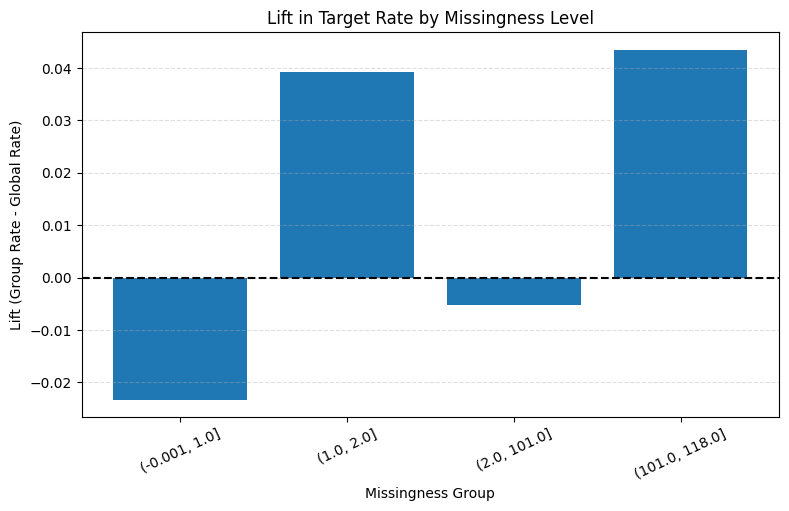

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================
# 1. Missing count per row
# =============================================================
missing_count = X_train.isna().sum(axis=1)

# =============================================================
# 2. Group into quantiles (stable bins)
# =============================================================
n_bins = 4

missing_group = pd.qcut(
    missing_count,
    q=n_bins,
    duplicates="drop"
)

# =============================================================
# 3. Build dataframe
# =============================================================
df = pd.DataFrame({
    "missing_group": missing_group,
    "target": y_train.values.ravel()
})

# =============================================================
# 4. Global baseline
# =============================================================
global_rate = df["target"].mean()

# =============================================================
# 5. Group statistics
# =============================================================
summary = df.groupby("missing_group").agg(
    target_rate=("target", "mean"),
    count=("target", "size")
).reset_index()

# =============================================================
# 6. Lift calculations
# =============================================================
summary["lift_diff"] = summary["target_rate"] - global_rate
summary["lift_ratio"] = summary["target_rate"] / global_rate

# Sort for readability
summary = summary.sort_values("missing_group")

print(summary)

# =============================================================
# 7. Plot: Lift chart (difference from baseline)
# =============================================================
plt.figure(figsize=(9, 5))

plt.bar(
    summary["missing_group"].astype(str),
    summary["lift_diff"]
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Lift in Target Rate by Missingness Level")
plt.xlabel("Missingness Group")
plt.ylabel("Lift (Group Rate - Global Rate)")
plt.xticks(rotation=25)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

**MissingClusterFeatures**

In [13]:
import numpy as np
import pandas as pd

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


class MissingClusterFeatures(BaseEstimator, TransformerMixin):
    """
    Kaggle-style missingness clustering feature engineering.

    Features:
    ----------
    - Fits ONLY on training data (no leakage)
    - Returns ONLY engineered missingness features
    - Safe for train/test pipelines
    - Hierarchical clustering on missing patterns
    - sklearn-compatible
    """

    def __init__(
        self,
        missing_threshold=0.10,
        n_clusters=5,
        distance_metric="jaccard",
        linkage_method="average"
    ):
        self.missing_threshold = missing_threshold
        self.n_clusters = n_clusters
        self.distance_metric = distance_metric
        self.linkage_method = linkage_method

        self.cols_for_clustering_ = None
        self.cluster_map_ = None
        self.feature_names_ = None

    # =========================================================
    # FIT
    # =========================================================
    def fit(self, X, y=None):

        X = X.copy()

        # ---------------------------------
        # Select columns with enough missingness
        # ---------------------------------
        missing_pct = X.isna().mean()

        self.cols_for_clustering_ = (
            missing_pct[missing_pct > self.missing_threshold]
            .index
            .tolist()
        )

        if len(self.cols_for_clustering_) == 0:
            raise ValueError(
                "No columns satisfy missing_threshold."
            )

        # ---------------------------------
        # Missing matrix
        # ---------------------------------
        missing_matrix = (
            X[self.cols_for_clustering_]
            .isna()
            .astype(int)
        )

        # ---------------------------------
        # Pairwise distance
        # ---------------------------------
        dist_matrix = pdist(
            missing_matrix.T,
            metric=self.distance_metric
        )

        # ---------------------------------
        # Hierarchical clustering
        # ---------------------------------
        Z = linkage(
            dist_matrix,
            method=self.linkage_method
        )

        cluster_labels = fcluster(
            Z,
            t=self.n_clusters,
            criterion="maxclust"
        )

        # ---------------------------------
        # Build cluster map
        # ---------------------------------
        cluster_map = {}

        for col, cid in zip(
            self.cols_for_clustering_,
            cluster_labels
        ):
            cluster_map.setdefault(cid, []).append(col)

        self.cluster_map_ = cluster_map

        # ---------------------------------
        # Store feature names
        # ---------------------------------
        feature_names = []

        for cid in cluster_map.keys():

            feature_names.extend([
                f"cluster_{cid}_missing_ratio",
                f"cluster_{cid}_missing_count",
                f"cluster_{cid}_all_missing"
            ])

        self.feature_names_ = feature_names

        return self

    # =========================================================
    # TRANSFORM
    # =========================================================
    def transform(self, X):

        X = X.copy()

        new_features = pd.DataFrame(index=X.index)

        for cid, cols in self.cluster_map_.items():

            cols_existing = [
                c for c in cols if c in X.columns
            ]

            miss = X[cols_existing].isna()

            new_features[
                f"cluster_{cid}_missing_ratio"
            ] = miss.mean(axis=1)

            new_features[
                f"cluster_{cid}_missing_count"
            ] = miss.sum(axis=1)

            new_features[
                f"cluster_{cid}_all_missing"
            ] = miss.all(axis=1).astype(int)

        return new_features

    # =========================================================
    # FIT_TRANSFORM
    # =========================================================
    def fit_transform(self, X, y=None):

        self.fit(X, y)

        return self.transform(X)


# =============================================================
# FEATURE ENGINEERING
# =============================================================

# ---------------------------------
# Fit ONLY on train (NO LEAKAGE)
# ---------------------------------
cluster_fe = MissingClusterFeatures(
    missing_threshold=0.10,
    n_clusters=5
)

# Generate ONLY new features
X_train_cluster = cluster_fe.fit_transform(X_train)
X_test_cluster = cluster_fe.transform(X_test)

# ---------------------------------
# Final datasets
# ---------------------------------
X_train_final = pd.concat(
    [X_train, X_train_cluster],
    axis=1
)

X_test_final = pd.concat(
    [X_test, X_test_cluster],
    axis=1
)


# =============================================================
# EVALUATION
# =============================================================

# ---------------------------------
# Baseline numeric features
# ---------------------------------
base_cols = X_train.select_dtypes(include=np.number).columns

# ---------------------------------
# Baseline model
# ---------------------------------
imputer_base = SimpleImputer(strategy="median")

X_tr_base = imputer_base.fit_transform(
    X_train[base_cols]
)

X_te_base = imputer_base.transform(
    X_test[base_cols]
)

baseline_model = LogisticRegression(
    max_iter=1000
)

baseline_model.fit(
    X_tr_base,
    y_train.values.ravel()
)

pred_base = baseline_model.predict_proba(
    X_te_base
)[:, 1]

auc_base = roc_auc_score(
    y_test,
    pred_base
)


# =============================================================
# MODEL WITH CLUSTER FEATURES
# =============================================================

final_num_cols = X_train_final.select_dtypes(
    include=np.number
).columns

imputer_final = SimpleImputer(
    strategy="median"
)

X_tr_final = imputer_final.fit_transform(
    X_train_final[final_num_cols]
)

X_te_final = imputer_final.transform(
    X_test_final[final_num_cols]
)

cluster_model = LogisticRegression(
    max_iter=1000
)

cluster_model.fit(
    X_tr_final,
    y_train.values.ravel()
)

pred_cluster = cluster_model.predict_proba(
    X_te_final
)[:, 1]

auc_cluster = roc_auc_score(
    y_test,
    pred_cluster
)


# =============================================================
# RESULTS
# =============================================================

print("=" * 50)
print("MISSINGNESS CLUSTER FEATURE EVALUATION")
print("=" * 50)

print(f"\nBaseline AUC:        {auc_base:.6f}")
print(f"Cluster Features AUC:{auc_cluster:.6f}")
print(f"Improvement:         {auc_cluster - auc_base:.6f}")

# =============================================================
# CLUSTER INSPECTION
# =============================================================

print("\n" + "=" * 50)
print("CLUSTER SUMMARY")
print("=" * 50)

for cid, cols in cluster_fe.cluster_map_.items():

    print(f"\nCluster {cid}")
    print(f"Number of features: {len(cols)}")

    preview = cols[:5]

    print("Sample columns:")
    print(preview)

    if len(cols) > 5:
        print("...")

MISSINGNESS CLUSTER FEATURE EVALUATION

Baseline AUC:        0.703756
Cluster Features AUC:0.708851
Improvement:         0.005095

CLUSTER SUMMARY

Cluster 2
Number of features: 75
Sample columns:
['claim_amount_ratio', 'risk_score', 'deductible_ratio', 'claim_reserve_amount', 'policy_value_score']
...

Cluster 1
Number of features: 19
Sample columns:
['premium_payment_score', 'days_since_policy_start', 'medical_necessity_score', 'loss_ratio_history', 'claim_validity_score']
...

Cluster 3
Number of features: 6
Sample columns:
['estimated_settlement_amount', 'policy_compliance_score', 'regional_fraud_index', 'treatment_cost_index', 'optional_coverage_count']
...

Cluster 4
Number of features: 1
Sample columns:
['policy_status']

Cluster 5
Number of features: 1
Sample columns:
['policy_type']


**PERMUTATION IMPORTANCE**

In [27]:
from sklearn.inspection import permutation_importance

# =============================================================
# PERMUTATION IMPORTANCE
# =============================================================

# ---------------------------------
# Feature names used in final model
# ---------------------------------
feature_names = final_num_cols.tolist()

# ---------------------------------
# Compute permutation importance
# ---------------------------------
perm_importance = permutation_importance(
    estimator=cluster_model,
    X=X_te_final,
    y=y_test.values.ravel(),
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

# ---------------------------------
# Build importance dataframe
# ---------------------------------
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

# ---------------------------------
# Sort descending
# ---------------------------------
importance_df = importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

# =============================================================
# TOP FEATURES
# =============================================================

print("=" * 50)
print("TOP PERMUTATION IMPORTANCE FEATURES")
print("=" * 50)

print(
    importance_df.head(20)
)

# =============================================================
# ONLY CLUSTER FEATURES
# =============================================================

cluster_importance = importance_df[
    importance_df["feature"].str.contains("cluster_")
]

print("\n" + "=" * 50)
print("CLUSTER FEATURE IMPORTANCE")
print("=" * 50)

print(
    cluster_importance.head(20)
)

TOP PERMUTATION IMPORTANCE FEATURES
                            feature  importance_mean  importance_std
28            policy_premium_annual         0.168983        0.002167
43           prior_denial_indicator         0.125556        0.002921
34           incurred_loss_estimate         0.082125        0.002012
95                 cross_sell_index         0.042477        0.001274
99   benefit_utilization_percentage         0.031824        0.001362
82        processing_queue_priority         0.029351        0.001528
9                total_claim_amount         0.027931        0.001092
58           coinsurance_percentage         0.027335        0.001228
64         policy_lapse_probability         0.026790        0.001038
33                              v39         0.023673        0.001530
10            policy_renewal_months         0.019695        0.000876
68              urban_density_index         0.016310        0.000963
98   coverage_start_to_claim_months         0.015918        0.00094

**is there a signal in the _pattern of missing values_ with respect to the target?**

In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

X_miss = X_train.isna().astype(int).values
y = y_train.values.ravel()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, val_idx in cv.split(X_miss, y):
    X_tr, X_val = X_miss[train_idx], X_miss[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)

    pred = model.predict_proba(X_val)[:, 1]
    scores.append(roc_auc_score(y_val, pred))

print("AUC mean:", np.mean(scores))
print("AUC std:", np.std(scores))

AUC mean: 0.6007714562387472
AUC std: 0.002018821401242402


#### Treatment Strategy for missing values

In [14]:
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [15]:
# Missing values table
missing_values = missing_values_table(X_train)


missing_values

Your selected dataframe has 131 columns.
There are 119 columns that have missing values.


,Missing Values,% of Total Values
policy_status,42038,52.5
policy_type,38789,48.5
treatment_cost_index,36043,45.0
regional_fraud_index,35605,44.5
optional_coverage_count,35603,44.5
...,...,...
cross_sell_index,23,0.0
coverage_limit,4,0.0
payment_method,3,0.0
automation_eligible,3,0.0


In [16]:

# Extract percentage column
missing_pct = missing_values['% of Total Values'] 

# Categories
high_missing = missing_pct[missing_pct > 40].index
medium_missing = missing_pct[(missing_pct >= 0.3) & (missing_pct <= 40)].index
low_missing = missing_pct[missing_pct <= 0.1].index



print(f'High Missing: {len(high_missing)}')
print(f'Medium Missing: {len(medium_missing)}')
print(f'Low Missing: {len(low_missing)}')


zero_missing = X_train.columns[X_train.isnull().sum() == 0]
print(f'Zero Missing: {len(zero_missing)}')


High Missing: 102
Medium Missing: 6
Low Missing: 11
Zero Missing: 12


In [17]:
tier1_cols = high_missing.tolist()

# =========================================================
# 1. GLOBAL FEATURE (NO FOLDS — must be deterministic)
# =========================================================
row_missing_ratio_train = X_train[tier1_cols].isnull().mean(axis=1)
X_train['has_full_data'] = (row_missing_ratio_train <= 0.30).astype(int)

row_missing_ratio_test = X_test[tier1_cols].isnull().mean(axis=1)
X_test['has_full_data'] = (row_missing_ratio_test <= 0.30).astype(int)

In [18]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer


missing_pct = X_train.isna().mean()

high_missing = missing_pct[missing_pct > 0.4].index
medium_missing = missing_pct[(missing_pct > 0.05) & (missing_pct <= 0.4)].index
low_missing = missing_pct[missing_pct <= 0.05].index

print('High Missing: %d' % len(high_missing))
print('Medium Missing: %d' % len(medium_missing))
print('Low Missing: %d' % len(low_missing))

# ----------------------------
# 1. Split columns by type
# ----------------------------
numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(exclude=np.number).columns

# ----------------------------
# 2. Missing % segmentation (ONLY on train)
# ----------------------------
missing_pct = X_train.isna().mean()

high_missing = missing_pct[missing_pct > 0.4].index
medium_missing = missing_pct[(missing_pct > 0.05) & (missing_pct <= 0.4)].index
low_missing = missing_pct[missing_pct <= 0.05].index

# ----------------------------
# 3. HIGH missing (>40%)
# ----------------------------


# numeric → -999
num_high = [col for col in high_missing if col in numeric_cols]
X_train[num_high] = X_train[num_high].fillna(-999)
X_test[num_high] = X_test[num_high].fillna(-999)

# categorical → "Missing"
cat_high = [col for col in high_missing if col in categorical_cols]
X_train[cat_high] = X_train[cat_high].fillna("Missing")
X_test[cat_high] = X_test[cat_high].fillna("Missing")

# ----------------------------
# 4. MEDIUM missing (5–40%)
# ----------------------------


# numeric → median (fit on train only)
num_medium = [col for col in medium_missing if col in numeric_cols]
if len(num_medium) > 0:
    imputer_num = SimpleImputer(strategy="median")
    X_train[num_medium] = imputer_num.fit_transform(X_train[num_medium])
    X_test[num_medium] = imputer_num.transform(X_test[num_medium])

# categorical → most frequent (fit on train only)
cat_medium = [col for col in medium_missing if col in categorical_cols]
if len(cat_medium) > 0:
    imputer_cat = SimpleImputer(strategy="most_frequent")
    X_train[cat_medium] = imputer_cat.fit_transform(X_train[cat_medium])
    X_test[cat_medium] = imputer_cat.transform(X_test[cat_medium])

# ----------------------------
# 5. LOW missing (<5%)
# ----------------------------
num_low = [col for col in low_missing if col in numeric_cols]
medians = X_train[num_low].median()

X_train[num_low] = X_train[num_low].fillna(medians)
X_test[num_low] = X_test[num_low].fillna(medians)

cat_low = [col for col in low_missing if col in categorical_cols]
X_train[cat_low] = X_train[cat_low].fillna("Missing")
X_test[cat_low] = X_test[cat_low].fillna("Missing")

High Missing: 102
Medium Missing: 1
Low Missing: 29


In [35]:
missing_values = missing_values_table(X_train)
missing_values.head(20)

Your selected dataframe has 132 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [37]:
X_train.to_csv('../data/X_train_prep.csv', index=False)
X_test.to_csv('../data/X_test_prep.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)


In [ ]:

# import pandas as pd
# import numpy as np

# # =========================================================
# # COPY ORIGINAL DATA
# # =========================================================

# X_train_encoded = X_train.copy()
# X_test_encoded = X_test.copy()

# # =========================================================
# # COLUMN GROUPS
# # =========================================================

# onehot_cols = [
#     'claim_type',
#     'risk_category',
#     'policy_status',
#     'geographic_region',
#     'claim_channel',
#     'priority_level',
#     'fraud_indicator_flag',
#     'customer_segment',
#     'provider_network_status'
# ]

# freq_cols = [
#     'document_completeness',
#     'payment_method',
#     'claim_complexity',
#     'adjuster_recommendation',
#     'automation_eligible',
#     'claim_source',
#     'policy_type',
#     'coverage_type',
#     'location_code',
#     'claim_detail_code'
# ]

# # keep only existing cols
# onehot_cols = [c for c in onehot_cols if c in X_train_encoded.columns]
# freq_cols = [c for c in freq_cols if c in X_train_encoded.columns]

# # =========================================================
# # 1. FOLD-SAFE FREQUENCY ENCODING
# # =========================================================

# for col in freq_cols:

#     # OOF encoded column
#     encoded_col = pd.Series(index=X_train_encoded.index, dtype=float)

#     fold_maps = []

#     for train_idx, val_idx in folds:

#         X_tr = X_train_encoded.iloc[train_idx]
#         X_val = X_train_encoded.iloc[val_idx]

#         # frequency map from TRAIN FOLD ONLY
#         freq_map = X_tr[col].value_counts(normalize=True)

#         fold_maps.append(freq_map)

#         # apply to validation fold
#         encoded_col.iloc[val_idx] = X_val[col].map(freq_map)

#     # fill unseen
#     encoded_col = encoded_col.fillna(0)

#     # replace train column
#     X_train_encoded[col] = encoded_col

#     # aggregate fold maps for test
#     combined_freq = pd.concat(fold_maps, axis=1).mean(axis=1)

#     # apply to test
#     X_test_encoded[col] = (
#         X_test_encoded[col]
#         .map(combined_freq)
#         .fillna(0)
#     )

# # =========================================================
# # 2. ONE-HOT ENCODING
# # =========================================================

# X_train_encoded = pd.get_dummies(
#     X_train_encoded,
#     columns=onehot_cols,
#     drop_first=True
# )

# X_test_encoded = pd.get_dummies(
#     X_test_encoded,
#     columns=onehot_cols,
#     drop_first=True
# )

# # =========================================================
# # 3. ALIGN TRAIN / TEST
# # =========================================================

# X_train_encoded, X_test_encoded = X_train_encoded.align(
#     X_test_encoded,
#     join='left',
#     axis=1,
#     fill_value=0
# )

# # =========================================================
# # CHECK
# # =========================================================

# print("Encoded train shape:", X_train_encoded.shape)
# print("Encoded test shape:", X_test_encoded.shape)

In [ ]:


# X_train_encoded.to_csv('../data/X_train_encoded.csv', index=False)
# X_test_encoded.to_csv('../data/X_test_encoded.csv', index=False)
# y_train_original.to_csv('../data/y_train.csv', index=False)




# print("X_train_encoded shape:", X_train_encoded.shape)
# print("X_test_encoded shape:", X_test_encoded.shape)
# print("y_train_original shape:", y_train_original.shape)

# try catboost impute

In [38]:
# import pandas as pd
# import numpy as np
# from catboost import CatBoostRegressor, CatBoostClassifier


# def catboost_cv_impute(
#     X_train,
#     X_test,
#     folds,
#     iterations=300,
#     learning_rate=0.05,
#     depth=6,
#     random_state=42,
#     verbose=0
# ):

#     X_train = X_train.copy()
#     X_test = X_test.copy()

#     # detect categorical columns
#     cat_cols = X_train.select_dtypes(
#         include=["object", "category"]
#     ).columns.tolist()

#     # convert categorical NaN -> "nan"
#     for c in cat_cols:
#         X_train[c] = X_train[c].astype(str)
#         X_test[c] = X_test[c].astype(str)

#     # columns needing imputation
#     cols_with_nan = [
#         c for c in X_train.columns
#         if X_train[c].isnull().sum() > 0 or X_test[c].isnull().sum() > 0
#     ]

#     print("Columns to impute:", cols_with_nan)

#     for target_col in cols_with_nan:

#         print(f"\nImputing {target_col}")

#         train_missing = X_train[target_col].isnull()
#         test_missing = X_test[target_col].isnull()

#         # preserve dtype
#         target_is_cat = target_col in cat_cols

#         if target_is_cat:
#             oof_preds = pd.Series(index=X_train.index, dtype="object")
#         else:
#             oof_preds = pd.Series(index=X_train.index, dtype="float64")

#         test_fold_preds = []

#         # =========================
#         # CV
#         # =========================
#         for fold_id, (tr_idx, val_idx) in enumerate(folds):

#             tr_idx = [i for i in tr_idx if not train_missing.iloc[i]]
#             val_missing_idx = [
#                 i for i in val_idx
#                 if train_missing.iloc[i]
#             ]

#             if len(tr_idx) == 0 or len(val_missing_idx) == 0:
#                 continue

#             X_tr = X_train.iloc[tr_idx].drop(columns=[target_col]).copy()
#             y_tr = X_train.iloc[tr_idx][target_col].copy()

#             X_val = X_train.iloc[val_missing_idx].drop(columns=[target_col]).copy()

#             # ----- fix categorical -----
#             for c in cat_cols:
#                 if c in X_tr.columns:
#                     X_tr[c] = X_tr[c].astype(str)
#                     X_val[c] = X_val[c].astype(str)

#             # ----- fill numeric predictors -----
#             num_cols = [
#                 c for c in X_tr.columns
#                 if c not in cat_cols
#             ]

#             for c in num_cols:
#                 med = X_tr[c].median()
#                 X_tr[c] = X_tr[c].fillna(med)
#                 X_val[c] = X_val[c].fillna(med)

#             cat_features = [
#                 i for i, c in enumerate(X_tr.columns)
#                 if c in cat_cols
#             ]

#             # choose model
#             if target_is_cat:
#                 model = CatBoostClassifier(
#                     iterations=iterations,
#                     learning_rate=learning_rate,
#                     depth=depth,
#                     random_seed=random_state,
#                     verbose=verbose
#                 )
#             else:
#                 model = CatBoostRegressor(
#                     iterations=iterations,
#                     learning_rate=learning_rate,
#                     depth=depth,
#                     random_seed=random_state,
#                     verbose=verbose
#                 )

#             model.fit(
#                 X_tr,
#                 y_tr,
#                 cat_features=cat_features
#             )

#             preds = model.predict(X_val)
#             oof_preds.iloc[val_missing_idx] = preds

#             # predict test too
#             if test_missing.sum() > 0:

#                 X_test_missing = (
#                     X_test.loc[test_missing]
#                     .drop(columns=[target_col])
#                     .copy()
#                 )

#                 for c in cat_cols:
#                     if c in X_test_missing.columns:
#                         X_test_missing[c] = X_test_missing[c].astype(str)

#                 for c in num_cols:
#                     med = X_tr[c].median()
#                     X_test_missing[c] = X_test_missing[c].fillna(med)

#                 test_pred = model.predict(X_test_missing)
#                 test_fold_preds.append(test_pred)

#         # =========================
#         # fill train
#         # =========================
#         X_train.loc[train_missing, target_col] = \
#             oof_preds.loc[train_missing]

#         # fallback if some remain
#         if X_train[target_col].isnull().sum() > 0:
#             if target_is_cat:
#                 fill = X_train[target_col].mode()[0]
#             else:
#                 fill = X_train[target_col].median()

#             X_train[target_col] = X_train[target_col].fillna(fill)

#         # =========================
#         # fill test
#         # =========================
#         if test_missing.sum() > 0 and len(test_fold_preds) > 0:

#             test_fold_preds = np.array(test_fold_preds)

#             if target_is_cat:
#                 final_test = []
#                 for col in test_fold_preds.T:
#                     vals, counts = np.unique(
#                         col,
#                         return_counts=True
#                     )
#                     final_test.append(
#                         vals[np.argmax(counts)]
#                     )
#                 final_test = np.array(final_test)

#             else:
#                 final_test = test_fold_preds.mean(axis=0)

#             X_test.loc[test_missing, target_col] = final_test

#         # final fallback
#         if X_test[target_col].isnull().sum() > 0:
#             if target_is_cat:
#                 fill = X_train[target_col].mode()[0]
#             else:
#                 fill = X_train[target_col].median()

#             X_test[target_col] = X_test[target_col].fillna(fill)

#     return X_train, X_test


# # =====================
# # RUN
# # =====================
# X_train_imp, X_test_imp = catboost_cv_impute(
#     X_train,
#     X_test,
#     folds=folds
# )

In [ ]:

# X_train_imp.to_csv('../data/X_train_fe.csv', index=False)
# X_test_imp.to_csv('../data/X_test_fe.csv', index=False)

The model is dominated by process + missingness signals, not raw numeric features

- Somewhat counterintuitive, most of the features have more NA's when the target is true. This is indicated both by the first red bar on the left being higher than the blue and by the cdf difference line being negative at the start. Perhaps it's the presence of certain information, not the lack of it, that prevents fast-track processing.


🔥 Top Features:
                     feature        ks       auc        mi   abs_auc
0     prior_denial_indicator  0.266619  0.687370  0.042086  0.187370
1      claim_processing_days  0.161738  0.600890  0.022861  0.100890
2       customer_value_score  0.153455  0.577091  0.016357  0.077091
3             coverage_limit  0.137388  0.586266  0.019368  0.086266
4  communication_touchpoints  0.134955  0.436388  0.017110  0.063612
5      previous_claims_value  0.100882  0.551011  0.015347  0.051011
6      policy_premium_annual  0.083864  0.562508  0.010328  0.062508
7      policy_renewal_months  0.080191  0.501304  0.021596  0.001304
8       recovery_probability  0.075867  0.538755  0.014044  0.038755
9           cross_sell_index  0.063458  0.547859  0.011193  0.047859


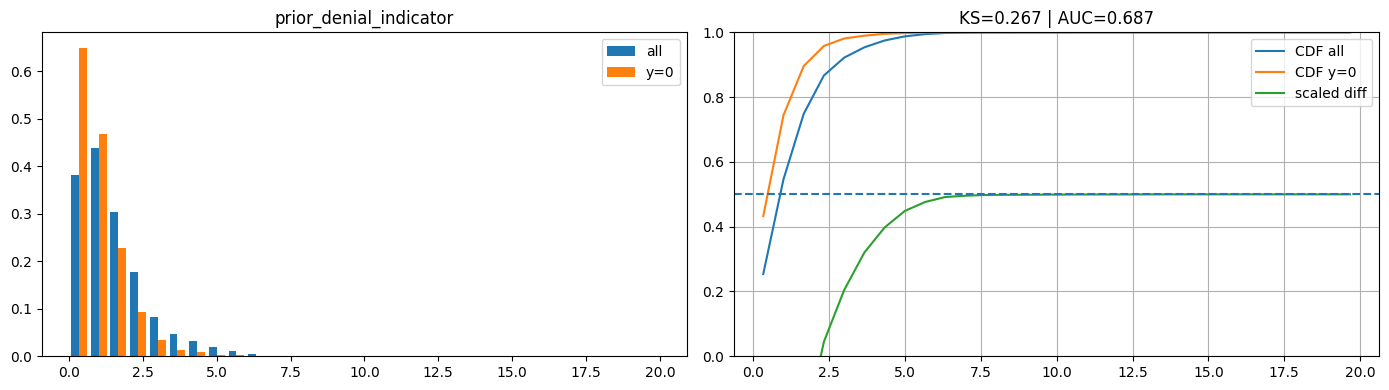

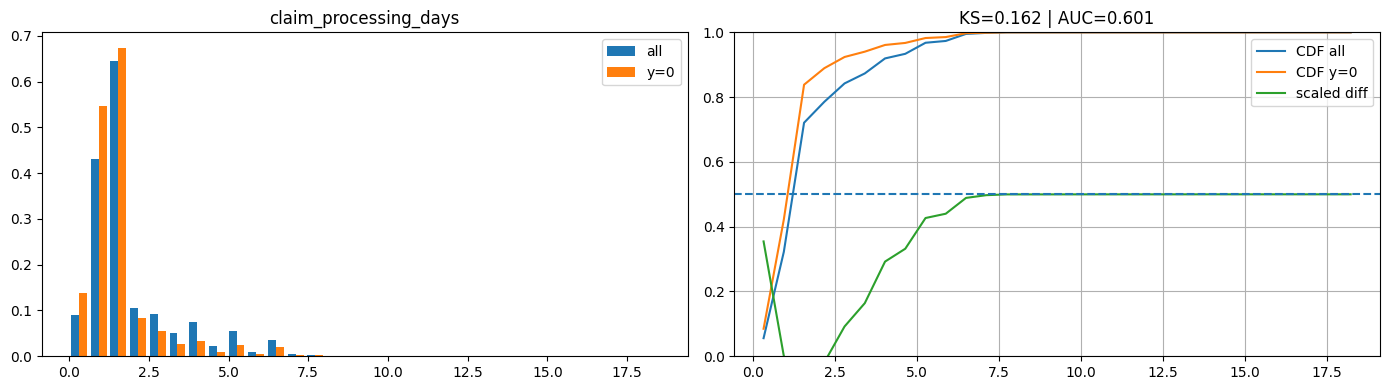

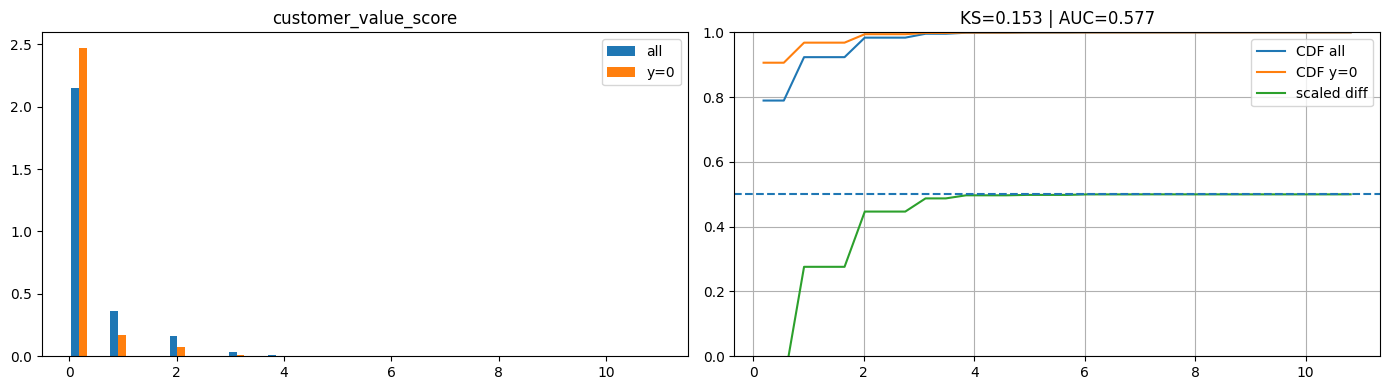

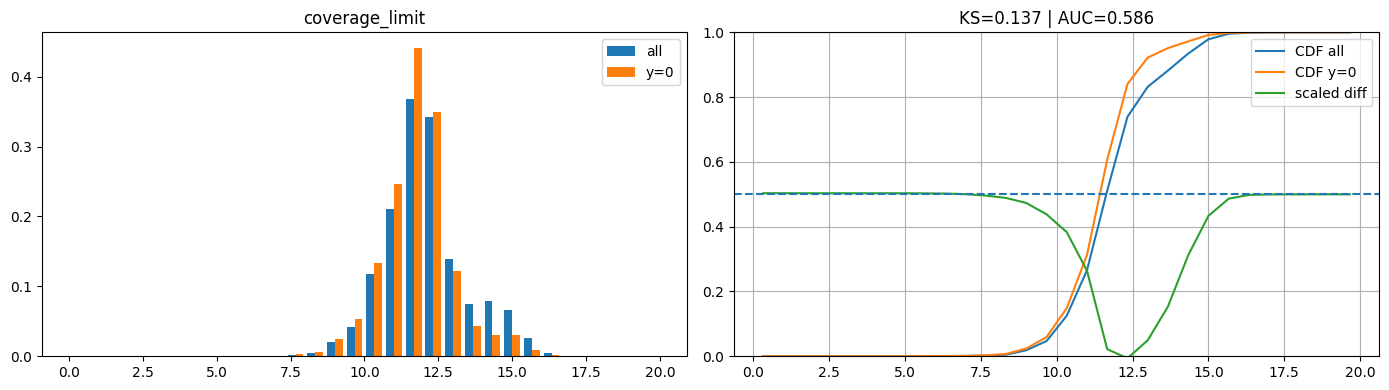

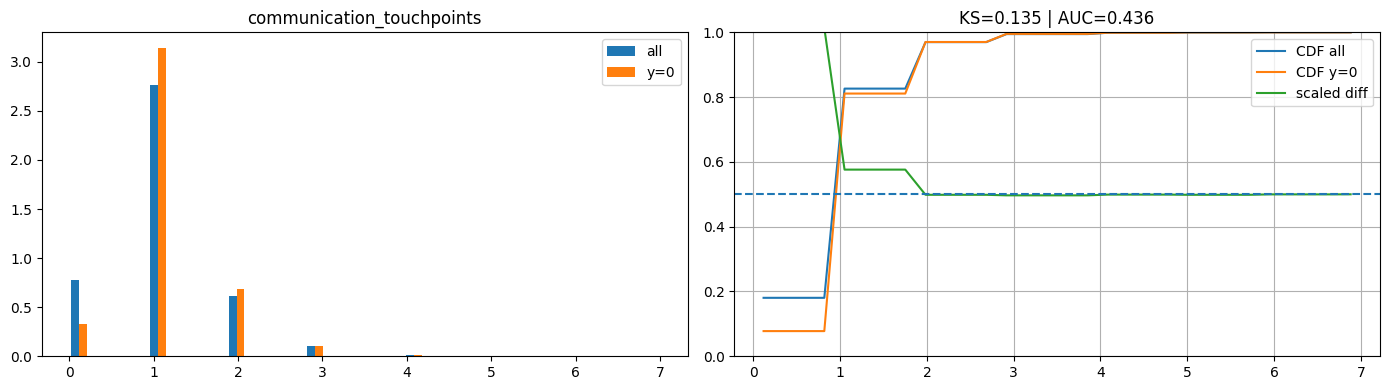

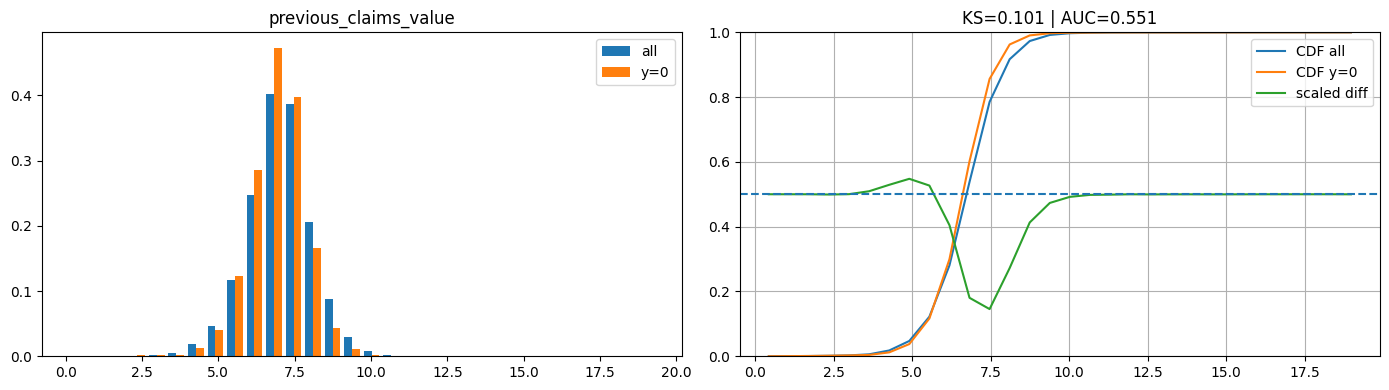

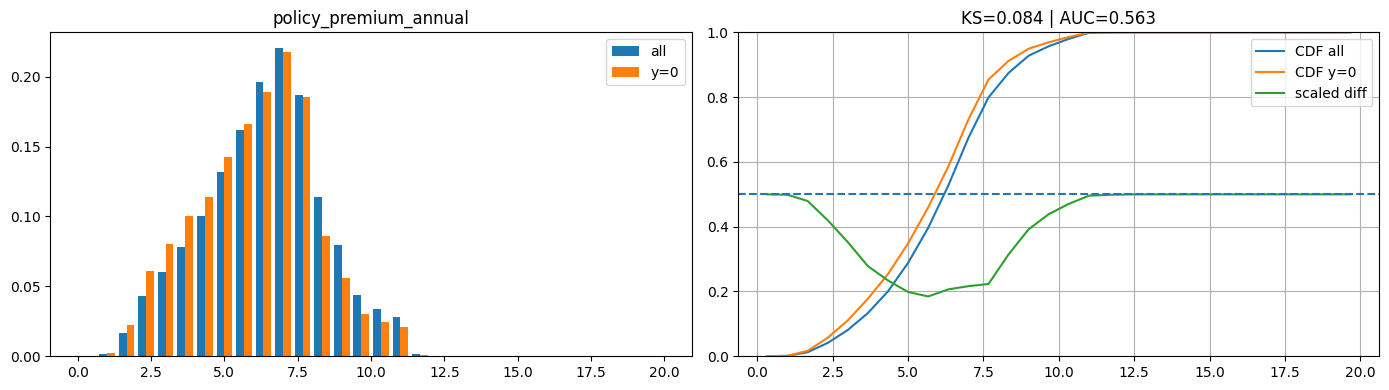

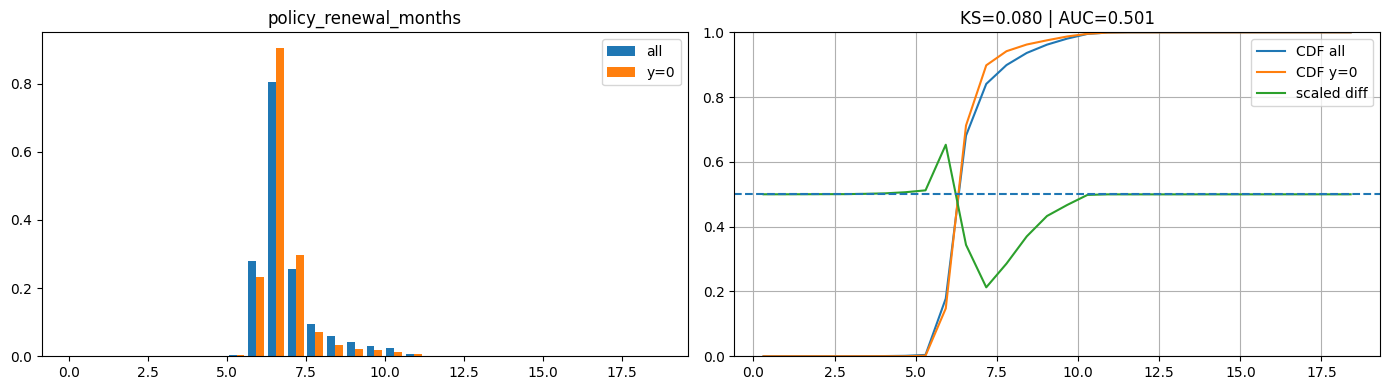

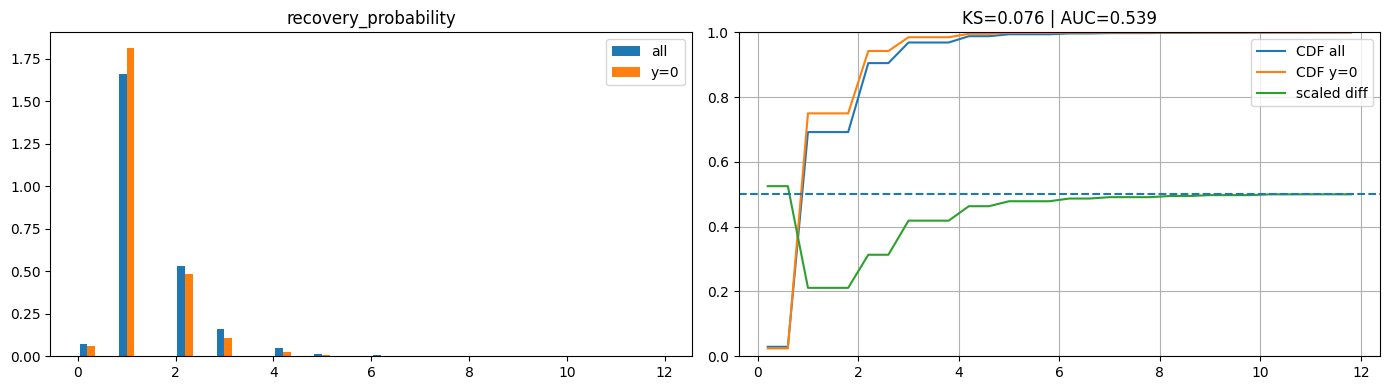

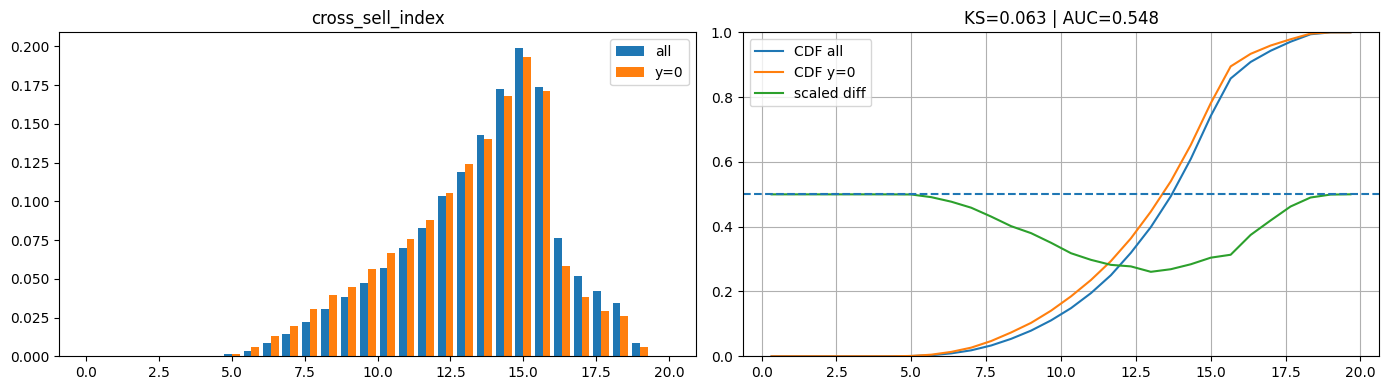

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import ks_2samp


def advanced_feature_analysis(
    X, y,
    nbins=30,
    top_k=10,
    figsize=(14, 4),
    plot=True
):
    """
    Advanced feature analysis:
    - KS statistic
    - AUC per feature
    - Mutual Information
    - Ranking + optional visualization
    """

    y = pd.Series(y).astype(int)
    X = X.copy()

    numeric_cols = X.select_dtypes(include=[np.number]).columns

    results = []

    # --- Compute metrics ---
    for col in numeric_cols:
        x = X[col]

        # Drop NaNs
        mask = ~np.isnan(x)
        x_clean = x[mask]
        y_clean = y[mask]

        if len(np.unique(x_clean)) <= 1:
            continue  # skip constant feature

        # KS Statistic
        ks_stat, _ = ks_2samp(
            x_clean[y_clean == 0],
            x_clean[y_clean == 1]
        )

        # AUC (use feature directly)
        try:
            auc = roc_auc_score(y_clean, x_clean)
        except:
            auc = 0.5

        # Mutual Information
        try:
            mi = mutual_info_classif(
                x_clean.values.reshape(-1, 1),
                y_clean.values,
                discrete_features=False
            )[0]
        except:
            mi = 0

        results.append({
            "feature": col,
            "ks": ks_stat,
            "auc": auc,
            "mi": mi,
            "abs_auc": abs(auc - 0.5)
        })

    results_df = pd.DataFrame(results)

    if results_df.empty:
        print("No valid numeric features.")
        return results_df

    # --- Ranking ---
    results_df = results_df.sort_values(
        by=["ks", "abs_auc", "mi"],
        ascending=False
    ).reset_index(drop=True)

    print("\n🔥 Top Features:")
    print(results_df.head(top_k))

    # --- Plot only top features ---
    if plot:
        top_features = results_df.head(top_k)["feature"]

        for c in top_features:
            x = X[c]
            mask = ~np.isnan(x)

            x_all = x[mask]
            x_pos = x[mask & (y == 0)]

            fig = plt.figure(figsize=figsize)

            # Histogram
            ax1 = fig.add_subplot(1, 2, 1)
            hd = ax1.hist(
                [x_all, x_pos],
                bins=nbins,
                density=True,
                label=["all", "y=0"]
            )
            ax1.set_title(f"{c}")
            ax1.legend()

            # CDF
            bin_edges = hd[1]
            binwidth = bin_edges[1] - bin_edges[0]
            midpts = (bin_edges[:-1] + bin_edges[1:]) / 2

            cdf_all = np.cumsum(hd[0][0]) * binwidth
            cdf_pos = np.cumsum(hd[0][1]) * binwidth

            ax2 = fig.add_subplot(1, 2, 2)
            ax2.plot(midpts, cdf_all, label="CDF all")
            ax2.plot(midpts, cdf_pos, label="CDF y=0")

            diff = cdf_all - cdf_pos
            ax2.plot(midpts, 0.5 + 5 * diff, label="scaled diff")

            ax2.axhline(0.5, linestyle="--")
            ax2.set_ylim(0, 1)
            ax2.set_title(
                f"KS={results_df[results_df.feature==c]['ks'].values[0]:.3f} | "
                f"AUC={results_df[results_df.feature==c]['auc'].values[0]:.3f}"
            )
            ax2.legend()
            ax2.grid()

            plt.tight_layout()
            plt.show()

    return results_df


results = advanced_feature_analysis(df_train, df_target)

In [41]:
selected = results[
    (results["ks"] > 0.15) | 
    (results["abs_auc"] > 0.05)
]
selected

,feature,ks,auc,mi,abs_auc
0,prior_denial_indicator,0.266619,0.687370,0.042086,0.187370
1,claim_processing_days,0.161738,0.600890,0.022861,0.100890
2,customer_value_score,0.153455,0.577091,0.016357,0.077091
3,coverage_limit,0.137388,0.586266,0.019368,0.086266
4,communication_touchpoints,0.134955,0.436388,0.017110,0.063612
5,previous_claims_value,0.100882,0.551011,0.015347,0.051011
6,policy_premium_annual,0.083864,0.562508,0.010328,0.062508


# Feature engineering

In [19]:
X_train["prior_denial_indicator_capped"] = X_train["prior_denial_indicator"].clip(upper=5)
X_test["prior_denial_indicator_capped"] = X_test["prior_denial_indicator"].clip(upper=5)

# binary indicator:

X_train["has_prior_denial"] = (X_train["prior_denial_indicator"] > 0).astype(int)
X_test["has_prior_denial"] = (X_test["prior_denial_indicator"] > 0).astype(int)


X_train["is_nonzero_severity_index"] = (X_train["severity_index"] > 0).astype(int)
X_test["is_nonzero_severity_index"] = (X_test["severity_index"] > 0).astype(int)

X_train["is_nonzero_underwriting_confidence"] = (X_train["underwriting_confidence"] > 0).astype(int)
X_test["is_nonzero_underwriting_confidence"] = (X_test["underwriting_confidence"] > 0).astype(int)

X_train["is_nonzero_customer_value_score"] = (X_train["customer_value_score"] > 0).astype(int)
X_test["is_nonzero_customer_value_score"] = (X_test["customer_value_score"] > 0).astype(int)

X_train["is_nonzero_estimated_settlement_amount"] = (X_train["estimated_settlement_amount"] > 0).astype(int)
X_test["is_nonzero_estimated_settlement_amount"] = (X_test["estimated_settlement_amount"] > 0).astype(int)

X_train["has_customer_value"] = (X_train["customer_value_score"] > 0).astype(int)
X_test["has_customer_value"] = (X_test["customer_value_score"] > 0).astype(int)


X_train["is_zero_touchpoints"] = (X_train["communication_touchpoints"] == 0).astype(int)
X_test["is_zero_touchpoints"] = (X_test["communication_touchpoints"] == 0).astype(int)

# bimodal split (~2.5 vs ~8–10)
X_train["is_high_urban_density"] = (X_train["urban_density_index"] > 5.5).astype(int)
X_test["is_high_urban_density"] = (X_test["urban_density_index"] > 5.5).astype(int)


X_train["is_fast_claim"] = (X_train["claim_processing_days"] < 1).astype(int)
X_test["is_fast_claim"] = (X_test["claim_processing_days"] < 1).astype(int)



X_train["coverage_limit_high"] = (X_train["coverage_limit"] > 12.5).astype(int)
X_test["coverage_limit_high"] = (X_test["coverage_limit"] > 12.5).astype(int)



X_train["previous_claims_low"] = (X_train["previous_claims_value"] < 5).astype(int)
X_test["previous_claims_low"] = (X_test["previous_claims_value"] < 5).astype(int)

X_train["previous_claims_high"] = (X_train["previous_claims_value"] > 9).astype(int)
X_test["previous_claims_high"] = (X_test["previous_claims_value"] > 9).astype(int)


X_train["policy_premium_annual_high"] = (X_train["policy_premium_annual"] > 8).astype(int)
X_test["policy_premium_annual_high"] = (X_test["policy_premium_annual"] > 8).astype(int)

# -----------
X_train["cross_sell_index_high"] = (X_train["cross_sell_index"] > 15).astype(int)
X_test["cross_sell_index_high"] = (X_test["cross_sell_index"] > 15).astype(int)
# distance from threshold
X_train["cross_sell_dist_15"] = X_train["cross_sell_index"] - 15
X_test["cross_sell_dist_15"] = X_test["cross_sell_index"] - 15

# for linear models
X_train["cross_sell_sigmoid"] = 1 / (1 + np.exp(-(X_train["cross_sell_index"] - 15)))
X_test["cross_sell_sigmoid"] = 1 / (1 + np.exp(-(X_test["cross_sell_index"] - 15)))

# -------------
X_train["recovery_prob_is_one"] = (X_train["recovery_probability"] == 1).astype(int)
X_test["recovery_prob_is_one"] = (X_test["recovery_probability"] == 1).astype(int)


X_train["recovery_prob_low"] = (X_train["recovery_probability"] <= 2).astype(int)
X_train["recovery_prob_mid"] = ((X_train["recovery_probability"] >= 3) & (X_train["recovery_probability"] <= 5)).astype(int)
X_train["recovery_prob_high"] = (X_train["recovery_probability"] >= 6).astype(int)

X_test["recovery_prob_low"] = (X_test["recovery_probability"] <= 2).astype(int)
X_test["recovery_prob_mid"] = ((X_test["recovery_probability"] >= 3) & (X_test["recovery_probability"] <= 5)).astype(int)
X_test["recovery_prob_high"] = (X_test["recovery_probability"] >= 6).astype(int)

# -----------
X_train["is_renewal_month_7"] = (X_train["policy_renewal_months"] == 7).astype(int)
X_test["is_renewal_month_7"] = (X_test["policy_renewal_months"] == 7).astype(int)


X_train["is_renewal_cluster"] = (
    (X_train["policy_renewal_months"] >= 6.3) &
    (X_train["policy_renewal_months"] <= 6.6)
).astype(int)

X_test["is_renewal_cluster"] = (
    (X_test["policy_renewal_months"] >= 6.3) &
    (X_test["policy_renewal_months"] <= 6.6)
).astype(int)

X_train["dist_from_7"] = (X_train["policy_renewal_months"] - 7).abs()
X_test["dist_from_7"] = (X_test["policy_renewal_months"] - 7).abs()

X_train["renewal_bucket"] = pd.cut(
    X_train["policy_renewal_months"],
    bins=[-1, 6.3, 6.6, 7.5, 100],
    labels=["low", "cluster", "around_7", "high"]
)

X_test["renewal_bucket"] = pd.cut(
    X_test["policy_renewal_months"],
    bins=[-1, 6.3, 6.6, 7.5, 100],
    labels=["low", "cluster", "around_7", "high"]
)

# -----------------


X_train["previous_claims_bin"] = pd.cut(
    X_train["previous_claims_value"],
    bins=[-1, 5, 7.5, 9, 100],
    labels=["low", "mid_low", "mid_high", "high"]
)

X_test["previous_claims_bin"] = pd.cut(
    X_test["previous_claims_value"],
    bins=[-1, 5, 7.5, 9, 100],
    labels=["low", "mid_low", "mid_high", "high"]
)


# flipp direction for linear models
X_train["communication_touchpoints_flipped"] = -X_train["communication_touchpoints"]
X_test["communication_touchpoints_flipped"] = -X_test["communication_touchpoints"]



# Interaction: top 2 features combined
X_train['denial_x_processing'] = (
    X_train['has_prior_denial'] * X_train['claim_processing_days']
)
X_test['denial_x_processing'] = (
    X_test['has_prior_denial'] * X_test['claim_processing_days']
)



In [20]:
# Hard rules
X_train["rule_priority_A"] = (X_train["priority_level"] == "A").astype(int)
X_test["rule_priority_A"] = (X_test["priority_level"] == "A").astype(int)

X_train["rule_priority_KL"] = X_train["priority_level"].isin(["K", "L"]).astype(int)
X_test["rule_priority_KL"] = X_test["priority_level"].isin(["K", "L"]).astype(int)

X_train["rule_claim_type_A"] = (X_train["claim_type"] == "A").astype(int)
X_test["rule_claim_type_A"] = (X_test["claim_type"] == "A").astype(int)


X_train["rule_region_BC"] = X_train["geographic_region"].isin(["B", "C"]).astype(np.int8)
X_test["rule_region_BC"] = X_test["geographic_region"].isin(["B", "C"]).astype(np.int8)

X_train["rule_doc_H"] = (X_train["document_completeness"] == "H").astype(np.int8)
X_test["rule_doc_H"] = (X_test["document_completeness"] == "H").astype(np.int8)

X_train["rule_doc_E"] = (X_train["document_completeness"] == "E").astype(np.int8)
X_test["rule_doc_E"] = (X_test["document_completeness"] == "E").astype(np.int8)

X_train["rule_fraud_C"] = (X_train["fraud_indicator_flag"] == "C").astype(np.int8)
X_test["rule_fraud_C"] = (X_test["fraud_indicator_flag"] == "C").astype(np.int8)

X_train["rule_provider_B"] = (X_train["provider_network_status"] == "B").astype(np.int8)
X_test["rule_provider_B"] = (X_test["provider_network_status"] == "B").astype(np.int8)


In [21]:
# Interactions
X_train["denial_x_processingv2"] = (
    X_train["prior_denial_indicator"] * X_train["claim_processing_days"]
)

X_test["denial_x_processingv2"] = (
    X_test["prior_denial_indicator"] * X_test["claim_processing_days"]
)

X_train["premium_to_coverage_ratio"] = (
    X_train["policy_premium_annual"] / (X_train["coverage_limit"] + 1)
)

X_test["premium_to_coverage_ratio"] = (
    X_test["policy_premium_annual"] / (X_test["coverage_limit"] + 1)
)

X_train["comm_per_processing_day"] = (
    X_train["communication_touchpoints"] / (X_train["claim_processing_days"] + 1)
)

X_test["comm_per_processing_day"] = (
    X_test["communication_touchpoints"] / (X_test["claim_processing_days"] + 1)
)



X_train["claim_amount_per_premium"] = (
    X_train["claim_amount_ratio"] / (X_train["policy_premium_annual"] + 1)
)

X_test["claim_amount_per_premium"] = (
    X_test["claim_amount_ratio"] / (X_test["policy_premium_annual"] + 1)
)


if all(c in X_train.columns for c in ["policy_premium_annual", "coverage_limit"]):
    X_train["premium_per_coverage"] = (
        X_train["policy_premium_annual"] / (X_train["coverage_limit"] + 1e-6)
    )

    X_test["premium_per_coverage"] = (
        X_test["policy_premium_annual"] / (X_test["coverage_limit"] + 1e-6)
    )




In [95]:
X_train.head()

,claim_amount_ratio,risk_score,claim_type,deductible_ratio,premium_payment_score,claim_reserve_amount,policy_value_score,days_since_policy_start,months_since_last_claim,claim_processing_days,...,denial_x_processingv2,premium_to_coverage_ratio,comm_per_processing_day,claim_amount_per_premium,premium_per_coverage,rule_region_BC,rule_doc_H,rule_doc_E,rule_fraud_C,rule_provider_B
0,4.518807,6.198475,Missing,4.167944,10.345954,2.794333,1.983391,2.009122,11.799164,5.382933,...,17.383666,0.496030,0.000000,0.488809,0.527784,0,0,0,0,0
1,1.007260,3.644213,C,2.496826,8.100906,1.899576,1.748336,5.610209,9.730942,0.218818,...,0.070633,0.345841,0.820467,0.225818,0.384242,0,0,1,0,0
2,2.900623,3.609802,C,1.767901,8.340933,2.729997,1.650911,1.697892,9.393940,1.028447,...,1.198133,0.129173,0.492988,1.084310,0.139966,0,0,0,0,1
3,-999.000000,-999.000000,C,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,2.100657,...,5.874625,0.592878,0.322512,-119.012146,0.644561,0,0,0,0,0
4,-999.000000,-999.000000,C,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,2.341358,...,4.479686,0.425898,0.598559,-137.835405,0.457055,0,0,0,0,1


In [79]:
X_train['renewal_bucket'].value_counts()

renewal_bucket
around_7    28241
cluster     20911
low         18366
high        12506
Name: count, dtype: int64

In [69]:
X_train["previous_claims_bin"]

0            high
1         mid_low
2         mid_low
3         mid_low
4        mid_high
           ...   
80019     mid_low
80020     mid_low
80021     mid_low
80022     mid_low
80023     mid_low
Name: previous_claims_bin, Length: 80024, dtype: category
Categories (4, object): ['low' < 'mid_low' < 'mid_high' < 'high']

In [22]:
# drop 
X_train = X_train.drop(columns=["witnesses_count"])
X_test = X_test.drop(columns=["witnesses_count"])

X_train.drop(columns=["underwriting_confidence"], inplace=True)
X_test.drop(columns=["underwriting_confidence"], inplace=True)

X_train.drop(columns=["customer_segment"], errors="ignore", inplace=True)
X_test.drop(columns=["customer_segment"], errors="ignore", inplace=True)

# # Step 6: Drop confirmed useless features
# drop_cols = ['customer_segment', 'location_code', 'composite_risk_index',
#              'deductible_amount', 'customer_satisfaction_score',
#              'depreciation_rate', 'payment_timeliness_score',
#              'follow_up_responsiveness_score', 'data_completeness_score']
# df.drop(columns=drop_cols, inplace=True)

In [23]:
X_train.head()

,claim_amount_ratio,risk_score,claim_type,deductible_ratio,premium_payment_score,claim_reserve_amount,policy_value_score,days_since_policy_start,months_since_last_claim,claim_processing_days,...,rule_region_BC,rule_doc_H,rule_doc_E,rule_fraud_C,rule_provider_B,denial_x_processingv2,premium_to_coverage_ratio,comm_per_processing_day,claim_amount_per_premium,premium_per_coverage
0,4.518807,6.198475,Missing,4.167944,10.345954,2.794333,1.983391,2.009122,11.799164,5.382933,...,0,0,0,0,0,17.383666,0.496030,0.000000,0.488809,0.527784
1,1.007260,3.644213,C,2.496826,8.100906,1.899576,1.748336,5.610209,9.730942,0.218818,...,0,0,1,0,0,0.070633,0.345841,0.820467,0.225818,0.384242
2,2.900623,3.609802,C,1.767901,8.340933,2.729997,1.650911,1.697892,9.393940,1.028447,...,0,0,0,0,1,1.198133,0.129173,0.492988,1.084310,0.139966
3,-999.000000,-999.000000,C,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,2.100657,...,0,0,0,0,0,5.874625,0.592878,0.322512,-119.012146,0.644561
4,-999.000000,-999.000000,C,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,2.341358,...,0,0,0,0,1,4.479686,0.425898,0.598559,-137.835405,0.457055


In [24]:
X_train.to_csv('../data/X_train_prep.csv', index=False)
X_test.to_csv('../data/X_test_prep.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)


In [2]:
X_train = pd.read_csv('../data/X_train_prep.csv')
X_test = pd.read_csv('../data/X_test_prep.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

In [5]:
original_features = [
    "deductible_ratio"
]

log_features = [
    "claim_validity_score"
]

sqrt_features = [
    "customer_value_score"
]

boxcox_features = [
    "previous_claims_value",
    "medical_necessity_score",
    "policy_modifications_count",
    "external_verifications_count",
    "coverage_utilization_rate",
    "household_size",
    "data_completeness_score",
    "medication_count"
]

used_features = set(
    original_features +
    log_features +
    sqrt_features +
    boxcox_features
)

cat_cols = X_train.select_dtypes(exclude=[np.number]).columns
used_features = used_features.union(set(cat_cols))

yeojohnson_features = list(set(X_train.columns) - used_features)

In [ ]:
X_train[yeojohnson_features]

# encoding

In [26]:
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

**target encoding**

In [28]:
from sklearn.model_selection import StratifiedKFold

def target_encode_cv(X_tr, X_te, col, target, folds, smooth=10):
    """
    Smoothed, leakage-free target encoding using precomputed folds.
    """
    global_mean = target.mean()
    enc_tr = np.zeros(len(X_tr))

    # use your existing folds
    for tr_i, val_i in folds:
        stats = (
            target.iloc[tr_i]
            .groupby(X_tr[col].iloc[tr_i])
            .agg(['mean', 'count'])
        )

        stats['smoothed'] = (
            (stats['count'] * stats['mean'] + smooth * global_mean)
            / (stats['count'] + smooth)
        )

        enc_tr[val_i] = (
            X_tr[col].iloc[val_i]
            .map(stats['smoothed'])
            .fillna(global_mean)
            .values
        )

    # Encode test using all training data
    full = target.groupby(X_tr[col]).agg(['mean', 'count'])

    full['smoothed'] = (
        (full['count'] * full['mean'] + smooth * global_mean)
        / (full['count'] + smooth)
    )

    enc_te = (
        X_te[col]
        .map(full['smoothed'])
        .fillna(global_mean)
        .values
    )

    return enc_tr, enc_te


for col in ['claim_detail_code', 'coverage_type', 'location_code', 'policy_type']:
    if col in X_train_encoded.columns:
        tr_e, te_e = target_encode_cv(
            X_train_encoded,
            X_test_encoded,
            col,
            y_train[TARGET],
            folds=folds
        )

        X_train_encoded[f'{col}_te'] = tr_e
        X_test_encoded[f'{col}_te'] = te_e

        X_train_encoded.drop(columns=[col], inplace=True)
        X_test_encoded.drop(columns=[col], inplace=True)


In [31]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import re

# -------------------------
# 1. Split features first
# -------------------------
categorical_features = X_train_encoded.select_dtypes(include=['object']).columns.tolist()
numeric_features = X_train_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

# -------------------------
# 2. OneHotEncoder
# -------------------------
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train_encoded[categorical_features])
X_test_cat  = encoder.transform(X_test_encoded[categorical_features])

encoded_cols = encoder.get_feature_names_out(categorical_features)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train_encoded.index)
X_test_cat_df  = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test_encoded.index)

# -------------------------
# 3. Keep numeric separately
# -------------------------
X_train_num = X_train_encoded[numeric_features].reset_index(drop=True)
X_test_num  = X_test_encoded[numeric_features].reset_index(drop=True)

# -------------------------
# 4. Combine
# -------------------------
X_train_encoded = pd.concat([X_train_num, X_train_cat_df], axis=1)
X_test_encoded  = pd.concat([X_test_num, X_test_cat_df], axis=1)

# -------------------------
# 5. Clean column names
# -------------------------
def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]

    cols = pd.Series(df.columns)
    for dup in cols[cols.duplicated()].unique():
        cols[cols == dup] = [
            f"{dup}_{i}" if i != 0 else dup
            for i in range(sum(cols == dup))
        ]
    df.columns = cols
    return df

X_train_encoded = clean_column_names(X_train_encoded.copy())
X_test_encoded = clean_column_names(X_test_encoded.copy())

In [33]:
X_train_encoded.to_csv('../data/X_train_encoded.csv', index=False)
X_test_encoded.to_csv('../data/X_test_encoded.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)


In [36]:
X_train_encoded.shape

(80024, 267)

In [35]:
cat_cols = list(X_train_encoded.select_dtypes(include=['object', 'category', 'bool']).columns) # use  this
X_train_encoded[cat_cols].head()

""
0
1
2
3
4


In [ ]:
X_train

**CV adversarial**

In [42]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. Build dataset
X_adv = pd.concat([X_train, X_test], axis=0).copy()
y_adv = np.array([0]*len(X_train) + [1]*len(X_test))

# 2. Encode categoricals safely
for col in cat_cols:
    if col in X_adv.columns:
        X_adv[col] = X_adv[col].astype("category").cat.codes

# 3. CV adversarial evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for train_idx, valid_idx in cv.split(X_adv, y_adv):

    X_tr, X_val = X_adv.iloc[train_idx], X_adv.iloc[valid_idx]
    y_tr, y_val = y_adv[train_idx], y_adv[valid_idx]

    model = LGBMClassifier(n_estimators=300, random_state=42)

    model.fit(X_tr, y_tr)

    preds = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, preds)
    auc_scores.append(auc)

print("Adversarial AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

[LightGBM] [Info] Number of positive: 27437, number of negative: 64019
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032983 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28181
[LightGBM] [Info] Number of data points in the train set: 91456, number of used features: 132
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300002 -> initscore=-0.847287
[LightGBM] [Info] Start training from score -0.847287
[LightGBM] [Info] Number of positive: 27438, number of negative: 64019
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28179
[LightGBM] [Info] Number of data points in the train set: 91457, number of used features: 132
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300010 -> initscore=-0.847251
[LightGBM] [Info] Start training from score -0.847251
[LightGB

In [43]:
for col in cat_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype("category")
        X_test[col] = X_test[col].astype("category")


from lightgbm import LGBMClassifier

model = LGBMClassifier(n_estimators=200)

model.fit(
    X_train[cat_cols + num_cols],
    y_train,
    categorical_feature=cat_cols
)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train[cat_cols + num_cols])[:,1])
val_auc   = roc_auc_score(y_test, model.predict_proba(X_test[cat_cols + num_cols])[:,1])

print(train_auc, val_auc)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 60914, number of negative: 19110
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33853
[LightGBM] [Info] Number of data points in the train set: 80024, number of used features: 131
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.761197 -> initscore=1.159251
[LightGBM] [Info] Start training from score 1.159251
0.8961221855925865 0.7405428855691237


🧠 What this means

👉 You have moderate overfitting

- Gap ≈ 0.15
- Not catastrophic, but not clean either

Interpretation:

- Model is learning real signal ✅
- But also memorizing noise / high-cardinality patterns ⚠️

In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    model,
    X_test[feature_vars],
    y_test,
    n_repeats=5,
    random_state=42
)

importance = pd.Series(r.importances_mean, index=feature_vars)
importance.sort_values(ascending=False).head(20)

prior_denial_indicator            0.031904
claim_channel                     0.015220
claim_detail_code                 0.001195
coverage_type                     0.001079
policy_status                     0.000968
previous_claims_value             0.000612
risk_category                     0.000367
policy_riders_count               0.000262
claim_processing_days             0.000239
days_in_current_status            0.000222
deductible_ratio                  0.000222
coverage_start_to_claim_months    0.000198
months_since_last_claim           0.000198
regional_claim_frequency_index    0.000163
regional_fraud_index              0.000157
policy_premium_annual             0.000140
claim_submission_completeness     0.000134
diagnosis_complexity_score        0.000111
customer_tenure_years             0.000105
data_source_reliability           0.000093
dtype: float64

❗ Important: check latter

In [ ]:
X_adv = pd.concat([X_train, X_test]).copy()
y_adv = np.array([0]*len(X_train) + [1]*len(X_test))

# enforce categorical dtype again
for col in cat_cols:
    if col in X_adv.columns:
        X_adv[col] = X_adv[col].astype("category")

adv_model = LGBMClassifier(n_estimators=200)

adv_model.fit(
    X_adv,
    y_adv,
    categorical_feature=cat_cols
)

adv_pred = adv_model.predict_proba(X_adv)[:, 1]

print("Adversarial AUC:", roc_auc_score(y_adv, adv_pred))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 34297, number of negative: 80024
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025762 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35636
[LightGBM] [Info] Number of data points in the train set: 114321, number of used features: 132
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300006 -> initscore=-0.847269
[LightGBM] [Info] Start training from score -0.847269
Adversarial AUC: 0.7795346379466631


In [ ]:
imp = pd.Series(
    adv_model.feature_importances_,
    index=X_adv.columns
).sort_values(ascending=False)

print(imp.head(20))

claim_detail_code              1461
location_code                   332
coverage_type                   302
prior_denial_indicator          194
previous_claims_value           192
claim_processing_days           183
policy_renewal_months           175
coverage_limit                  160
policy_premium_annual           146
cross_sell_index                138
payment_method                  120
incurred_loss_estimate          118
estimated_settlement_amount      84
policy_type                      83
renewal_count                    48
final_decision_confidence        40
underwriting_confidence          39
network_discount_rate            39
policy_riders_count              38
credit_score_normalized          37
dtype: int32


In [ ]:
X_train

,id,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,...,nom_8,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month
0,0,0,0,0,T,Y,Green,Triangle,Snake,Finland,...,c389000ab,2f4cb3d51,2,Grandmaster,Cold,h,D,kr,2,2
1,1,0,1,0,T,Y,Green,Trapezoid,Hamster,Russia,...,4cd920251,f83c56c21,1,Grandmaster,Hot,a,A,bF,7,8
2,2,0,0,0,F,Y,Blue,Trapezoid,Lion,Russia,...,de9c9f684,ae6800dd0,1,Expert,Lava Hot,h,R,Jc,7,2
3,3,0,1,0,F,Y,Red,Trapezoid,Snake,Canada,...,4ade6ab69,8270f0d71,1,Grandmaster,Boiling Hot,i,D,kW,2,1
4,4,0,0,0,F,N,Red,Trapezoid,Lion,Canada,...,cb43ab175,b164b72a7,1,Grandmaster,Freezing,a,R,qP,7,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,299995,0,0,0,T,N,Red,Trapezoid,Snake,India,...,7508f4ef1,e027decef,1,Contributor,Freezing,k,K,dh,3,8
299996,299996,0,0,0,F,Y,Green,Trapezoid,Lion,Russia,...,397dd0274,80f1411c8,2,Novice,Freezing,h,W,MO,3,2
299997,299997,0,0,0,F,Y,Blue,Star,Axolotl,Russia,...,5d7806f53,314dcc15b,3,Novice,Boiling Hot,o,A,Bn,7,9
299998,299998,0,1,0,F,Y,Green,Square,Axolotl,Costa Rica,...,1f820c7ce,ab0ce192b,1,Master,Boiling Hot,h,W,uJ,3,8


**Near-Zero Variance Features**

In [ ]:
def remove_low_variance(df, threshold=0.1):
    low_var_cols = []
    
    for col in df.columns:
        if df[col].nunique() / len(df) < threshold:
            low_var_cols.append(col)
    
    return df.drop(columns=low_var_cols), low_var_cols

df, removed_cols = remove_low_variance(df_train)
print("Removed low variance:", removed_cols)

Removed low variance: ['claim_type', 'risk_category', 'policy_status', 'geographic_region', 'severity_index', 'document_completeness', 'payment_method', 'coverage_type', 'communication_touchpoints', 'claim_channel', 'priority_level', 'recovery_probability', 'fraud_indicator_flag', 'customer_segment', 'claim_complexity', 'adjuster_recommendation', 'automation_eligible', 'provider_network_status', 'claim_source', 'policy_type', 'location_code', 'customer_value_score']


In [ ]:
len(removed_cols)

22

**Detect Duplicate Categorical Variables**

In [ ]:
def find_duplicate_categorical(df, cat_cols):
    duplicates = []
    
    for i in range(len(cat_cols)):
        for j in range(i+1, len(cat_cols)):
            c1, c2 = cat_cols[i], cat_cols[j]
            
            if df[c1].equals(df[c2]):
                duplicates.append((c1, c2))
    
    return duplicates

dup_cats = find_duplicate_categorical(df_train, cat_cols)
print("Duplicate categorical variables:", dup_cats)

Duplicate categorical variables: []


**Correlation for Continuous Variables** (after deleting near zero)

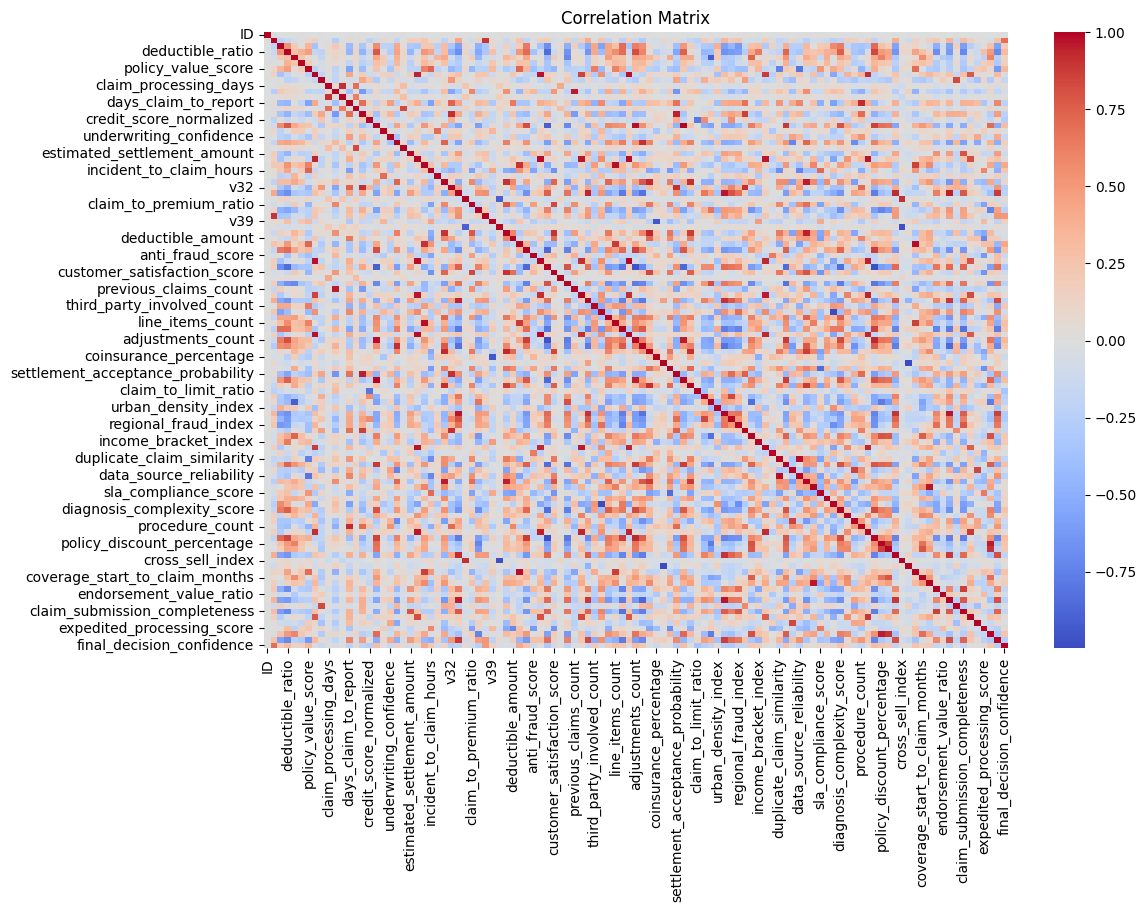

In [ ]:
df_num_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[df_num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Highly Correlated Pairs

In [ ]:
def get_high_corr_pairs(corr_matrix, threshold=0.9):
    pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            
            corr = corr_matrix.iloc[i, j]
            
            if abs(corr) > threshold:
                pairs.append((col1, col2, corr))
    
    return pairs

high_corr = get_high_corr_pairs(corr_matrix, 0.9)
print("Highly correlated pairs:")
for p in high_corr:
    print(p)

Highly correlated pairs:
('premium_payment_score', 'zip_code_risk_score', -0.9055175089881555)
('days_since_policy_start', 'medical_necessity_score', 0.9426269445404747)
('days_since_policy_start', 'claim_validity_score', 0.9751917446209348)
('days_since_policy_start', 'external_verifications_count', 0.9759739958089727)
('days_since_policy_start', 'medication_count', 0.9171668122632674)
('claim_processing_days', 'policy_renewal_months', 0.9118188685795392)
('total_claim_amount', 'previous_claims_count', 0.9557573593403604)
('days_claim_to_report', 'procedure_count', 0.9243973743297397)
('fraud_probability_score', 'v32', 0.9083695327779185)
('fraud_probability_score', 'settlement_acceptance_probability', 0.9459704767591128)
('claim_complexity_score', 'reinsurance_amount', -0.9104502281790102)
('claim_complexity_score', 'adjustments_count', 0.9826261383774675)
('claim_complexity_score', 'liability_percentage', 0.9926712551209556)
('customer_loyalty_score', 'extensions_requested', 0.91106

**Detect Functional Relationships (R²)**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency

def compute_r2_pairs(df, num_cols, threshold=0.9):
    results = []
    
    for i in range(len(num_cols)):
        for j in range(i+1, len(num_cols)):
            x = df[num_cols[i]].values.reshape(-1, 1)
            y = df[num_cols[j]].values
            
            model = LinearRegression().fit(x, y)
            y_pred = model.predict(x)
            
            r2 = r2_score(y, y_pred)
            
            if r2 > threshold:
                results.append((num_cols[i], num_cols[j], r2))
    
    return results

r2_pairs = compute_r2_pairs(df, df_num_cols)

print("Strong functional relationships:")
for r in r2_pairs:
    print(r)

ValueError: Input y contains NaN, infinity or a value too large for dtype('float64').

**Categorical Association (Chi-Square)**

In [ ]:
def chi_square_test(df, col1, col2):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, _, _ = chi2_contingency(contingency)
    return p

strong_cat_pairs = []

for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        p = chi_square_test(df_train, cat_cols[i], cat_cols[j])
        
        if p < 1e-5:
            strong_cat_pairs.append((cat_cols[i], cat_cols[j], p))

print("Strong categorical associations:")
for s in strong_cat_pairs:
    print(s)

Strong categorical associations:
('claim_type', 'risk_category', 3.6358719872798217e-14)
('claim_type', 'geographic_region', 3.943030757570263e-257)
('claim_type', 'document_completeness', 1.4848913513766778e-53)
('claim_type', 'coverage_type', 0.0)
('claim_type', 'claim_channel', 5.042539477166563e-14)
('claim_type', 'priority_level', 4.952816059922858e-124)
('claim_type', 'fraud_indicator_flag', 4.1103179586402433e-10)
('claim_type', 'customer_segment', 8.302265797947757e-81)
('claim_type', 'claim_complexity', 2.2390815960921297e-187)
('claim_type', 'provider_network_status', 3.0143649298838544e-62)
('claim_type', 'policy_type', 6.113013858573257e-12)
('claim_type', 'location_code', 1.3678310694766457e-07)
('claim_detail_code', 'risk_category', 0.0)
('claim_detail_code', 'policy_status', 0.0)
('claim_detail_code', 'geographic_region', 0.0)
('claim_detail_code', 'document_completeness', 0.0)
('claim_detail_code', 'payment_method', 0.0)
('claim_detail_code', 'coverage_type', 0.0)
('cla

**Correspondence Analysis (Categorical PCA)**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
low_card_cols = [col for col in cat_cols if df_train[col].nunique() < 50]



encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df_train[low_card_cols])

pca = PCA(n_components=5)
cat_pca = pca.fit_transform(encoded)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.1565146  0.08759715 0.04920267 0.04842484 0.0451633 ]


**PCA for Correlated Groups**

In [ ]:
# Example: take correlated variables
group = ["days_since_policy_start", "model_version_indicator"]  # replace with your detected group

pca = PCA()
X = df_train[group].dropna()

X_pca = pca.fit_transform(X)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.86341612 0.13658388]


👉 If first component > 95%:
```python
df["combined_feature"] = X_pca[:, 0]
df = df.drop(columns=group)
```

**Label encoding**
<mark>batter to specify the cols</mark>

In [ ]:
# from sklearn.preprocessing import LabelEncoder


# train=pd.DataFrame()
# label=LabelEncoder()
# for c in  X_train.columns:
#     if(X_train[c].dtype=='object'):
#         train[c]=label.fit_transform(X_train[c])
#     else:
#         train[c]=X_train[c]
        
# train.head(3)    



In [ ]:
bin_cols = ['bin_0', 'bin_1', 'bin_2', 'bin_3', 'bin_4']


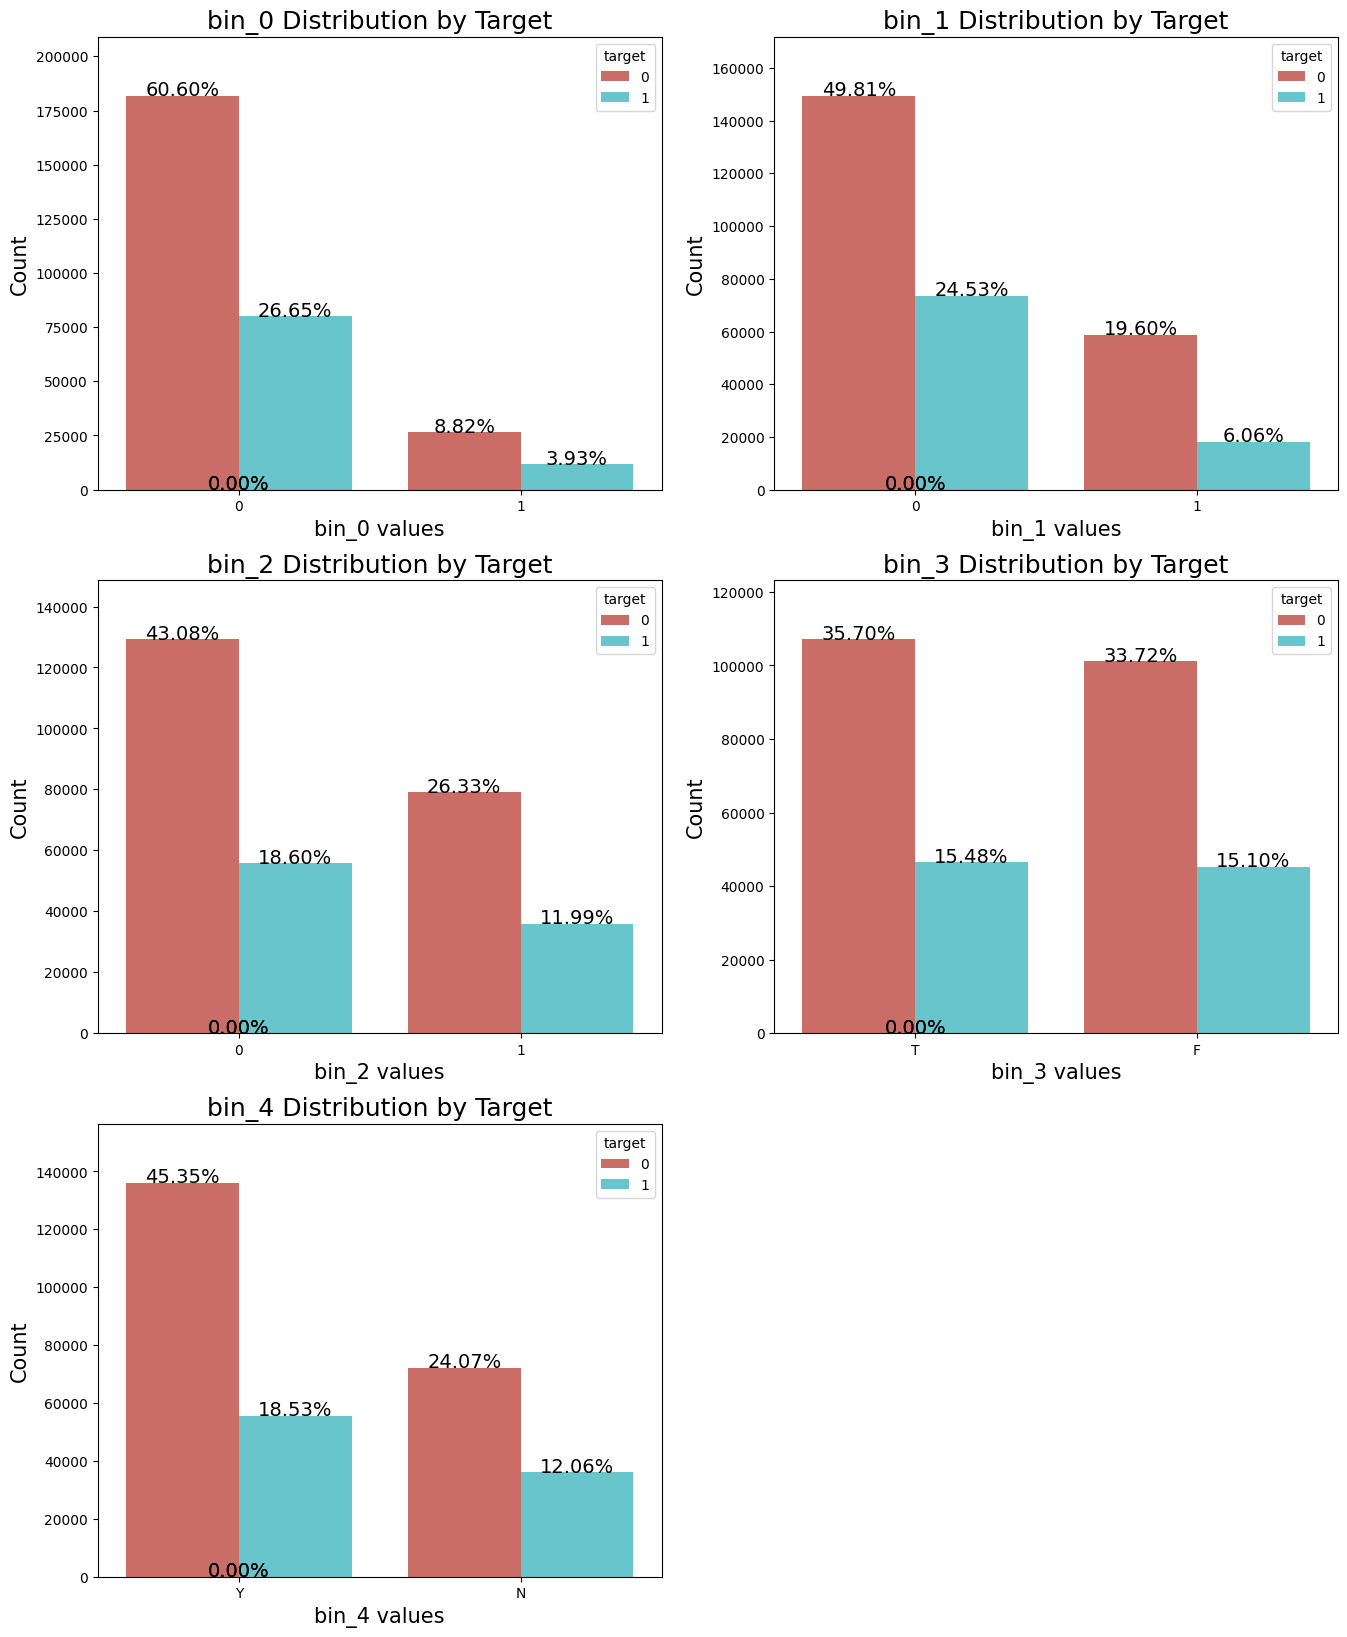

In [ ]:
import matplotlib.gridspec as gridspec # 


# define binary columns
# bin_cols = ['']


grid = gridspec.GridSpec(3, 2) 
plt.figure(figsize=(16,20)) 

for n, col in enumerate(df_train[bin_cols]): 
    ax = plt.subplot(grid[n])
    sns.countplot(x=col, data=df_train, hue='target', palette='hls') 
    
    ax.set_ylabel('Count', fontsize=15)
    ax.set_title(f'{col} Distribution by Target', fontsize=18)
    ax.set_xlabel(f'{col} values', fontsize=15)

    total = len(df_train)   # ✅ define total here

    sizes = []
    for p in ax.patches:
        height = p.get_height()
        sizes.append(height)

        ax.text(
            p.get_x() + p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height / total * 100),
            ha="center",
            fontsize=14
        )

    ax.set_ylim(0, max(sizes) * 1.15)

plt.show()

In [ ]:
# dictionary to map the feature
bin_dict = {'T':1, 'F':0, 'Y':1, 'N':0}

# Maping the category values in our dict
X_train['bin_3'] = X_train['bin_3'].map(bin_dict)
X_train['bin_4'] = X_train['bin_4'].map(bin_dict)
X_test['bin_3'] = X_test['bin_3'].map(bin_dict)
X_test['bin_4'] = X_test['bin_4'].map(bin_dict)


Nominal Features (with more than 2 and less than 15 values)

In [ ]:
nom_cols = ['nom_0', 'nom_1', 'nom_2', 'nom_3', 'nom_4']



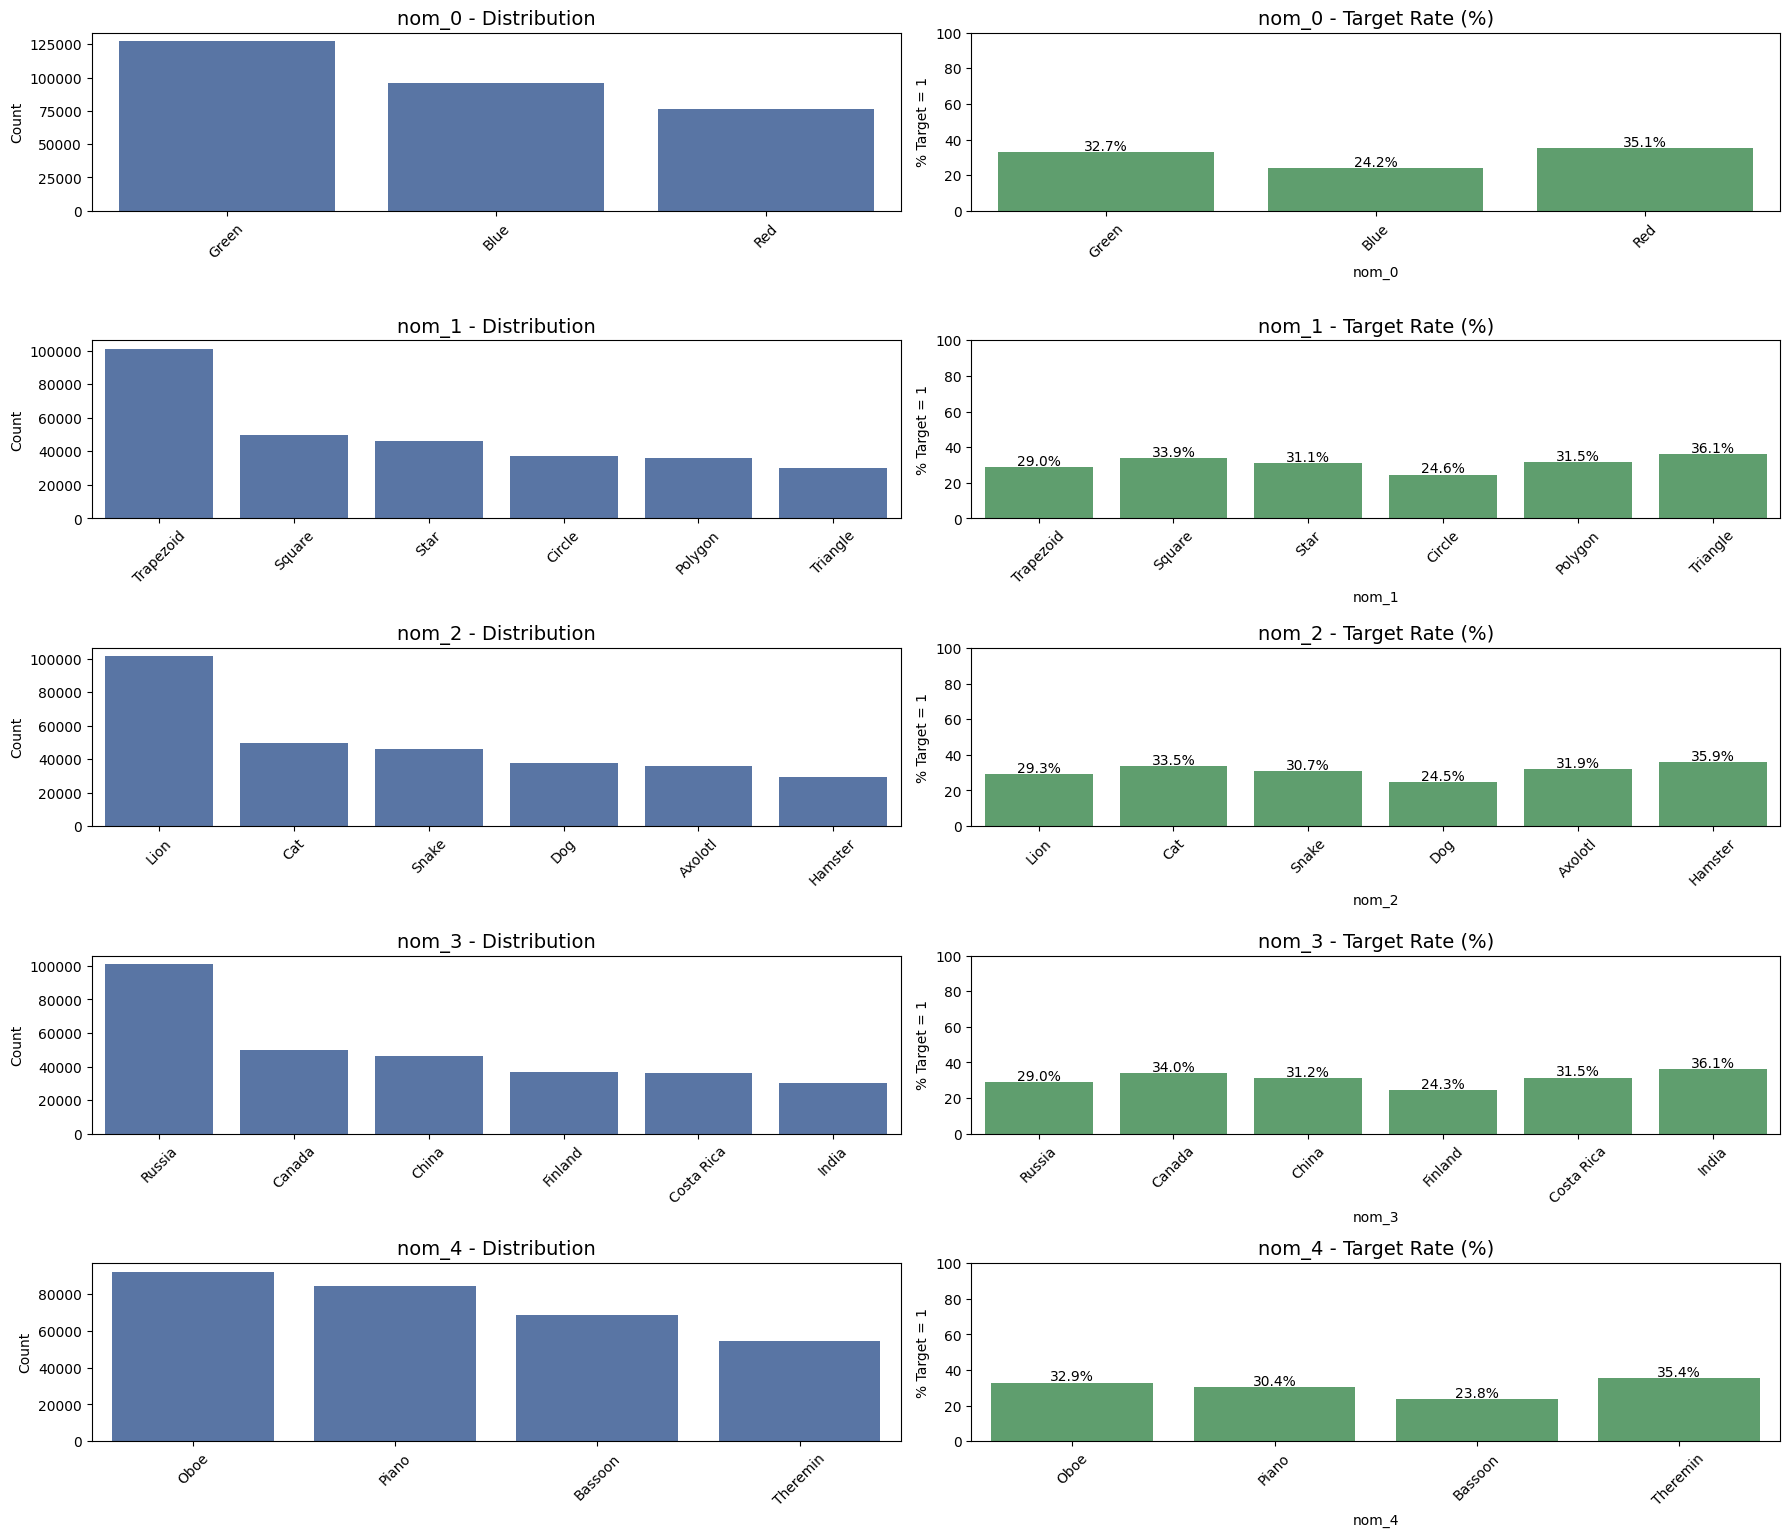

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec

def ploting_cat_fet(df, cols, vis_row=5, vis_col=2):

    grid = gridspec.GridSpec(vis_row * 2, vis_col)
    plt.figure(figsize=(18, 6 * vis_row))

    for n, col in enumerate(cols):

        # -------------------------
        # ORDER (consistent)
        # -------------------------
        order = df[col].value_counts().index

        # -------------------------
        # 1. COUNT PLOT (TOP)
        # -------------------------
        ax1 = plt.subplot(grid[n * 2])

        sns.countplot(x=col, data=df, order=order, ax=ax1, color="#4C72B0")

        ax1.set_title(f"{col} - Distribution", fontsize=14)
        ax1.set_ylabel("Count")
        ax1.set_xlabel("")
        ax1.tick_params(axis='x', rotation=45)

        # -------------------------
        # 2. TARGET RATE (BOTTOM)
        # -------------------------
        ax2 = plt.subplot(grid[n * 2 + 1])

        rate = df.groupby(col)['target'].mean().reindex(order) * 100

        sns.barplot(x=rate.index, y=rate.values, ax=ax2, color="#55A868")

        ax2.set_title(f"{col} - Target Rate (%)", fontsize=14)
        ax2.set_ylabel("% Target = 1")
        ax2.set_xlabel(col)
        ax2.set_ylim(0, 100)
        ax2.tick_params(axis='x', rotation=45)

        # annotations (clean)
        for i, v in enumerate(rate.values):
            ax2.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

ploting_cat_fet(df_train, nom_cols, vis_row=5, vis_col=2)

apply onehot encoding on them

In [ ]:
df = pd.concat([X_train, X_test], axis=0, sort=False )

print(f'Shape before dummy transformation: {df.shape}')
df = pd.get_dummies(df, columns=['nom_0', 'nom_1', 'nom_2', 'nom_3', 'nom_4'],\
                          prefix=['nom_0', 'nom_1', 'nom_2', 'nom_3', 'nom_4'], drop_first=True)
print(f'Shape after dummy transformation: {df.shape}')

Shape before dummy transformation: (500000, 23)
Shape after dummy transformation: (500000, 38)


In [ ]:

X_train = df.iloc[:len(y_train)]
X_test = df.iloc[len(y_train):]

del df

In [ ]:
X_train.head(5)

,bin_0,bin_1,bin_2,bin_3,bin_4,nom_5,nom_6,nom_7,nom_8,nom_9,...,nom_2_Lion,nom_2_Snake,nom_3_China,nom_3_Costa Rica,nom_3_Finland,nom_3_India,nom_3_Russia,nom_4_Oboe,nom_4_Piano,nom_4_Theremin
0,0,0,0,1,1,50f116bcf,3ac1b8814,68f6ad3e9,c389000ab,2f4cb3d51,...,False,True,False,False,True,False,False,False,False,False
1,0,1,0,1,1,b3b4d25d0,fbcb50fc1,3b6dd5612,4cd920251,f83c56c21,...,False,False,False,False,False,False,True,False,True,False
2,0,0,0,0,1,3263bdce5,0922e3cb8,a6a36f527,de9c9f684,ae6800dd0,...,True,False,False,False,False,False,True,False,False,True
3,0,1,0,0,1,f12246592,50d7ad46a,ec69236eb,4ade6ab69,8270f0d71,...,False,True,False,False,False,False,False,True,False,False
4,0,0,0,0,0,5b0f5acd5,1fe17a1fd,04ddac2be,cb43ab175,b164b72a7,...,True,False,False,False,False,False,False,True,False,False


Ordinal Features (with more than 2 and less than 15 values)

In [ ]:
ord_cols = ['ord_0', 'ord_1', 'ord_2', 'ord_3']

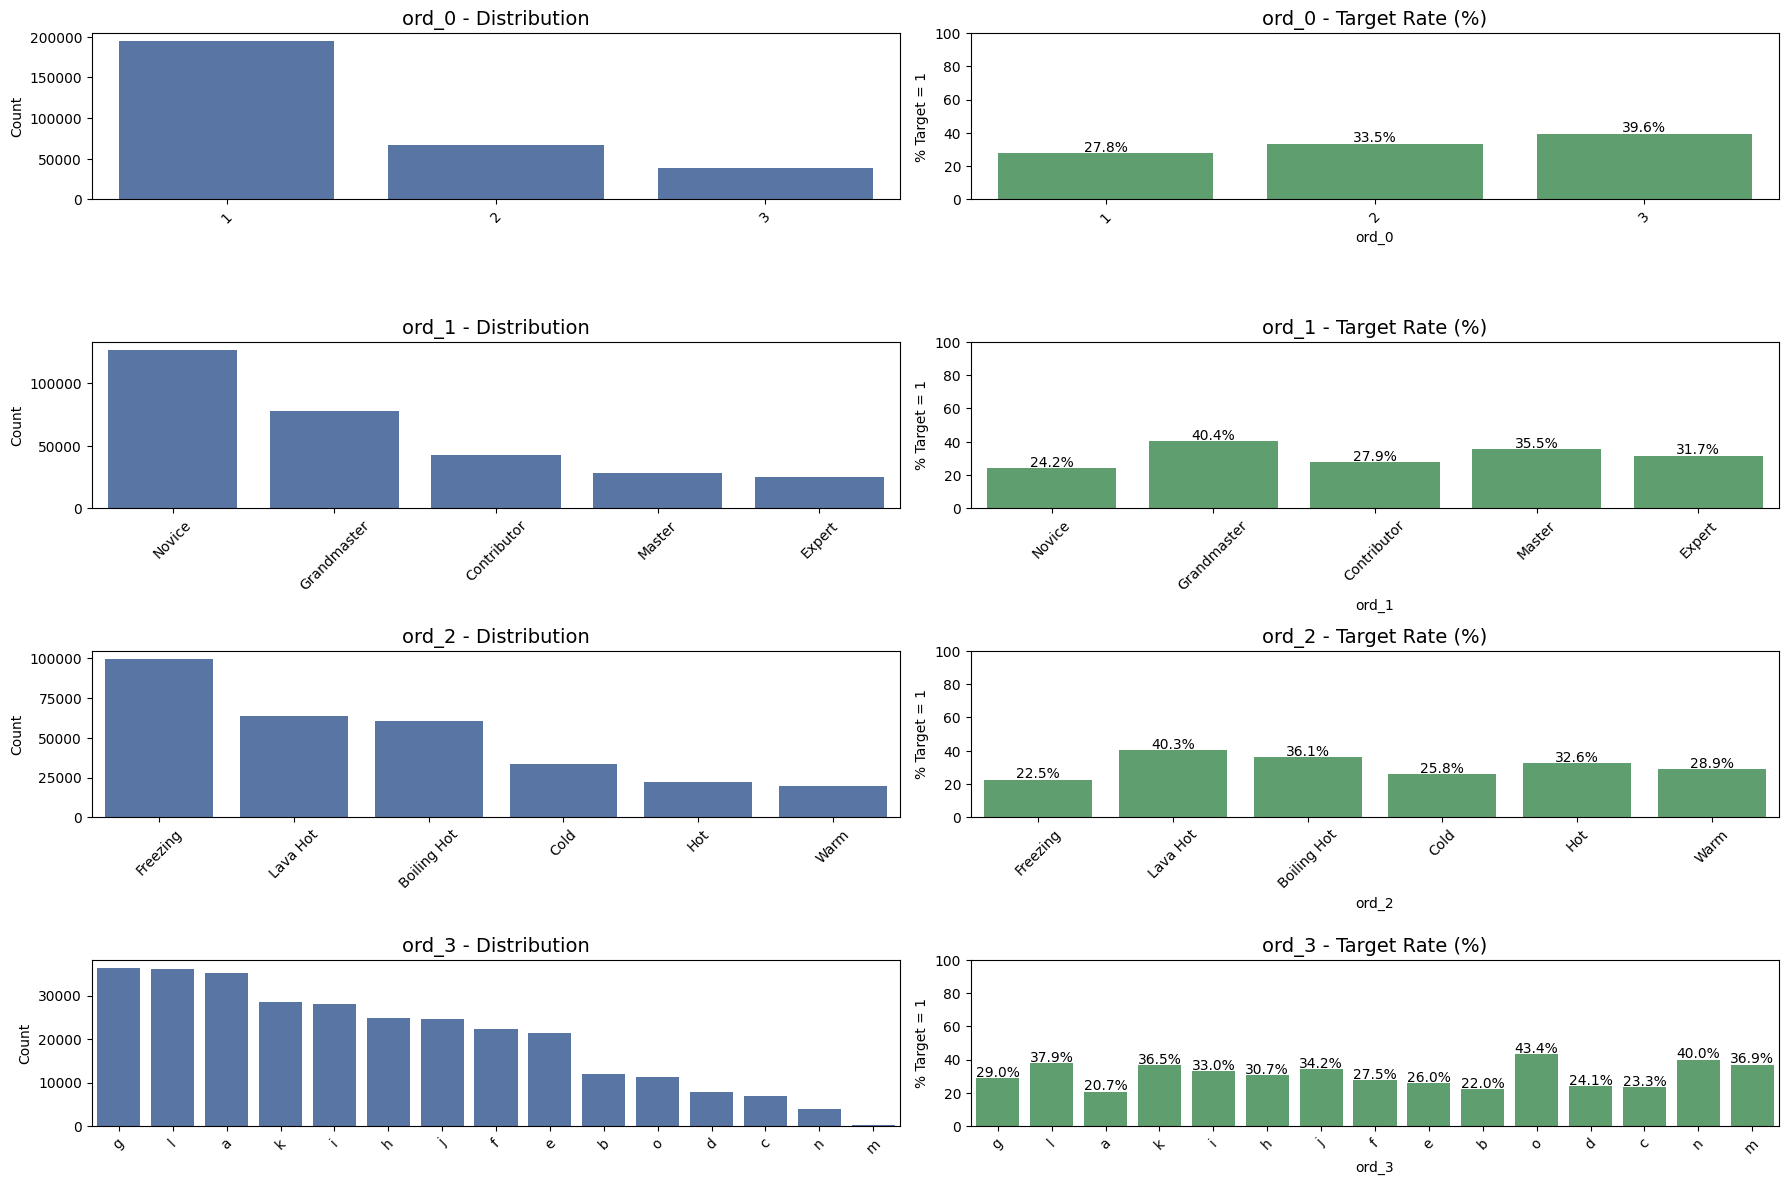

In [ ]:
ploting_cat_fet(df_train, ord_cols, vis_row=5, vis_col=2)

In [ ]:
ord_5_count = X_train['ord_5'].value_counts().values

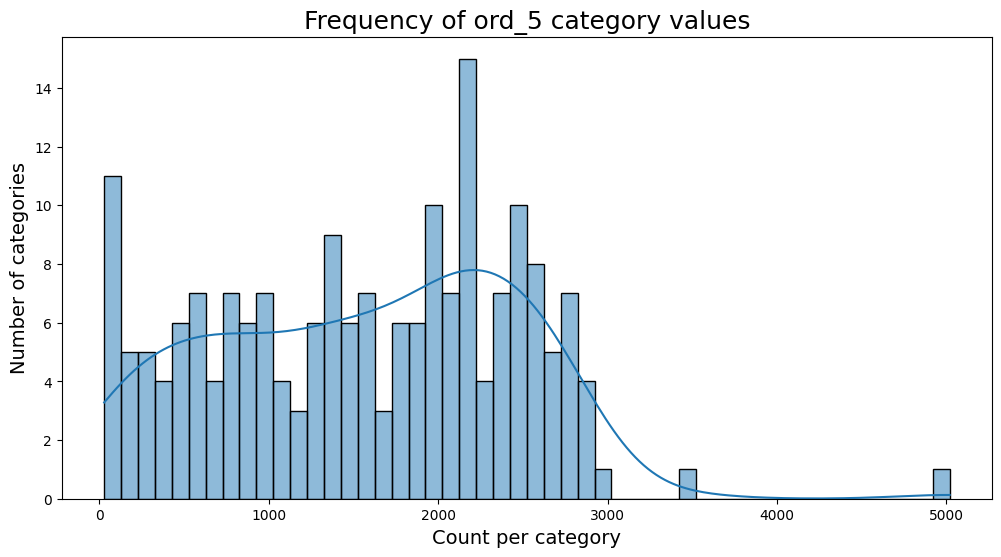

In [ ]:
plt.figure(figsize=(12,6))

g = sns.histplot(ord_5_count, bins=50, kde=True)

g.set_title("Frequency of ord_5 category values", fontsize=18)
g.set_xlabel("Count per category", fontsize=14)
g.set_ylabel("Number of categories", fontsize=14)

plt.show()

We need to transform ord_1, ord_2 and ord_3 to set it in the correctly order to feed the machine learning model;

In [ ]:
# Importing categorical options of pandas
from pandas.api.types import CategoricalDtype 

# seting the orders of our ordinal features
ord_1 = CategoricalDtype(categories=['Novice', 'Contributor','Expert', 
                                     'Master', 'Grandmaster'], ordered=True)
ord_2 = CategoricalDtype(categories=['Freezing', 'Cold', 'Warm', 'Hot',
                                     'Boiling Hot', 'Lava Hot'], ordered=True)
ord_3 = CategoricalDtype(categories=['a', 'b', 'c', 'd', 'e', 'f', 'g',
                                     'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o'], ordered=True)
ord_4 = CategoricalDtype(categories=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I',
                                     'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R',
                                     'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'], ordered=True)

In [ ]:
# Transforming ordinal Features
X_train.ord_1 = X_train.ord_1.astype(ord_1)
X_train.ord_2 = X_train.ord_2.astype(ord_2)
X_train.ord_3 = X_train.ord_3.astype(ord_3)
X_train.ord_4 = X_train.ord_4.astype(ord_4)

# test dataset
X_test.ord_1 = X_test.ord_1.astype(ord_1)
X_test.ord_2 = X_test.ord_2.astype(ord_2)
X_test.ord_3 = X_test.ord_3.astype(ord_3)
X_test.ord_4 = X_test.ord_4.astype(ord_4)

Ok, now it's ordered and we can get the codes that corresponds to each value in the nominal feature;

In [ ]:
# Geting the codes of ordinal categoy's - train
X_train.ord_1 = X_train.ord_1.cat.codes
X_train.ord_2 = X_train.ord_2.cat.codes
X_train.ord_3 = X_train.ord_3.cat.codes
X_train.ord_4 = X_train.ord_4.cat.codes

# Geting the codes of ordinal categoy's - test
X_test.ord_1 = X_test.ord_1.cat.codes
X_test.ord_2 = X_test.ord_2.cat.codes
X_test.ord_3 = X_test.ord_3.cat.codes
X_test.ord_4 = X_test.ord_4.cat.codes

In [ ]:
X_train[['ord_0', 'ord_1', 'ord_2', 'ord_3']].head()

,ord_0,ord_1,ord_2,ord_3
0,2,4,1,7
1,1,4,3,0
2,1,2,5,7
3,1,4,4,8
4,1,4,0,0


**Date Features**

In [ ]:
date_cols = ['day', 'month']


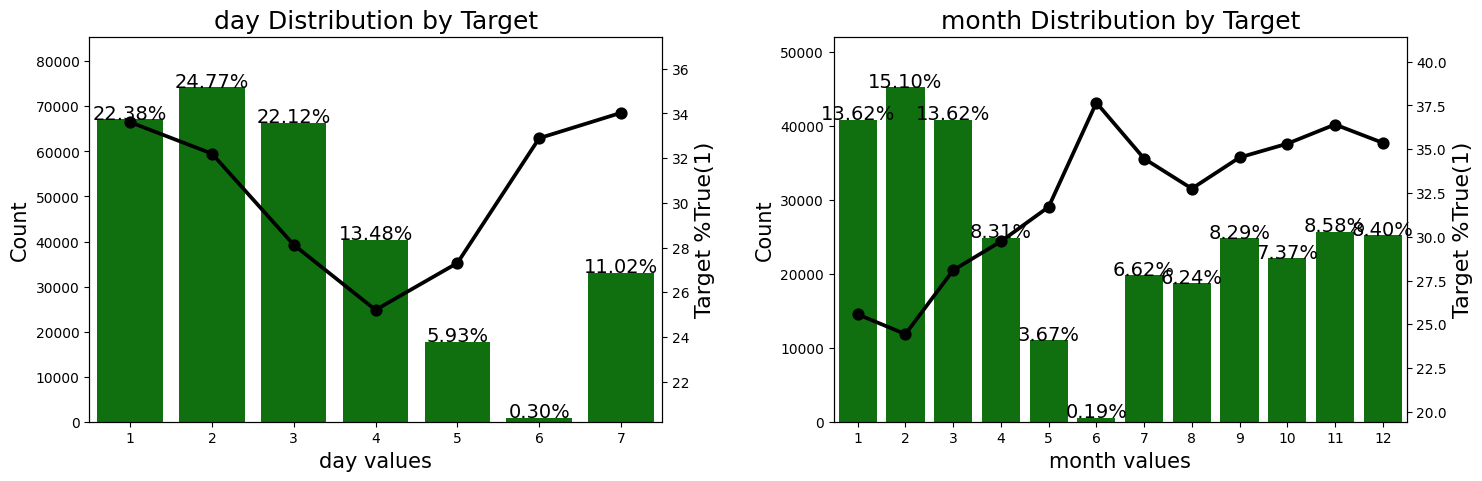

In [ ]:



def ploting_cat_fet(df, cols, vis_row=5, vis_col=2):
    
    grid = gridspec.GridSpec(vis_row,vis_col) # The grid of chart
    plt.figure(figsize=(17, 35)) # size of figure

    # loop to get column and the count of plots
    for n, col in enumerate(df_train[cols]): 
        tmp = pd.crosstab(df_train[col], df_train['target'], normalize='index') * 100
        tmp = tmp.reset_index()
        tmp.rename(columns={0:'No',1:'Yes'}, inplace=True)

        ax = plt.subplot(grid[n]) # feeding the figure of grid
        sns.countplot(x=col, data=df_train, order=list(tmp[col].values) , color='green') 
        ax.set_ylabel('Count', fontsize=15) # y axis label
        ax.set_title(f'{col} Distribution by Target', fontsize=18) # title label
        ax.set_xlabel(f'{col} values', fontsize=15) # x axis label

        # twinX - to build a second yaxis
        gt = ax.twinx()
        gt = sns.pointplot(x=col, y='Yes', data=tmp,
                           order=list(tmp[col].values),
                           color='black', legend=False)
        gt.set_ylim(tmp['Yes'].min()-5,tmp['Yes'].max()*1.1)
        gt.set_ylabel("Target %True(1)", fontsize=16)
        sizes=[] # Get highest values in y
        for p in ax.patches: # loop to all objects
            height = p.get_height()
            sizes.append(height)
            ax.text(p.get_x()+p.get_width()/2.,
                    height + 3,
                    '{:1.2f}%'.format(height/total*100),
                    ha="center", fontsize=14) 
        ax.set_ylim(0, max(sizes) * 1.15) # set y limit based on highest heights


    plt.subplots_adjust(hspace = 0.5, wspace=.3)
    plt.show()




# Calling the plot function with date columns
ploting_cat_fet(df_train, date_cols, vis_row=5, vis_col=2)

In [ ]:
# Transfer the cyclical features into two dimensional sin-cos features
# https://www.kaggle.com/avanwyk/encoding-cyclical-features-for-deep-learning

def date_cyc_enc(df, col, max_vals):
    df[col + '_sin'] = np.sin(2 * np.pi * df[col]/max_vals)
    df[col + '_cos'] = np.cos(2 * np.pi * df[col]/max_vals)
    return df

X_train = date_cyc_enc(X_train, 'day', 7)
X_test = date_cyc_enc(X_test, 'day', 7) 

X_train = date_cyc_enc(X_train, 'month', 12)
X_test = date_cyc_enc(X_test, 'month', 12)

# NOTE, I discovered it on: kaggle.com/gogo827jz/catboost-baseline-with-feature-importance

In [ ]:
X_train.to_csv('../data/X_train_prep.csv', index=False)
X_test.to_csv('../data/X_test_prep.csv', index=False)

In [ ]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df


X_train = reduce_mem_usage(X_train)
X_test = reduce_mem_usage(X_test)



Mem. usage decreased to 70.43 Mb (69.1% reduction)
Mem. usage decreased to 41.58 Mb (71.6% reduction)


In [ ]:
X_train.to_csv("../data/X_train_ready.csv", index=False)
X_test.to_csv("../data/X_test_ready.csv", index=False)


**Heirarchical Clustering**

In [ ]:
import numpy as np

import plotly.figure_factory as ff
import plotly.express as px

from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform


pearson_corr = X_train.corr(method="pearson")

dissimilarity = 1 - np.abs(pearson_corr)

FONT_COLOR = "black"
BACKGROUND_COLOR = "white"
fig = ff.create_dendrogram(
    dissimilarity,
    labels=pearson_corr.columns,
    orientation="left",
    colorscale=px.colors.sequential.YlGnBu_r,
    # squareform() returns lower triangular in compressed form - as 1D array.
    linkagefun=lambda x: linkage(squareform(dissimilarity), method="complete"),
)
fig.update_layout(
    font_color=FONT_COLOR,
    title="Hierarchical Clustering using Correlation Matrix (Pearson)",
    title_font_size=18,
    plot_bgcolor=BACKGROUND_COLOR,
    paper_bgcolor=BACKGROUND_COLOR,
    height=1340,
    width=840,
    yaxis=dict(
        showline=False,
        title="Feature",
        ticks="",
    ),
    xaxis=dict(
        showline=False,
        title="Distance",
        ticks="",
        range=[-0.05, 1.05],
    ),
)
fig.update_traces(line_width=1.5)
fig.show()

**parallel coordinates plot**

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(
    go.Parcoords(
        dimensions=[
            dict(
                label="Beta",
                values=greeks_codes.Beta,
                tickvals=np.unique(greeks_codes.Beta),
                ticktext=greeks_cats.Beta.cat.categories,
            ),
            dict(
                label="Gamma",
                values=greeks_codes.Gamma,
                tickvals=np.unique(greeks_codes.Gamma),
                ticktext=greeks_cats.Gamma.cat.categories,
            ),
            dict(
                label="Delta",
                values=greeks_codes.Delta,
                tickvals=np.unique(greeks_codes.Delta),
                ticktext=greeks_cats.Delta.cat.categories,
            ),
            dict(
                label="Alpha",
                values=greeks_codes.Alpha,
                tickvals=np.unique(greeks_codes.Alpha),
                ticktext=greeks_cats.Alpha.cat.categories,
            ),
            dict(
                label="Class",
                values=greeks.Class,
                tickvals=np.unique(greeks.Class),
            ),
        ],
        line=dict(
            color=greeks.Class,
            colorscale=color_map,
            showscale=True,
            colorbar=dict(
                title="Class",
                orientation="h",
                title_side="bottom",
                yanchor="bottom",
                xanchor="center",
                y=-0.35,
                x=0.5,
                nticks=2,
            ),
        ),
    )
)

fig.update_layout(
    font_color=FONT_COLOR,
    title="Greeks - Parallel Coordinates",
    title_font_size=18,
    plot_bgcolor=BACKGROUND_COLOR,
    paper_bgcolor=BACKGROUND_COLOR,
    height=540,
    width=840,
)
fig.update_traces(
    labelfont=dict(family="Arial Black", size=10),
    tickfont=dict(family="Arial Black", size=10),
    selector=dict(type="parcoords"),
)
fig.show()



**Bivariate Outliers detection Using Mahalanobis Distance**

Mahalanobis Distance (MD) is an effective distance metric that finds the distance between the point and the distribution. It works quite effectively on multivariate data because it uses a covariance matrix of variables to find the distance between data points and the center. This means that MD detects outliers based on the distribution pattern of data points, unlike the Euclidean distance.

<mark> the points outside the ellipse are detected as outliers. This ellipse represents the area that wraps non-outlier values according to Mahalanobis Distance.</mark>

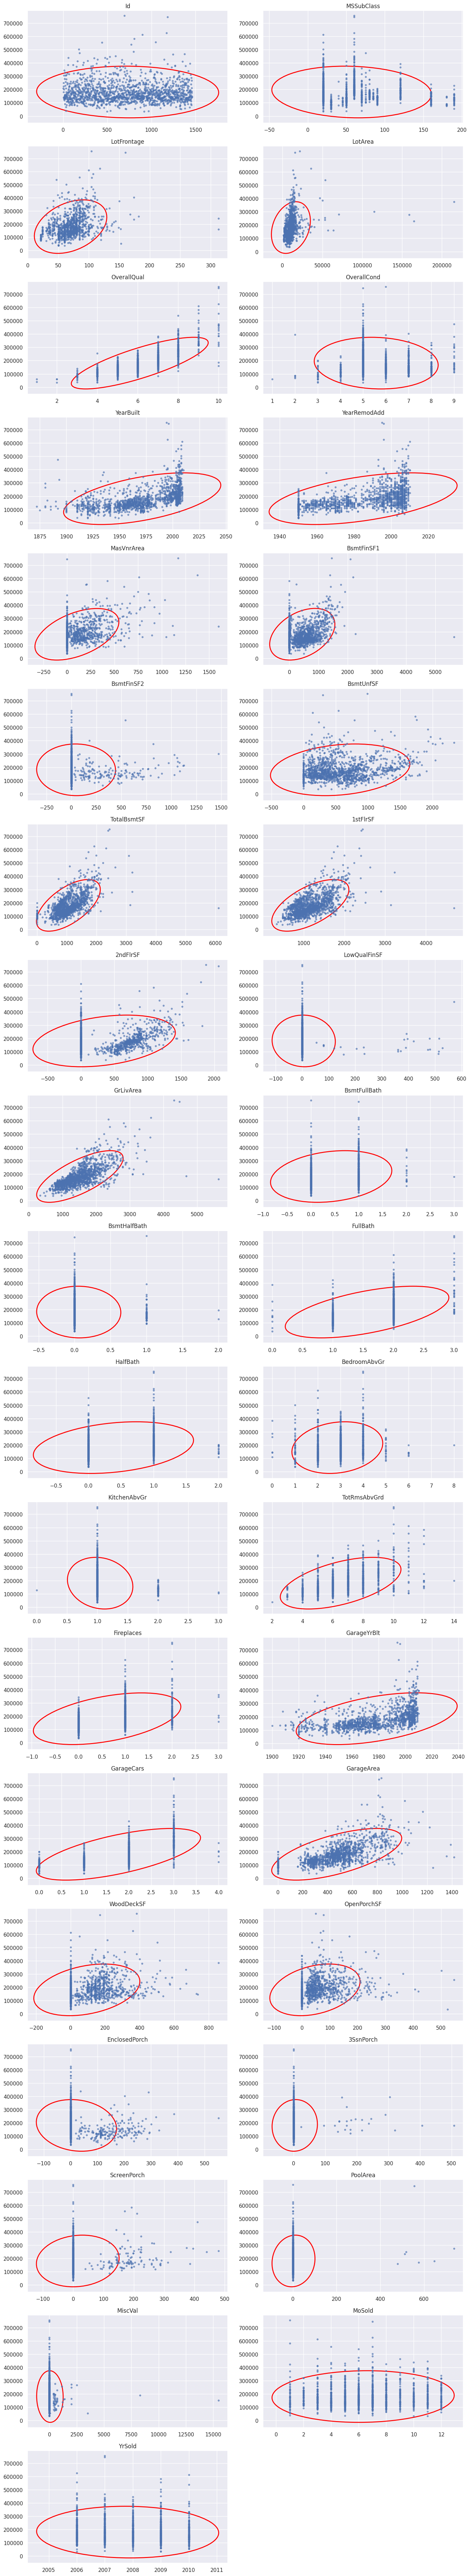

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import chi2

cols = X_train[num_cols].columns

n_cols = 2
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):

    df_x = X_train[[col]].dropna()
    y = y_train.loc[df_x.index]

    if len(df_x) < 3:
        axes[i].axis("off")
        continue

    data = np.column_stack((df_x.values, y.values))

    # covariance
    cov = np.cov(data, rowvar=False)

    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        axes[i].axis("off")
        continue

    center = np.mean(data, axis=0)

    # Mahalanobis distances
    diff = data - center
    distances = np.sum(diff @ cov_inv * diff, axis=1)

    cutoff = chi2.ppf(0.95, df=data.shape[1])

    # eigen for ellipse
    eigvals, eigvecs = np.linalg.eig(cov)
    eigvals = np.sqrt(np.abs(eigvals))

    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    ax = axes[i]

    ellipse = patches.Ellipse(
        xy=center,
        width=eigvals[0] * np.sqrt(cutoff) * 2,
        height=eigvals[1] * np.sqrt(cutoff) * 2,
        angle=angle,
        edgecolor="red",
        facecolor="none",
        linewidth=2
    )

    ax.add_patch(ellipse)

    ax.scatter(data[:, 0], data[:, 1], s=10, alpha=0.6)

    ax.set_title(col)
    ax.grid(True)

# hide empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

**Chi-Square Test** For Categorical Features



There are two types of chi-square tests. Both use the chi-square statistic and distribution for different purposes:

- A chi-square goodness of fit test determines if sample data matches a population.

- A chi-square test for independence compares two variables in a contingency table to see if they are related. In a more general sense, it tests to see whether distributions of categorical variables differ from each another.


The second type is of interest here.

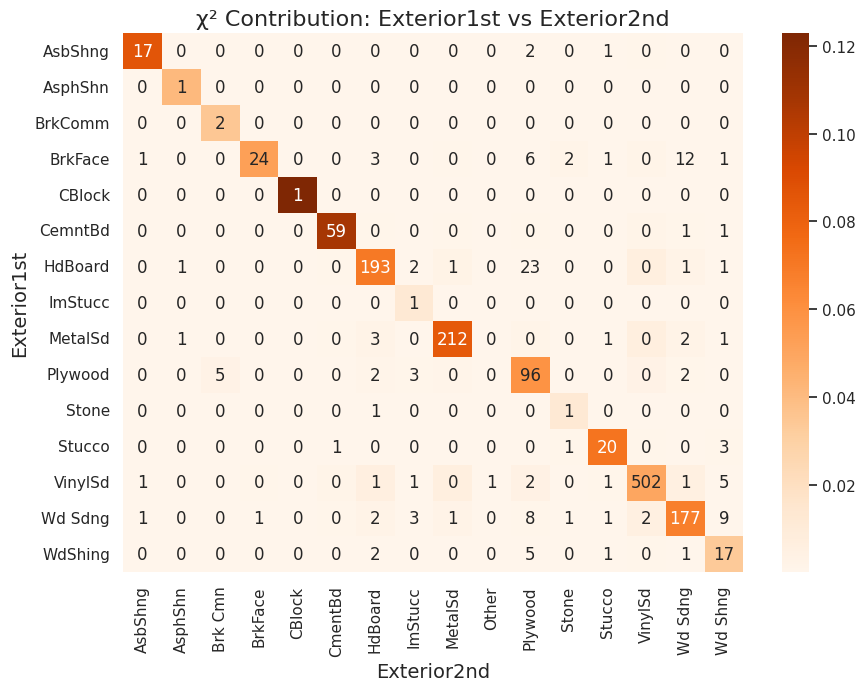

P-value between Exterior1st and Exterior2nd: 0.0



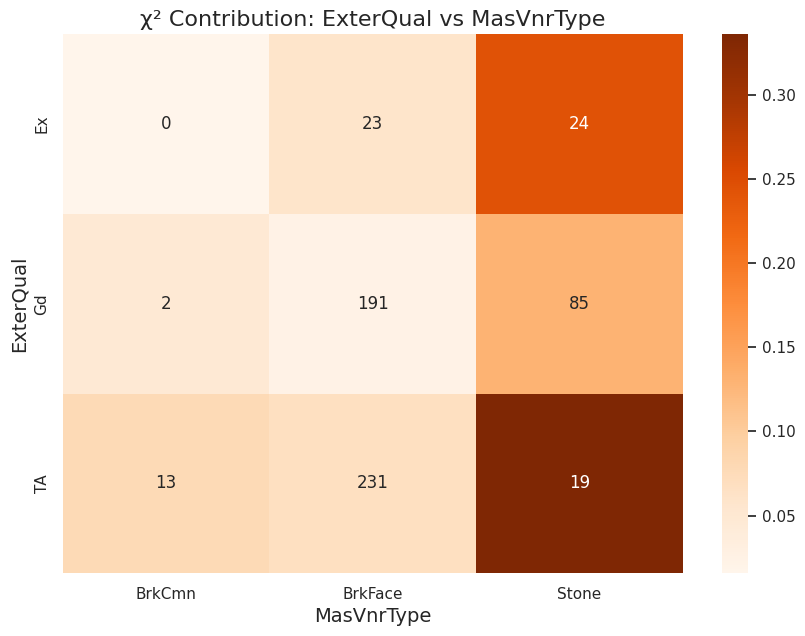

P-value between ExterQual and MasVnrType: 1.1626591994363518e-15



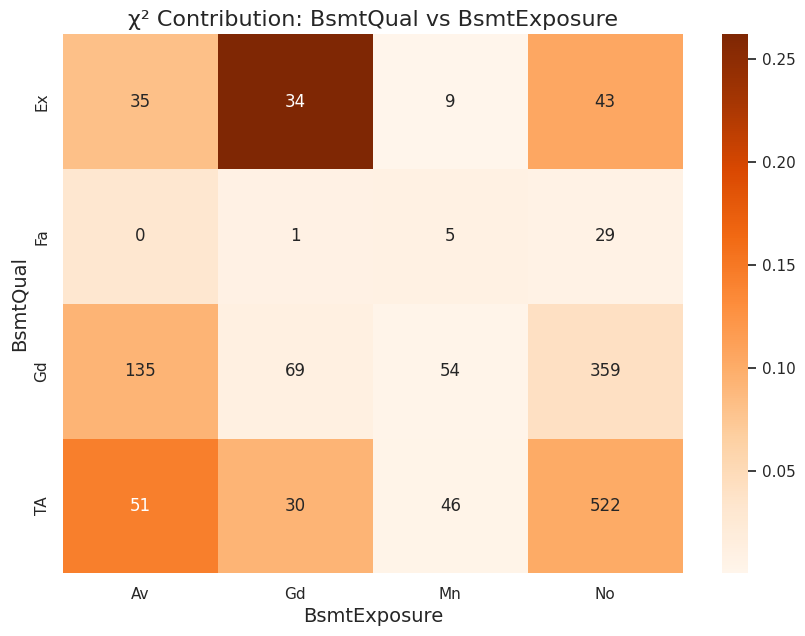

P-value between BsmtQual and BsmtExposure: 3.879215036512606e-32



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

sns.set(rc={"figure.figsize": (10, 7)})

X = ["Exterior1st", "ExterQual", "BsmtQual"]
Y = ["Exterior2nd", "MasVnrType", "BsmtExposure"]

for i, j in zip(X, Y):

    # Contingency table (counts)
    cont = pd.crosstab(X_train[i], X_train[j])

    # Expected frequencies
    chi2, p, dof, expected = chi2_contingency(cont)

    # Avoid division by zero
    expected = np.where(expected == 0, 1e-10, expected)

    # Chi-square contribution table
    measure = (cont - expected) ** 2 / expected
    table = measure / measure.values.sum()

    # Plot heatmap
    plt.figure(figsize=(10, 7))
    ax = sns.heatmap(
        table,
        annot=cont,
        fmt="d",
        cmap="Oranges"
    )

    ax.set_xlabel(j, fontsize=14)
    ax.set_ylabel(i, fontsize=14)
    ax.set_title(f"χ² Contribution: {i} vs {j}", fontsize=16)

    plt.show()

    # Print p-value
    print(f"P-value between {i} and {j}: {p}\n")

After performing the Chi-squared test for each pairs of variables considered, we see that there is strong co-dependency for each of these variables. Since highly dependent/correlated variables do not add much relevant new information with regards to the value of the target variable, we will drop one of each co-dependent variable from the dataset.

In [ ]:
# Drop the one of each co-dependent variables
# Training set
X_train.drop(Y, axis=1, inplace=True)

# Test set
X_test.drop(Y, axis=1, inplace=True)

print(f"Training set shape (Categorical features): {X_train.shape}\n")
print(f"Test set shape (Categorical features): {X_test.shape}\n")


Training set shape (Categorical features): (1460, 77)

Test set shape (Categorical features): (1459, 77)



**Cook distance**

By calculating Cook distance we can detect influential observations in a regression model. Cook distance detects data with large residuals (outliers) that can distort the prediction and the accuracy of a regression.

“If I remove this observation, how much would my model change?”

- If removing a point changes the model a lot → high Cook’s Distance
- If it barely changes anything → low Cook’s Distance

Influential points can:

- Distort regression coefficients
- Mislead interpretation
- Hurt generalization


<mark>Remove the influential observation</mark>

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


# =========================
# 1. PREPARE DATA (ASSUMES ALREADY CLEAN)
# =========================
def prepare_ols_data(X, y):
    X = pd.get_dummies(X, drop_first=True)
    X = X.astype(float).fillna(0)
    y = y.astype(float).fillna(y.mean())

    X, y = X.align(y, join='inner', axis=0)
    X = sm.add_constant(X)

    return X, y


# =========================
# 2. FIT MODEL
# =========================
def fit_model(X, y):
    model = sm.OLS(y, X).fit()
    return model


# =========================
# 3. FULL INFLUENCE METRICS
# =========================
def get_influence_df(model):
    influence = model.get_influence()

    df = pd.DataFrame({
        "Cook_Distance": influence.cooks_distance[0],
        "Leverage": influence.hat_matrix_diag,
        "Studentized_Residuals": influence.resid_studentized_external
    })

    return df


# =========================
# 4. SMART THRESHOLDS (NOT NAIVE)
# =========================
def compute_thresholds(influence_df, n, p):
    thresholds = {
        "cook": 4 / n,
        "leverage": 2 * (p / n),
        "residual": 3  # |residual| > 3
    }
    return thresholds


# =========================
# 5. FLAG INFLUENTIAL POINTS (ADVANCED LOGIC)
# =========================
def flag_influential(df, thresholds):
    df["High_Cook"] = df["Cook_Distance"] > thresholds["cook"]
    df["High_Leverage"] = df["Leverage"] > thresholds["leverage"]
    df["High_Residual"] = np.abs(df["Studentized_Residuals"]) > thresholds["residual"]

    # Strong influence = combination (THIS IS KEY)
    df["Influential"] = (
        df["High_Cook"] |
        (df["High_Leverage"] & df["High_Residual"])
    )

    return df


# =========================
# 6. VISUAL DIAGNOSTIC (PRO LEVEL)
# =========================
def influence_plot(df, thresholds):
    plt.figure(figsize=(10, 6))

    scatter = plt.scatter(
        df["Leverage"],
        df["Studentized_Residuals"],
        s=1000 * df["Cook_Distance"],  # size = influence
        alpha=0.5
    )

    plt.axhline(thresholds["residual"], color='red', linestyle='--')
    plt.axhline(-thresholds["residual"], color='red', linestyle='--')
    plt.axvline(thresholds["leverage"], color='green', linestyle='--')

    plt.xlabel("Leverage")
    plt.ylabel("Studentized Residuals")
    plt.title("Influence Plot (Size = Cook's Distance)")

    plt.show()


# =========================
# 7. REMOVE INFLUENTIAL POINTS (SMART)
# =========================
def remove_influential(X, y, df):
    mask = ~df["Influential"]
    return X[mask], y[mask]


# =========================
# 8. FULL EXECUTION
# =========================

# Prepare data
X_ols, y_ols = prepare_ols_data(X_train, y_train)

# Fit
model = fit_model(X_ols, y_ols)

# Influence metrics
influence_df = get_influence_df(model)

# Thresholds
n, p = X_ols.shape
thresholds = compute_thresholds(influence_df, n, p)

# Flag
influence_df = flag_influential(influence_df, thresholds)

# Top influential points
print("\nTop Influential Observations:")
print(influence_df.sort_values("Cook_Distance", ascending=False).head(10))

# Plot
influence_plot(influence_df, thresholds)

# Remove (optional)
X_clean, y_clean = remove_influential(X_ols, y_ols, influence_df)

# Refit
model_clean = fit_model(X_clean, y_clean)

print("\nOriginal vs Cleaned R²:")
print(f"Original R²: {model.rsquared:.4f}")
print(f"Cleaned  R²: {model_clean.rsquared:.4f}")

KeyboardInterrupt: 

[]

**Identify and Remove Outliers**

Now time to start fitting some models! First I fit a linear regression Ridge model, because it immediately gives good results with default values. My goal here is to use a straightforward model to identify any outlying points - properties with sale prices far away from what's expected given their features.

The function I define below fits the model and checks the residuals between the model's predicted sale prices and the true sale prices. The standard deviation of the residuals is calculated, and the 20 or so properties with residuals greater than three times this standard deviation are removed from the training data so they don't skew the parameters of the fitted models.

Just Ridge with default values already gives a decent prediction, which is a promising sign.

<mark>Improved a lot?</mark>

Instead of removing try:

```python
X["is_outlier"] = 0
X.loc[outliers, "is_outlier"] = 1
```

(pro move)


Only remove if:
- (residual_outlier) AND (high Cook distance)

R2= 0.8684731987040067
rmse= 0.1448171454352951
---------------------------------------
mean of residuals: -1.0207968412717879e-15
std of residuals: 0.14486676583950456
---------------------------------------
16 outliers:
[30, 410, 462, 495, 523, 632, 812, 874, 916, 968, 970, 1181, 1298, 1324, 1423, 1432]
R2= 0.9197563437486572
rmse= 0.10984659584677689
---------------------------------------
mean of residuals: -1.1625049953138759e-15
std of residuals: 0.10988465113835567
---------------------------------------
13 outliers:
[66, 277, 431, 560, 588, 662, 666, 669, 688, 710, 1244, 1337, 1453]


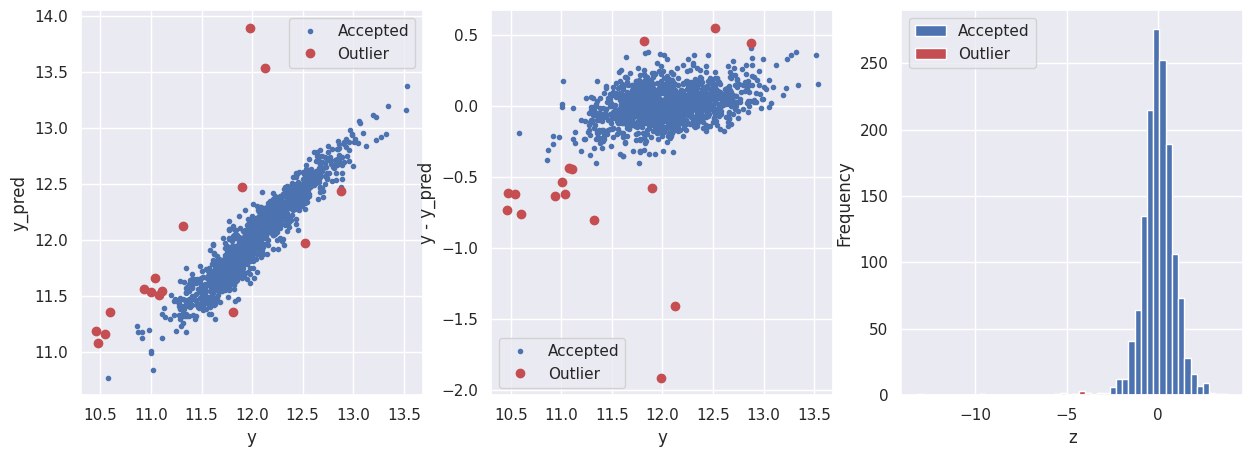

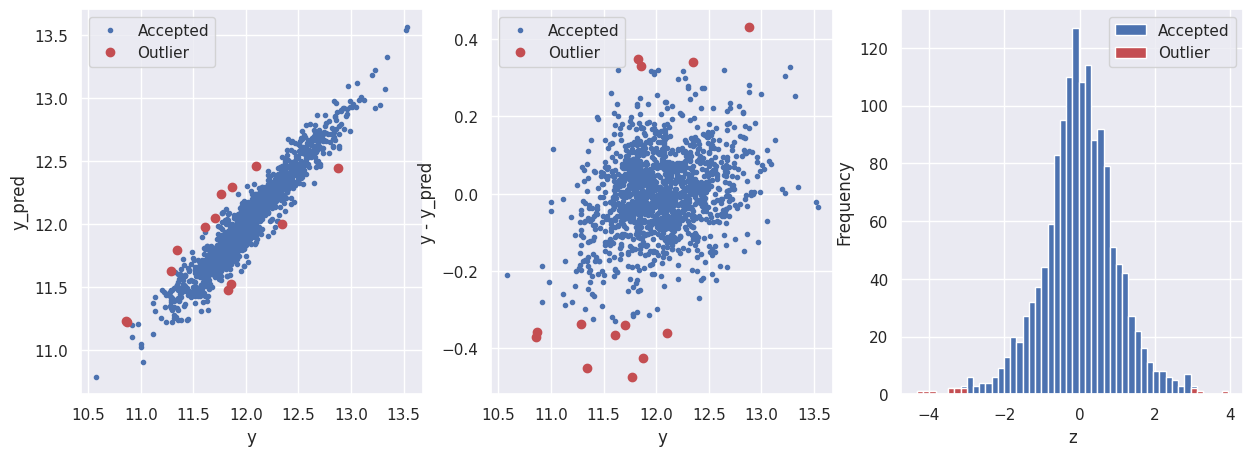

In [ ]:
from sklearn.metrics import make_scorer


def rmse(y_true, y_pred):
    diff = y_pred - y_true
    sum_sq = sum(diff**2)    
    n = len(y_pred)   
    
    return np.sqrt(sum_sq/n)

# scorer to be used in sklearn model fitting
rmse_scorer = make_scorer(rmse, greater_is_better=False)


# function to detect outliers based on the predictions of a model
def find_outliers(model, X, y, sigma=3):

    # predict y values using model
    try:
        y_pred = pd.Series(model.predict(X), index=y.index)
    # if predicting fails, try fitting the model first
    except:
        model.fit(X,y)
        y_pred = pd.Series(model.predict(X), index=y.index)
        
    # calculate residuals between the model prediction and true y values
    resid = y - y_pred
    mean_resid = resid.mean()
    std_resid = resid.std()

    # calculate z statistic, define outliers to be where |z|>sigma
    z = (resid - mean_resid)/std_resid    
    outliers = z[abs(z)>sigma].index
    
    # print and plot the results
    print('R2=',model.score(X,y))
    print('rmse=',rmse(y, y_pred))
    print('---------------------------------------')

    print('mean of residuals:',mean_resid)
    print('std of residuals:',std_resid)
    print('---------------------------------------')

    print(len(outliers),'outliers:')
    print(outliers.tolist())

    plt.figure(figsize=(15,5))
    ax_131 = plt.subplot(1,3,1)
    plt.plot(y,y_pred,'.')
    plt.plot(y.loc[outliers],y_pred.loc[outliers],'ro')
    plt.legend(['Accepted','Outlier'])
    plt.xlabel('y')
    plt.ylabel('y_pred');

    ax_132=plt.subplot(1,3,2)
    plt.plot(y,y-y_pred,'.')
    plt.plot(y.loc[outliers],y.loc[outliers]-y_pred.loc[outliers],'ro')
    plt.legend(['Accepted','Outlier'])
    plt.xlabel('y')
    plt.ylabel('y - y_pred');

    ax_133=plt.subplot(1,3,3)
    z.plot.hist(bins=50,ax=ax_133)
    z.loc[outliers].plot.hist(color='r',bins=50,ax=ax_133)
    plt.legend(['Accepted','Outlier'])
    plt.xlabel('z')
    
    plt.savefig('outliers.png')
    
    return outliers




# get training data
from sklearn.linear_model import Ridge

# this should be fixed
X.fillna(0, inplace=True)
# find and remove outliers using a Ridge model
outliers = find_outliers(Ridge(), X[num_cols], np.log1p(y))

# permanently remove these outliers from the data
X_clean = X.drop(outliers)
y_clean = y.drop(outliers)
# id_train = id_train.drop(outliers)

outliers = find_outliers(Ridge(), X_clean[num_cols], np.log1p(y_clean))


 Imputing with KnnRegressor (we can also use different Imputers)


In [ ]:
# Imputing with KnnRegressor (we can also use different Imputers)

# def impute_knn(df):
#     ttn = train_test.select_dtypes(include=[np.number])
#     ttc = train_test.select_dtypes(exclude=[np.number])

#     cols_nan = ttn.columns[ttn.isna().any()].tolist()         # columns w/ nan 
#     cols_no_nan = ttn.columns.difference(cols_nan).values     # columns w/n nan

#     for col in cols_nan:
#         imp_test = ttn[ttn[col].isna()]   # indicies which have missing data will become our test set
#         imp_train = ttn.dropna()          # all indicies which which have no missing data 
#         model = KNeighborsRegressor(n_neighbors=5)  # KNR Unsupervised Approach
#         knr = model.fit(imp_train[cols_no_nan], imp_train[col])
#         ttn.loc[ttn[col].isna(), col] = knr.predict(imp_test[cols_no_nan])
    
#     return pd.concat([ttn,ttc],axis=1)

# train_test = impute_knn(train_test)


# objects = []
# for i in train_test.columns:
#     if train_test[i].dtype == object:
#         objects.append(i)
# train_test.update(train_test[objects].fillna('None'))

# # # Checking NaN presence

# for col in train_test:
#     if train_test[col].isna().sum() > 0:
#         print(train_test[col][0])


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,548.0,0,61,0,0,0,0,0,2,2008
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,460.0,298,0,0,0,0,0,0,5,2007
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,608.0,0,42,0,0,0,0,0,9,2008
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,642.0,0,35,272,0,0,0,0,2,2006
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,836.0,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0.0,...,460.0,0,40,0,0,0,0,0,8,2007
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790.0,...,500.0,349,0,0,0,0,0,0,2,2010
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275.0,...,252.0,0,60,0,0,0,0,2500,5,2010
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49.0,...,240.0,366,0,112,0,0,0,0,4,2010


In [ ]:
# Combining Customerid , Surname , Geography , and Gender , Estimated Slaray  and Making New Column in both Data Frames 
X_train['Sur_Geo_Gend_Sal'] = X_train['CustomerId'].astype('str')+X_train['Surname']+X_train['Geography']+X_train['Gender']+np.round(X_train.EstimatedSalary).astype('str')
X_test['Sur_Geo_Gend_Sal'] = X_test['CustomerId'].astype('str')+X_test['Surname']+X_test['Geography']+X_test['Gender']+np.round(X_test.EstimatedSalary).astype('str')




*The `get_vectors` function takes two DataFrames `(df_train and df_test)`, and a specified column name (`col_name`). It performs the following steps:

1. Utilizes the TfidfVectorizer to transform the text data in the specified column into TF-IDF vectors, limiting the features to a maximum of 1000.

2. Applies dimensionality reduction using TruncatedSVD with 3 components to further transform the TF-IDF vectors.

3. Converts the transformed vectors into DataFrames (tfidf_df_train and tfidf_df_test).

4. Names the columns in the new DataFrames with a combination of the original column name and additional information.

5. Resets the index of the original DataFrames before concatenation.

6. Concatenates the transformed features with the original data along the columns.

7. Returns the modified training and testing DataFrames.

This function effectively combines TF-IDF vectorization and dimensionality reduction to enhance the original DataFrames with transformed features, facilitating machine learning tasks that involve text data.

*The TF-IDF matrix can be high-dimensional, and TfidfVectorizer helps reduce this dimensionality, making it computationally more efficient and often improving model performance.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
def get_vectors(df_train,df_test,col_name):

    vectorizer = TfidfVectorizer(max_features=1000)
    vectors_train = vectorizer.fit_transform(df_train[col_name])
    vectors_test = vectorizer.transform(df_test[col_name])
    
    #Dimensionality Reduction Using SVD ( Singular Value Decompostion)
    svd = TruncatedSVD(3)
    x_sv_train = svd.fit_transform(vectors_train)
    x_sv_test = svd.transform(vectors_test)

    # Convert to DataFrames
    tfidf_df_train = pd.DataFrame(x_sv_train)
    tfidf_df_test = pd.DataFrame(x_sv_test)

    # Naming columns in the new DataFrames
    cols = [(col_name + "_tfidf_" + str(f)) for f in tfidf_df_train.columns.to_list()]
    tfidf_df_train.columns = cols
    tfidf_df_test.columns = cols

    # Reset the index of the DataFrames before concatenation
    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    # Concatenate transformed features with original data
    df_train = pd.concat([df_train, tfidf_df_train], axis="columns")
    df_test = pd.concat([df_test, tfidf_df_test], axis="columns")
    return df_train,df_test


In [ ]:
X_train,X_test = get_vectors(X_train,X_test,'Surname')
X_train,X_test = get_vectors(X_train,X_test,'Sur_Geo_Gend_Sal')

,Product ID,Type
0,L50096,L
1,M20343,M
2,L49454,L
3,L53355,L
4,M24050,M
...,...,...
136424,M22284,M
136425,H38017,H
136426,L54690,L
136427,L53876,L


In [ ]:
X_train['Sur_Geo_Gend_Sal_tfidf_0'].nunique()

1056


### Class Weights

This code is preparing class weights to handle imbalanced classification problems.

u can then pass it as 
```
model = HistGradientBoostingClassifier(class_weight=class_weights_dict)
```


**Rule of thumb**

- For tree-based models (LightGBM, CatBoost, HistGB): <mark>raw weights</mark> usually work best.
- For linear models or neural networks: <mark>normalized weights</mark> can help stabilize training.

In [ ]:
import numpy as np
import pandas as pd

def compute_class_weights(y, return_normalized=True):
    """
    Compute class weights for imbalanced classification problems.

    Parameters
    ----------
    y : array-like or pd.Series
        Target labels (categorical or numeric).
    return_normalized : bool, default=True
        If True, also return normalized weights (sum to number of classes).

    Returns
    -------
    y_numeric : np.ndarray
        Numeric mapping of the original classes.
    class_to_index : dict
        Mapping from original classes to numeric indices.
    class_counts : np.ndarray
        Number of samples in each class.
    raw_class_weights : np.ndarray
        Raw computed weights: total_samples / (num_classes * class_count).
    normalized_class_weights : np.ndarray or None
        Normalized weights (sum to number of classes), or None if return_normalized=False.
    class_weights_dict : dict
        Mapping from original classes to raw weights (ready for model use).
    normalized_class_weights_dict : dict or None
        Mapping from original classes to normalized weights, or None if return_normalized=False.
    """

    y = np.array(y)
    classes = np.unique(y)

    # Map original classes to numeric indices
    class_to_index = {cls: idx for idx, cls in enumerate(classes)}
    y_numeric = np.array([class_to_index[cls] for cls in y])

    # Count samples per class
    class_counts = np.bincount(y_numeric)
    total_samples = len(y_numeric)
    n_classes = len(classes)

    # Raw class weights
    raw_class_weights = total_samples / (n_classes * class_counts)
    class_weights_dict = {cls: w for cls, w in zip(classes, raw_class_weights)}

    # Normalized weights (optional)
    normalized_class_weights = None
    normalized_class_weights_dict = None
    if return_normalized:
        normalized_class_weights = raw_class_weights / raw_class_weights.sum() * n_classes
        normalized_class_weights_dict = {cls: w for cls, w in zip(classes, normalized_class_weights)}

    return (
        y_numeric,
        class_to_index,
        class_counts,
        raw_class_weights,
        normalized_class_weights,
        class_weights_dict,
        normalized_class_weights_dict
    )

In [ ]:
# Compute class weights
(
    y_numeric,
    class_to_index,
    class_counts,
    raw_weights,
    norm_weights,
    raw_weights_dict,
    norm_weights_dict
) = compute_class_weights(y_train, return_normalized=True)

print("Class counts:", class_counts)
print("Raw weights dict:", raw_weights_dict)
print("Normalized weights dict:", norm_weights_dict)




Class counts: [25296 14940 36282]
Raw weights dict: {'Dropout': 1.0083017077798861, 'Enrolled': 1.7072289156626506, 'Graduate': 0.7029932197784026}
Normalized weights dict: {'Dropout': 0.8848571085259966, 'Enrolled': 1.498215891383776, 'Graduate': 0.6169270000902269}


In [ ]:
# Drop qualitative/redundant/collinear/high cardinality features safely
X_train.drop([cfg.ID], axis=1, inplace=True, errors='ignore')
X_test.drop([], axis=1, inplace=True, errors='ignore')


In [ ]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train_original.to_csv('../data/y_train.csv', index=False)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_original shape:", y_train_original.shape)

X_train shape: (76518, 36)
X_test shape: (51012, 37)
y_train_original shape: (76518,)


In [ ]:
y_train.shape

(76518,)

# One-Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Select categorical features
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Create encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on train and transform train
X_train_encoded = encoder.fit_transform(X_train[categorical_features])

# Transform test
X_test_encoded = encoder.transform(X_test[categorical_features])

# Convert to DataFrame with proper column names
encoded_cols = encoder.get_feature_names_out(categorical_features)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

# Combine with numeric features
numeric_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
X_train_encoded = pd.concat([X_train[numeric_features], X_train_encoded_df], axis=1)
X_test_encoded = pd.concat([X_test[numeric_features], X_test_encoded_df], axis=1)

print("X_train shape:", X_train_encoded.shape)
print("X_test shape:", X_test_encoded.shape)

import re
# Clean column names (in case not done yet)
def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
    cols = pd.Series(df.columns)
    for dup in cols[cols.duplicated()].unique():
        cols[cols == dup] = [f"{dup}_{i}" if i != 0 else dup for i in range(sum(cols == dup))]
    df.columns = cols
    return df

X_train_encoded = clean_column_names(X_train_encoded.copy())
X_test_encoded = clean_column_names(X_test_encoded.copy())




X_train shape: (76518, 36)
X_test shape: (51012, 36)


In [ ]:
test_ids = X_test[cfg.ID]
X_test_encoded[cfg.ID] = test_ids.values

X_train_encoded.to_csv('../data/X_train_encoded.csv', index=False)
X_test_encoded.to_csv('../data/X_test_encoded.csv', index=False)
y_train_original.to_csv('../data/y_train.csv', index=False)




print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)
print("y_train_original shape:", y_train_original.shape)

X_train_encoded shape: (76518, 36)
X_test_encoded shape: (51012, 37)
y_train_original shape: (76518,)


ip                       category
app                      category
device                   category
os                       category
channel                  category
click_time         datetime64[ns]
attributed_time    datetime64[ns]
dtype: object

# Time patterns

In [ ]:
X_train_time = X_train.copy()
X_train_time['is_attributed'] = y_train.copy()
X_test_time = X_test.copy()

**Extracting time information**

In [ ]:
X_train_time['day'] = X_train_time['click_time'].dt.day.astype('uint8')
X_train_time['hour'] = X_train_time['click_time'].dt.hour.astype('uint8')
X_train_time['minute'] = X_train_time['click_time'].dt.minute.astype('uint8')
X_train_time['second'] = X_train_time['click_time'].dt.second.astype('uint8')
X_train_time.head()


,ip,app,device,os,channel,click_time,is_attributed,day,hour,minute,second
0,83230,3,1,13,379,2017-11-06 14:32:21,0,6,14,32,21
1,17357,3,1,19,379,2017-11-06 14:33:34,0,6,14,33,34
2,35810,3,1,13,379,2017-11-06 14:34:12,0,6,14,34,12
3,45745,14,1,13,478,2017-11-06 14:34:52,0,6,14,34,52
4,161007,3,1,13,379,2017-11-06 14:35:08,0,6,14,35,8


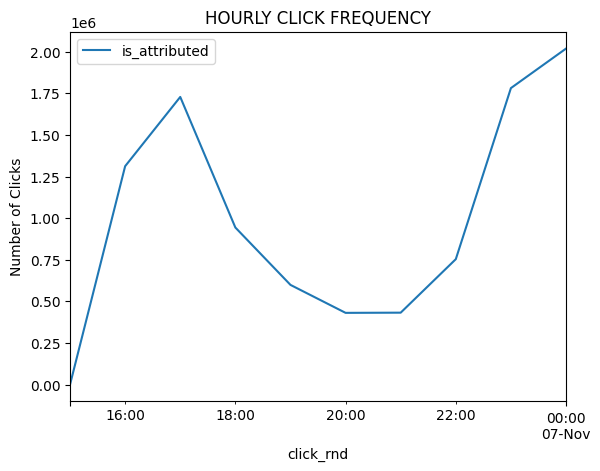

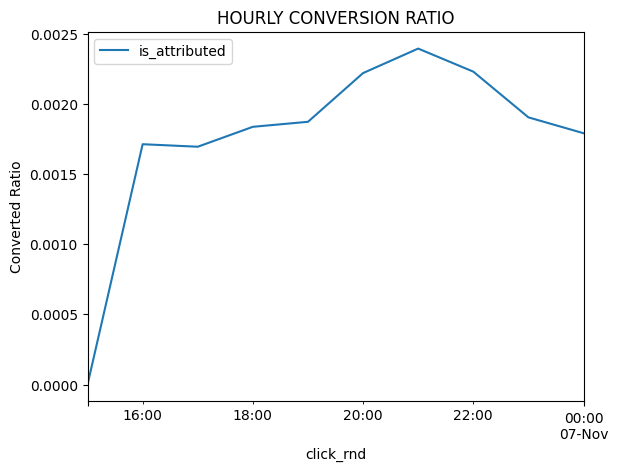

In [ ]:
#round the time to nearest hour
X_train_time['click_rnd']=X_train_time['click_time'].dt.round('H')  

#check for hourly patterns
X_train_time[['click_rnd','is_attributed']].groupby(['click_rnd'], as_index=True).count().plot()
plt.title('HOURLY CLICK FREQUENCY');
plt.ylabel('Number of Clicks');

X_train_time[['click_rnd','is_attributed']].groupby(['click_rnd'], as_index=True).mean().plot()
plt.title('HOURLY CONVERSION RATIO');
plt.ylabel('Converted Ratio');

In [ ]:


#extract hour as a feature
X_train_time['click_hour']=X_train_time['click_time'].dt.hour



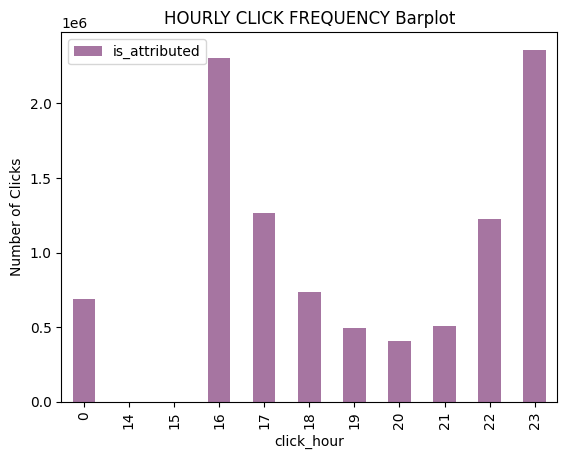

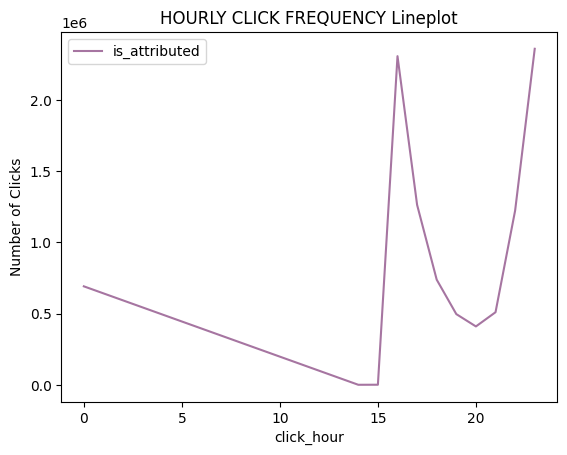

In [ ]:
# number of clicks by hour:
X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=True).count().plot(kind='bar', color='#a675a1')
plt.title('HOURLY CLICK FREQUENCY Barplot');
plt.ylabel('Number of Clicks');

X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=True).count().plot(color='#a675a1')
plt.title('HOURLY CLICK FREQUENCY Lineplot');
plt.ylabel('Number of Clicks');


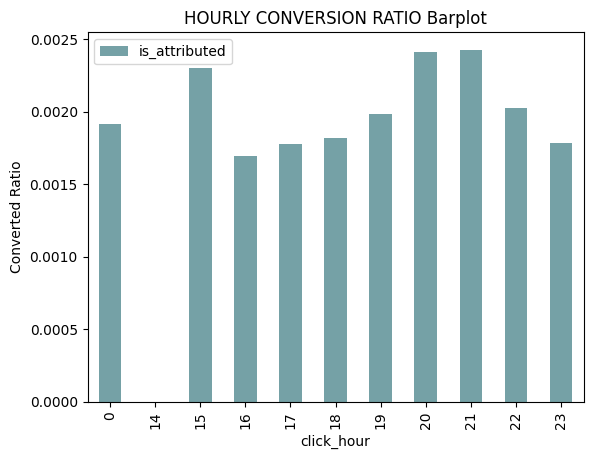

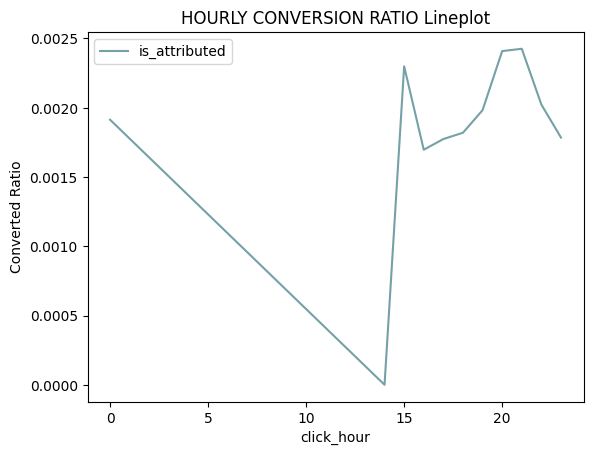

In [ ]:


# number of conversions by hours:

X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=True).mean().plot(kind='bar', color='#75a1a6')
plt.title('HOURLY CONVERSION RATIO Barplot');
plt.ylabel('Converted Ratio');

X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=True).mean().plot( color='#75a1a6')
plt.title('HOURLY CONVERSION RATIO Lineplot');
plt.ylabel('Converted Ratio');


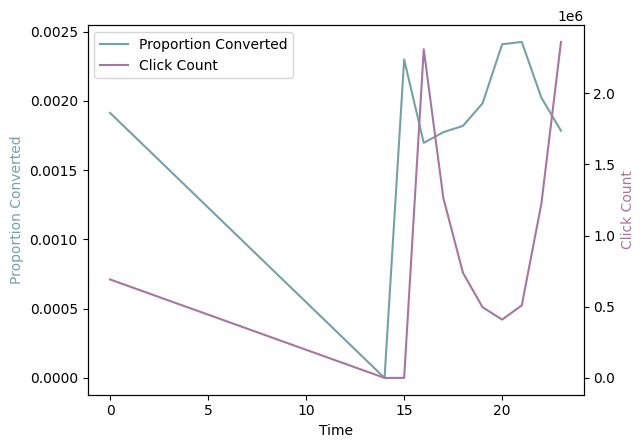

In [ ]:
# 

# let's overlay the two graphs to see if patterns correlate in any way


group = X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=False).mean()
x = group['click_hour']
ymean = group['is_attributed']
group = X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=False).count()
ycount = group['is_attributed']


fig = plt.figure()
host = fig.add_subplot(111)

par1 = host.twinx()

host.set_xlabel("Time")
host.set_ylabel("Proportion Converted")
par1.set_ylabel("Click Count")

#color1 = plt.cm.viridis(0)
#color2 = plt.cm.viridis(0.5)
color1 = '#75a1a6'
color2 = '#a675a1'

p1, = host.plot(x, ymean, color=color1,label="Proportion Converted")
p2, = par1.plot(x, ycount, color=color2, label="Click Count")

lns = [p1, p2]
host.legend(handles=lns, loc='best')

host.yaxis.label.set_color(p1.get_color())
par1.yaxis.label.set_color(p2.get_color())

plt.savefig("pyplot_multiple_y-axis.png", bbox_inches='tight')


#### Geospatial data



Latitude & Longitude:

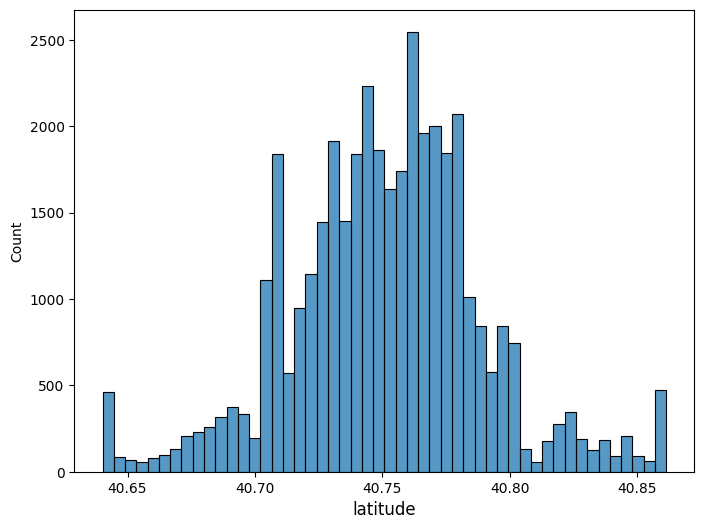

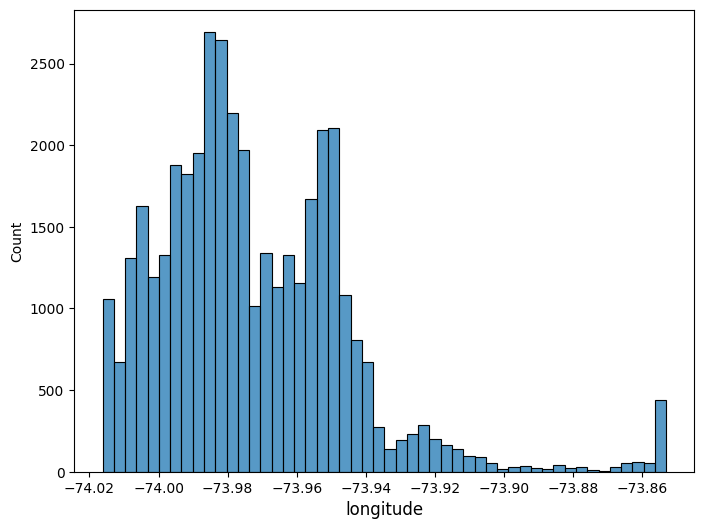

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute 1st and 99th percentiles
llimit = np.percentile(X_train.latitude.values, 1)
ulimit = np.percentile(X_train.latitude.values, 99)

# Clip values using .loc
X_train.loc[X_train['latitude'] < llimit, 'latitude'] = llimit
X_train.loc[X_train['latitude'] > ulimit, 'latitude'] = ulimit

# Plot histogram
plt.figure(figsize=(8,6))
sns.histplot(X_train.latitude.values, bins=50, kde=False)  # use histplot instead of distplot
plt.xlabel('latitude', fontsize=12)
plt.show()

# Compute 1st and 99th percentiles
llimit = np.percentile(X_train.longitude.values, 1)
ulimit = np.percentile(X_train.longitude.values, 99)

# Clip outliers using .loc
X_train.loc[X_train['longitude'] < llimit, 'longitude'] = llimit
X_train.loc[X_train['longitude'] > ulimit, 'longitude'] = ulimit

# Alternatively, a one-liner using clip:
# X_train['longitude'] = X_train['longitude'].clip(llimit, ulimit)

# Plot histogram
plt.figure(figsize=(8,6))
sns.histplot(X_train['longitude'].values, bins=50, kde=False)  # distplot is deprecated
plt.xlabel('longitude', fontsize=12)
plt.show()




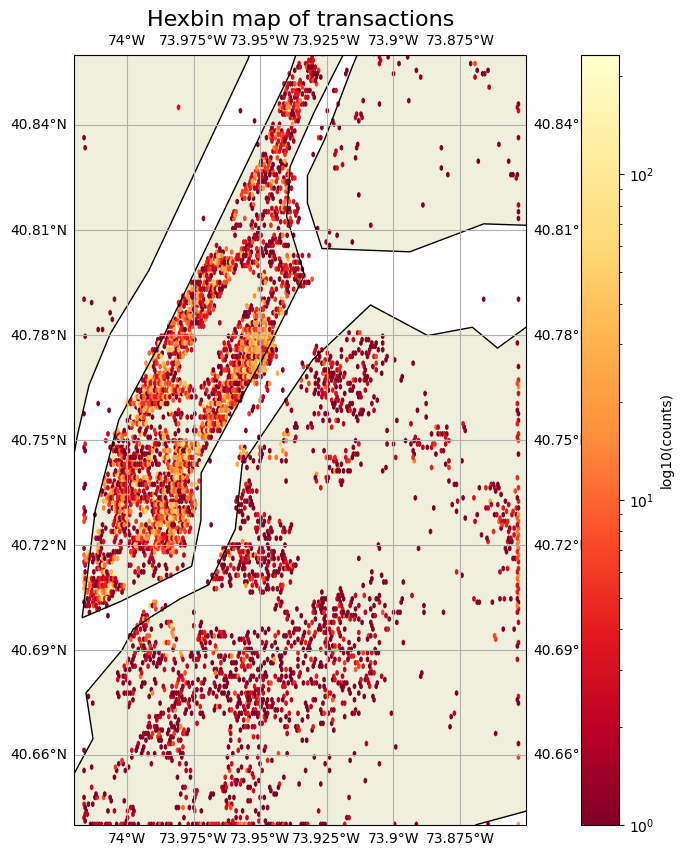

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


# make sure to change those based on ur data
west, south, east, north = -74.02, 40.64, -73.85, 40.86

fig = plt.figure(figsize=(14,10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())

# Add land, coastlines, and gridlines
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(draw_labels=True)

# Plot points as a scatter or hexbin
hb = ax.hexbin(
    X_train['longitude'].values,
    X_train['latitude'].values,
    gridsize=200,
    bins='log',
    cmap='YlOrRd_r',
    transform=ccrs.PlateCarree()  # your data is in lat/lon
)

plt.colorbar(hb, ax=ax, label='log10(counts)')
plt.title('Hexbin map of transactions', fontsize=16)
plt.show()


Created/date_created

- are train and test from the same range data?
  

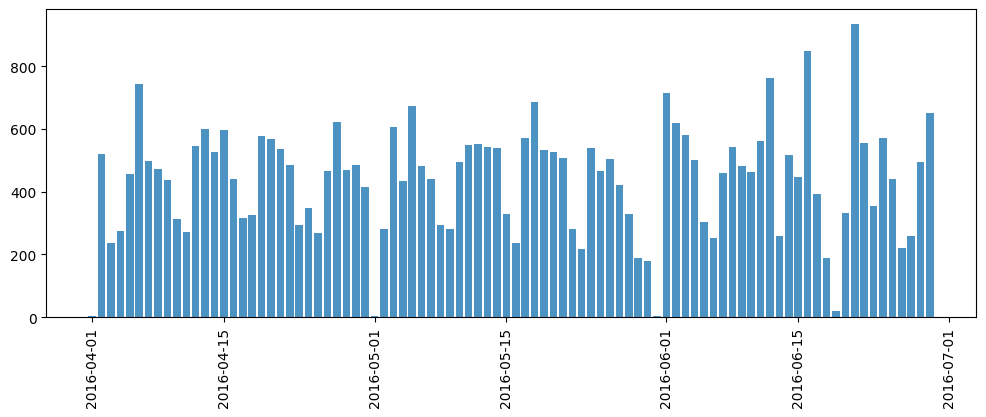

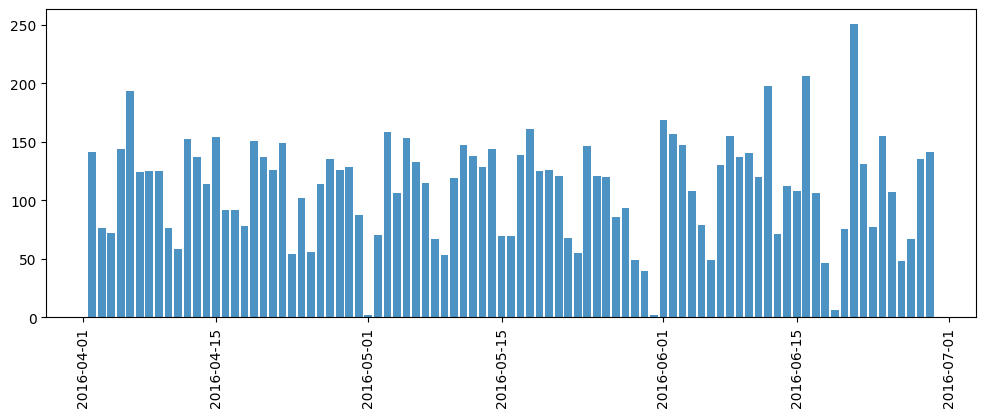

In [ ]:
X_train["created"] = pd.to_datetime(X_train["created"])
X_train["date_created"] = X_train["created"].dt.date
cnt_srs = X_train['date_created'].value_counts()


plt.figure(figsize=(12,4))
ax = plt.subplot(111)
ax.bar(cnt_srs.index, cnt_srs.values, alpha=0.8)
ax.xaxis_date()
plt.xticks(rotation='vertical')
plt.show()


X_test["created"] = pd.to_datetime(X_test["created"])
X_test["date_created"] = X_test["created"].dt.date
cnt_srs = X_test['date_created'].value_counts()

plt.figure(figsize=(12,4))
ax = plt.subplot(111)
ax.bar(cnt_srs.index, cnt_srs.values, alpha=0.8)
ax.xaxis_date()
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# convert the created column to datetime object so as to extract more features 
X_train["created"] = pd.to_datetime(X_train["created"])
X_test["created"] = pd.to_datetime(X_test["created"])

# Let us extract some features like year, month, day, hour from date columns #
X_train["created_year"] = X_train["created"].dt.year
X_test["created_year"] = X_test["created"].dt.year
X_train["created_month"] = X_train["created"].dt.month
X_test["created_month"] = X_test["created"].dt.month
X_train["created_day"] = X_train["created"].dt.day
X_test["created_day"] = X_test["created"].dt.day
X_train["created_hour"] = X_train["created"].dt.hour
X_test["created_hour"] = X_test["created"].dt.hour

Display Address:

Display_address that appear less than 2 times: 63.02%
Display_address that appear less than 10 times: 90.04%
Display_address that appear less than 50 times: 97.96%
Display_address that appear less than 100 times: 99.41%
Display_address that appear less than 500 times: 100.0%


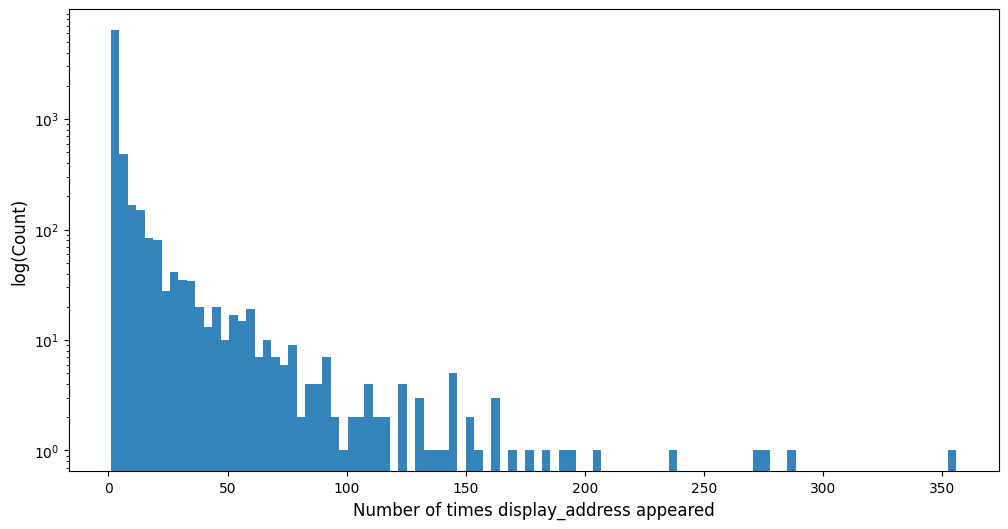

In [ ]:
cnt_srs = X_train.groupby('display_address')['display_address'].count()

for i in [2, 10, 50, 100, 500]:
    print('Display_address that appear less than {} times: {}%'.format(i, round((cnt_srs < i).mean() * 100, 2)))

plt.figure(figsize=(12, 6))
plt.hist(cnt_srs.values, bins=100, log=True, alpha=0.9)
plt.xlabel('Number of times display_address appeared', fontsize=12)
plt.ylabel('log(Count)', fontsize=12)
plt.show()

features col

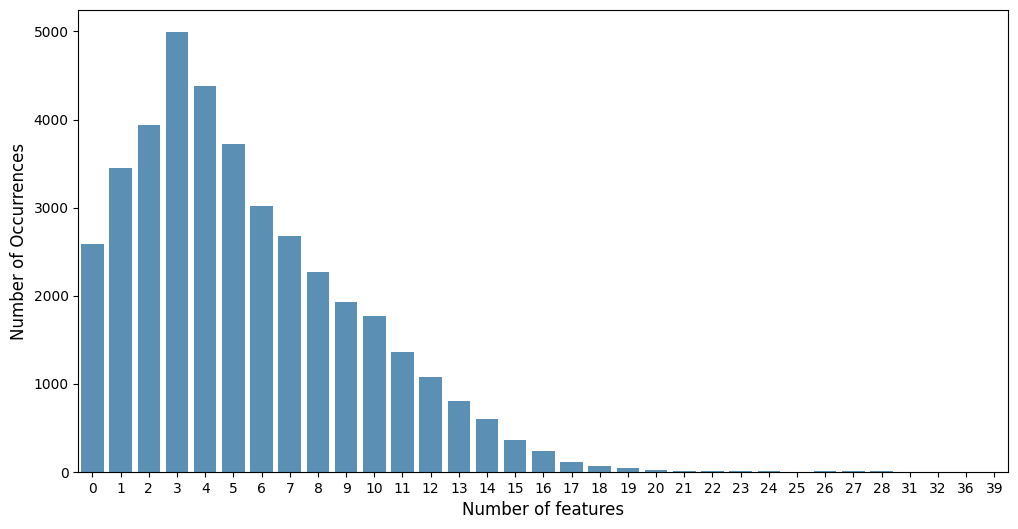

In [ ]:
X_train["num_features"] = X_train["features"].apply(len)

cnt_srs = X_train['num_features'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=cnt_srs.index,
    y=cnt_srs.values,
    alpha=0.8
)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Number of features', fontsize=12)
plt.show()


**Word Clouds:**

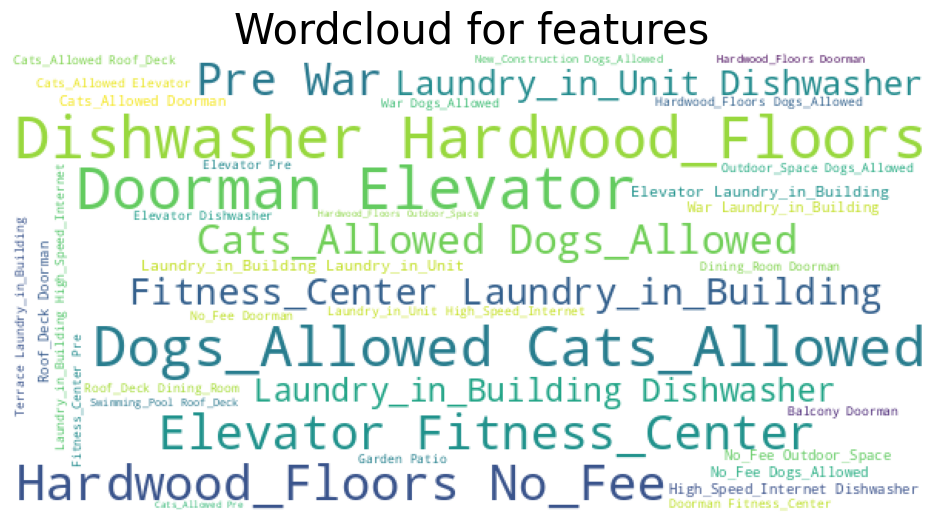

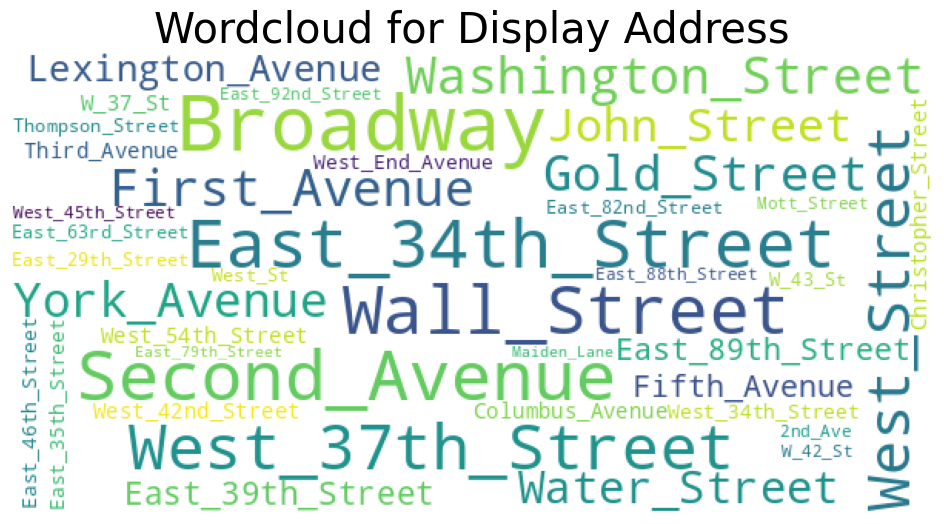

In [ ]:
from wordcloud import WordCloud

text = ''
text_da = ''
text_desc = ''
for ind, row in X_train.iterrows():
    for feature in row['features']:
        text = " ".join([text, "_".join(feature.strip().split(" "))])
    text_da = " ".join([text_da,"_".join(row['display_address'].strip().split(" "))])
    #text_desc = " ".join([text_desc, row['description']])
text = text.strip()
text_da = text_da.strip()
text_desc = text_desc.strip()

plt.figure(figsize=(12,6))
wordcloud = WordCloud(background_color='white', width=600, height=300, max_font_size=50, max_words=40).generate(text)
wordcloud.recolor(random_state=0)
plt.imshow(wordcloud)
plt.title("Wordcloud for features", fontsize=30)
plt.axis("off")
plt.show()

# wordcloud for display address
plt.figure(figsize=(12,6))
wordcloud = WordCloud(background_color='white', width=600, height=300, max_font_size=50, max_words=40).generate(text_da)
wordcloud.recolor(random_state=0)
plt.imshow(wordcloud)
plt.title("Wordcloud for Display Address", fontsize=30)
plt.axis("off")
plt.show()

When using algorithms like Bag of Words, we lose the order of the words in the text, which means that the texts "i have no cows" and "no, i have cows" will appear identical after vectorization when, in fact, they have the opposite meaning. To avoid this problem, we can revisit our tokenization step and use N-grams (the sequence of N consecutive tokens) instead.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(1,1))
vect.fit_transform(['no i have cows', 'i have no cows']).toarray()

array([[1, 1, 1],
       [1, 1, 1]])

In [ ]:
vect.vocabulary_ 

{'no': 2, 'have': 1, 'cows': 0}

In [ ]:
vect = CountVectorizer(ngram_range=(1,2))
vect.fit_transform(['no i have cows', 'i have no cows']).toarray()


array([[1, 1, 1, 0, 1, 0, 1],
       [1, 1, 0, 1, 1, 1, 0]])

In [ ]:
vect.vocabulary_ 

{'no': 4,
 'have': 1,
 'cows': 0,
 'no have': 6,
 'have cows': 2,
 'have no': 3,
 'no cows': 5}



Also note that one does not have to use only words. In some cases, it is possible to generate N-grams of characters. This approach would be able to account for similarity of related words or handle typos.


In [ ]:


from scipy.spatial.distance import euclidean
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(3,3), analyzer='char_wb')

n1, n2, n3, n4 = vect.fit_transform(['andersen', 'petersen', 'petrov', 'smith']).toarray()

euclidean(n1, n2), euclidean(n2, n3), euclidean(n3, n4)



(2.8284271247461903, 3.1622776601683795, 3.3166247903554)



Adding onto the Bag of Words idea: words that are rarely found in the corpus (in all the documents of this dataset) but are present in this particular document might be more important. Then it makes sense to increase the weight of more domain-specific words to separate them out from common words. This approach is called TF-IDF (term frequency-inverse document frequency), which cannot be written in a few lines.


Analogs of Bag of Words can be found outside of text problems e.g. bag of sites in the Catch Me If You Can competition, bag of apps, bag of events,

Using these algorithms, it is possible to obtain a working solution for a simple problem, which can serve as a baseline. However, for those who do not like the classics, there are new approaches. The most popular method in the new wave is Word2Vec, but there are a few alternatives as well (GloVe, Fasttext, etc.).

In [ ]:
# count of words present in description column #


train_df = X_train.copy()
test_df = X_test.copy()

train_df["num_description_words"] = X_train["description"].apply(lambda x: len(x.split(" ")))
test_df["num_description_words"] = X_test["description"].apply(lambda x: len(x.split(" ")))


In [ ]:
train_df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,date_created,num_features,num_description_words
73175,1.0,2,750f265a50473ce6c515bfded25e24f5,2016-05-27 03:13:27,BROWNSTONE<br/><br/><br/><br/>This is a Gut Re...,E 55 St.,"[Cats Allowed, Dogs Allowed, Pre-War, Laundry ...",40.7572,7074626,-73.9648,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7074626_0d023cf0...,3000,340 E 55 St.,2016-05-27,5,62
98972,1.0,3,92fac62c9f219b584d40065698c48889,2016-04-05 06:24:11,Location Location Location!!~~~>Stunning West ...,Hudson St.,"[Laundry in Unit, Dishwasher, Hardwood Floors,...",40.7347,6826465,-74.0063,a0b48b00a6c51ff9f0c10dcd2a8592a6,[https://photos.renthop.com/2/6826465_0439112b...,6600,535 Hudson St.,2016-04-05,5,40
38546,1.0,2,0,2016-06-10 12:25:46,Dream Chelsea location!! W 21st/8th Ave***RENO...,W 21ST AND 8TH AVE,"[Cats Allowed, Dogs Allowed]",40.7440,7137830,-73.9994,edd073f8dea85637f8b7d589faa7902b,[https://photos.renthop.com/2/7137830_25aa8da5...,2695,W 21ST AND 8TH AVE,2016-06-10,2,11
121647,1.0,1,72af1c8a4c9f9235dd8e14ff41843d82,2016-04-19 05:24:02,"This large 1 bedroom apartment with Balcony, N...",E 13 St.,"[Laundry in Unit, Dishwasher, Hardwood Floors,...",40.7299,6895084,-73.9819,4f9b376a972b863bbfbdcdc8d717fa4e,[https://photos.renthop.com/2/6895084_bf9d1847...,2895,432 E 13 St.,2016-04-19,6,94
11939,1.0,2,b1ff13eed93ba353d5cc103088276c6e,2016-06-09 03:45:31,Really Large 2BR in the Upper East Side really...,E 61 Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7617,7130431,-73.9626,1dc73580d149c88bd976bba1c4a02b12,[https://photos.renthop.com/2/7130431_56dd5e26...,2675,311 E 61 Street,2016-06-09,3,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41268,1.0,0,57ef86c28a8ae482dc3a3c3af28e8e48,2016-06-08 04:15:13,Incredible building with endless amenities inc...,10 Ave.,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7593,7125105,-73.9962,2d94da7b0535231e6675cbf52a7e7453,[https://photos.renthop.com/2/7125105_7812ae8c...,2595,561 10 Ave.,2016-06-08,10,127
93701,1.0,2,0,2016-04-04 03:33:20,This gorgeous 2 bed features a bright beautifu...,West 109th Street,"[prewar, Dogs Allowed, Cats Allowed, LOWRISE, ...",40.8034,6821499,-73.9661,b6ea5498ce80f151f5334f675fb10ddc,[https://photos.renthop.com/2/6821499_ddc961fb...,3200,245 West 109th Street,2016-04-04,7,226
14564,1.0,2,6bdbf365ac2efe5dad1964d43f2f8715,2016-06-16 06:10:36,First floor apartment in Ditmas park Renovated...,E 16th St.,[Hardwood Floors],40.6402,7170531,-73.9614,9d3a8dd3eeaf09f0214de38b02c9eb60,[https://photos.renthop.com/2/7170531_abb66bfd...,1950,613 E 16th St.,2016-06-16,1,84
29790,1.0,2,0,2016-06-07 05:24:27,Stunning Gut Renovated Brownstone On Franklin ...,Franklin Ave,"[Laundry in Building, Dishwasher, Hardwood Flo...",40.6852,7120597,-73.9563,9ba3641676cc717a8b65d59dac8545fb,[https://photos.renthop.com/2/7120597_1430c7be...,2950,405 Franklin Ave,2016-06-07,4,70


# Resampling strategies for imbalanced datasets

The simplest implementation of over-sampling is to duplicate random records from the minority class, which can cause overfitting. In under-sampling, the simplest technique involves removing random records from the majority class, which can cause loss of information.


#### Random under-sampling


In [ ]:

# Class count
count_class_0 = (y_train == 0).sum()
count_class_1 = (y_train == 1).sum()

print("Class 0 count:", count_class_0)
print("Class 1 count:", count_class_1)

# Divide by class
df_class_0 = X_train[y_train == 0]
df_class_1 = X_train[y_train == 1]




Class 0 count: 458814
Class 1 count: 17355


Random under-sampling:
target
0    17355
1    17355
Name: count, dtype: int64


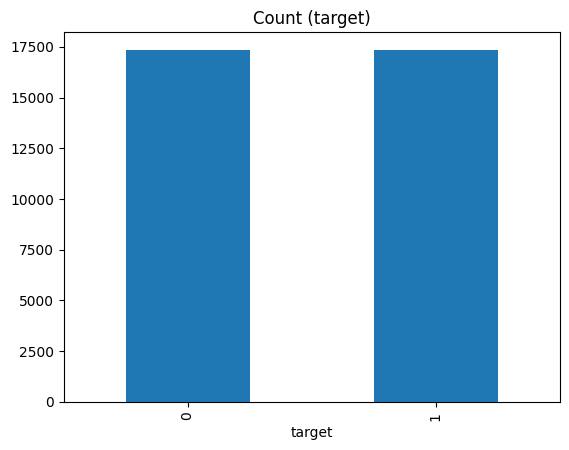

In [ ]:
# Random under-sampling
df_class_0_under = df_class_0.sample(n=count_class_1, random_state=42)  # sample from class 0
X_under = pd.concat([df_class_0_under, df_class_1], axis=0)
y_under = pd.concat([y_train[y_train == 0].loc[df_class_0_under.index],
                     y_train[y_train == 1]], axis=0)

print('Random under-sampling:')
print(y_under.value_counts())

# Plot
y_under.value_counts().plot(kind='bar', title='Count (TARGET)');


# Random over-sampling


Random over-sampling:
target
0    458814
1    458814
Name: count, dtype: int64


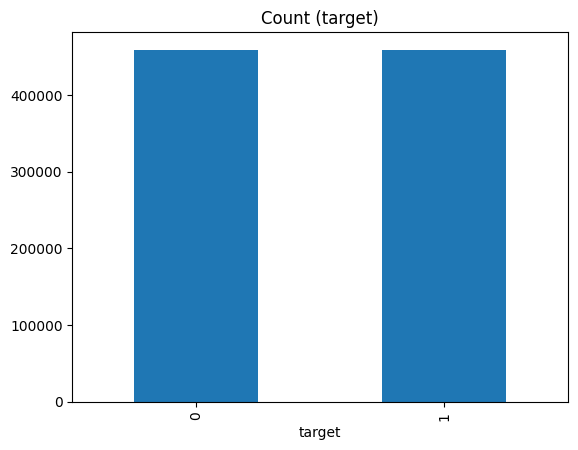

In [ ]:
from sklearn.utils import resample

# Random over-sampling
df_class_1_over = df_class_1.sample(n=count_class_0, replace=True, random_state=42)  # sample with replacement
X_over = pd.concat([df_class_0, df_class_1_over], axis=0)
y_over = pd.concat([y_train[y_train == 0],
                    y_train[y_train == 1].loc[df_class_1_over.index]], axis=0)

print('Random over-sampling:')
print(y_over.value_counts())

# Plot
y_over.value_counts().plot(kind='bar', title='Count (TARGET)');


# Python imbalanced-learn module
A number of more sophisticated resapling techniques have been proposed in the scientific literature.

For example, we can cluster the records of the majority class, and do the under-sampling by removing records from each cluster, thus seeking to preserve information. In over-sampling, instead of creating exact copies of the minority class records, we can introduce small variations into those copies, creating more diverse synthetic samples.

Let's apply some of these resampling techniques, using the Python library imbalanced-learn. It is compatible with scikit-learn and is part of scikit-learn-contrib projects.

In [ ]:
import imblearn



For ease of visualization, let's create a small unbalanced sample dataset using the make_classification method:


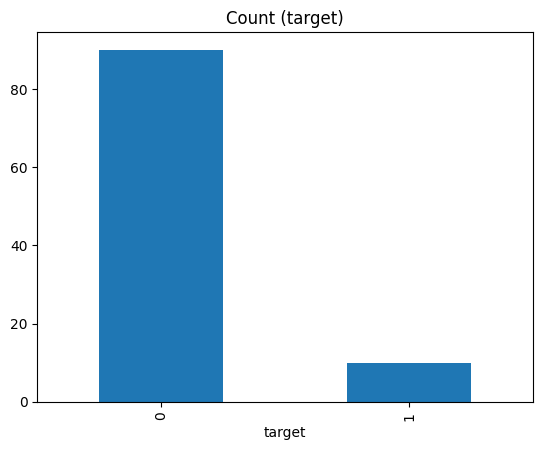

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate imbalanced dataset
X, y = make_classification(
    n_samples=100,
    n_features=20,
    n_informative=3,
    n_redundant=1,
    n_clusters_per_class=1,
    n_classes=2,
    weights=[0.9, 0.1],
    flip_y=0,
    class_sep=1.5,
    random_state=10
)

# Create DataFrame
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['TARGET'] = y

# Plot target counts
df['TARGET'].value_counts().plot(kind='bar', title='Count (TARGET)')
plt.show()


2-dimensional plot function, plot_2d_space, to see the data distribution:

In [ ]:
def plot_2d_space(X, y, label='Classes'):   
    colors = ['#1F77B4', '#FF7F0E']
    markers = ['o', 's']
    for l, c, m in zip(np.unique(y), colors, markers):
        plt.scatter(
            X[y==l, 0],
            X[y==l, 1],
            c=c, label=l, marker=m
        )
    plt.title(label)
    plt.legend(loc='upper right')
    plt.show()



Because the dataset has many dimensions (features) and our graphs will be 2D, we will reduce the size of the dataset using Principal Component Analysis (PCA):


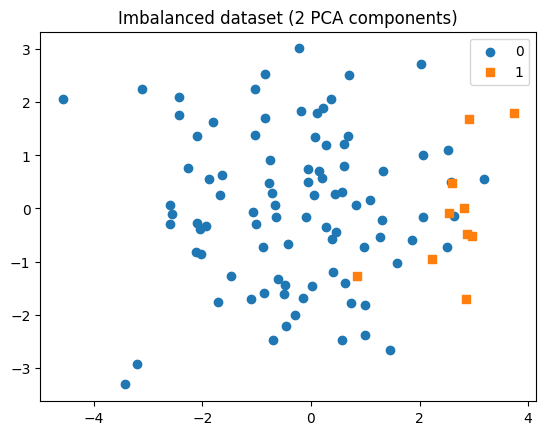

In [ ]:


from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(X)

plot_2d_space(X, y, 'Imbalanced dataset (2 PCA components)')




Random under-sampling and over-sampling with imbalanced-learn

<mark>Note here X is X_pca</mark>

Removed indexes: [1, 2, 3, 5, 6, 7, 10, 11, 12, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 68, 69, 72, 73, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


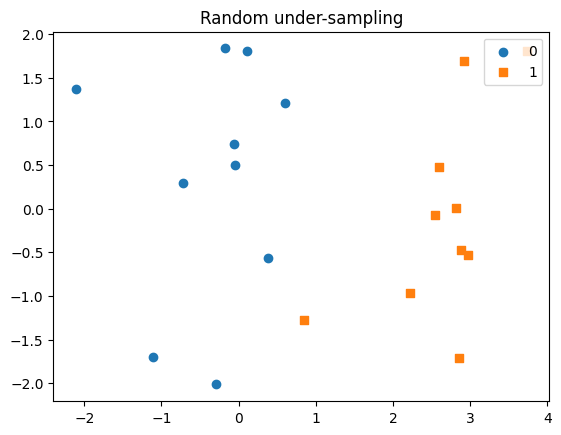

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize the under-sampler
rus = RandomUnderSampler(random_state=42)

# Fit and resample
X_rus, y_rus = rus.fit_resample(X, y)

# Get removed indexes (optional)
removed_indices = list(set(range(len(X))) - set(rus.sample_indices_))
print('Removed indexes:', removed_indices)

# Plot the 2D space
plot_2d_space(X_rus, y_rus, 'Random under-sampling')


80 new randomly picked points


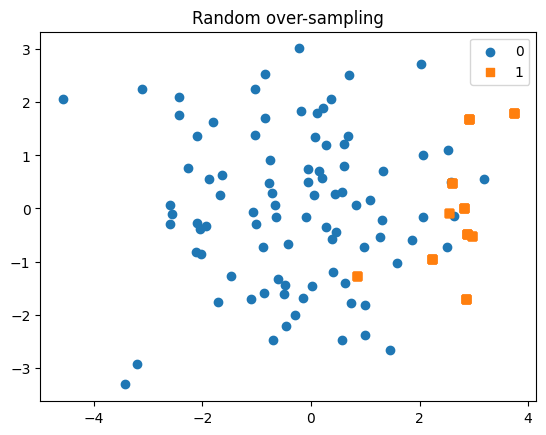

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Create the oversampler
ros = RandomOverSampler(random_state=42)

# Fit and resample
X_ros, y_ros = ros.fit_resample(X, y)  # X can be PCA or original features

# How many new points were added
print(X_ros.shape[0] - X.shape[0], 'new randomly picked points')

# Plot in 2D
plot_2d_space(X_ros, y_ros, 'Random over-sampling')


# Under-sampling: Tomek links

Tomek links are pairs of very close instances, but of opposite classes. Removing the instances of the majority class of each pair increases the space between the two classes, facilitating the classification process.



In the code below, we'll use ratio='majority' to resample the majority class.


Removed 4 points


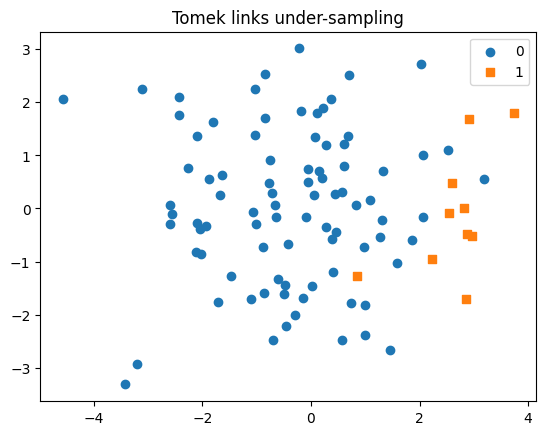

In [ ]:
from imblearn.under_sampling import TomekLinks

# Create TomekLinks object
tl = TomekLinks()

# Fit and resample
X_tl, y_tl = tl.fit_resample(X, y)  # X can be PCA or original features

# How many points were removed
print(f'Removed {X.shape[0] - X_tl.shape[0]} points')

# Plot in 2D
plot_2d_space(X_tl, y_tl, 'Tomek links under-sampling')


# Under-sampling: Cluster Centroids
This technique performs under-sampling by generating centroids based on clustering methods. The data will be previously grouped by similarity, in order to preserve information.

In this example we will pass the {0: 10} dict for the parameter ratio, to preserve 10 elements from the majority class (0), and all minority class (1) .

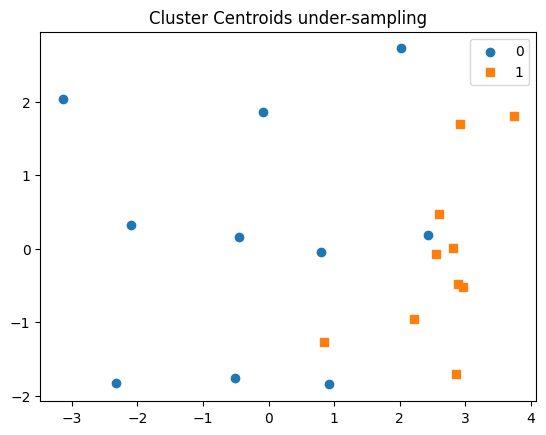

In [ ]:
from imblearn.under_sampling import ClusterCentroids

# Create ClusterCentroids object
# 'sampling_strategy' defines the number of samples per class after resampling
cc = ClusterCentroids(sampling_strategy={0: 10})  # reduce class 0 to 10 samples

# Fit and resample
X_cc, y_cc = cc.fit_resample(X, y)

# Plot
plot_2d_space(X_cc, y_cc, 'Cluster Centroids under-sampling')


# Over-sampling: SMOTE
SMOTE (Synthetic Minority Oversampling TEchnique) consists of synthesizing elements for the minority class, based on those that already exist. It works randomly picingk a point from the minority class and computing the k-nearest neighbors for this point. The synthetic points are added between the chosen point and its neighbors.



We'll use ratio='minority' to resample the minority class.


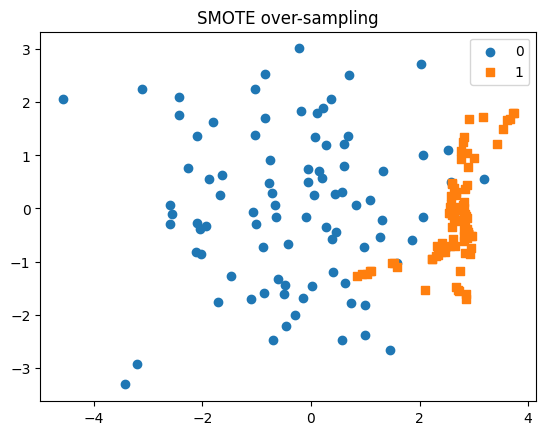

In [ ]:
from imblearn.over_sampling import SMOTE

# SMOTE object, now use 'sampling_strategy' instead of 'ratio'
smote = SMOTE(sampling_strategy='minority', random_state=42)

# Fit and resample
X_sm, y_sm = smote.fit_resample(X, y)

# Plot the new balanced dataset
plot_2d_space(X_sm, y_sm, 'SMOTE over-sampling')

# Over-sampling followed by under-sampling

Now, we will do a combination of over-sampling and under-sampling, using the SMOTE and Tomek links techniques:

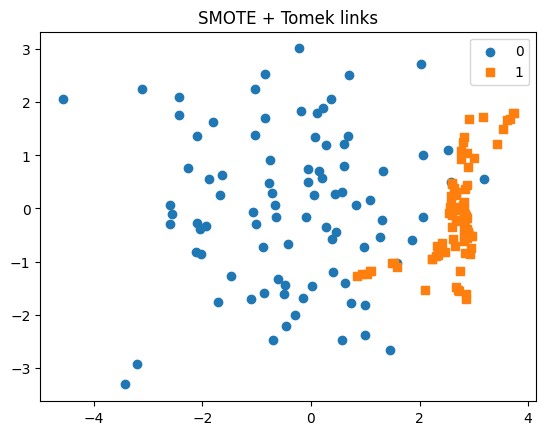

In [ ]:
from imblearn.combine import SMOTETomek

# SMOTE + Tomek links, use sampling_strategy instead of ratio
smt = SMOTETomek(sampling_strategy='auto', random_state=42)

# Fit and resample
X_smt, y_smt = smt.fit_resample(X, y)

# Plot the new dataset
plot_2d_space(X_smt, y_smt, 'SMOTE + Tomek links')


In [ ]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)




Log transform


In [ ]:
# # Plot log transform results
# fig=plt.figure(figsize=(12,20))
# for i, col in enumerate(['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Expenditure']):
#     plt.subplot(6,2,2*i+1)
#     sns.histplot(X_train[col], binwidth=100)
#     plt.ylim([0,200])
#     plt.title(f'{col} (original)')
    
#     plt.subplot(6,2,2*i+2)
#     sns.histplot(np.log(1+X_train[col]), color='C1')
#     plt.ylim([0,200])
#     plt.title(f'{col} (log-transform)')
    
# fig.tight_layout()
# plt.show()

In [ ]:
# # Apply log transform
# for col in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Expenditure']:
#     X_train[col]=np.log(1+X_train[col])
#     X_test[col]=np.log(1+X_test[col])



Encoding and scaling



We will use column transformers to be more professional. It's also good practice.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import OneHotEncoder


numerical_cols = [cname for cname in X_train.columns if X_train[cname].dtype in ['int64', 'float64']]
categorical_cols = [cname for cname in X_train.columns if X_train[cname].dtype == "object"]

# Scale numerical data to have mean=0 and variance=1
numerical_transformer = Pipeline([('scaler', StandardScaler())])

# One-hot encode categorical data
categorical_transformer = Pipeline([('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))])

# Combine preprocessing
ct = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)],
        remainder='passthrough')

# Apply preprocessing
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

# Print new shape
print('Training set shape:', X_train.shape)

Training set shape: (6954, 36)


# Imbalanced Data

<Axes: title={'center': 'Count (target)'}, xlabel='target'>

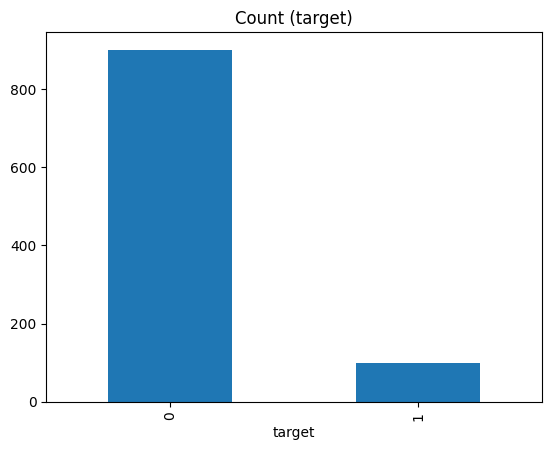

In [ ]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_classes=2, class_sep=1.5, weights=[0.9, 0.1],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=1000, random_state=10
)

df = pd.DataFrame(X)
df['target'] = y
df.target.value_counts().plot(kind='bar', title='Count (target)')


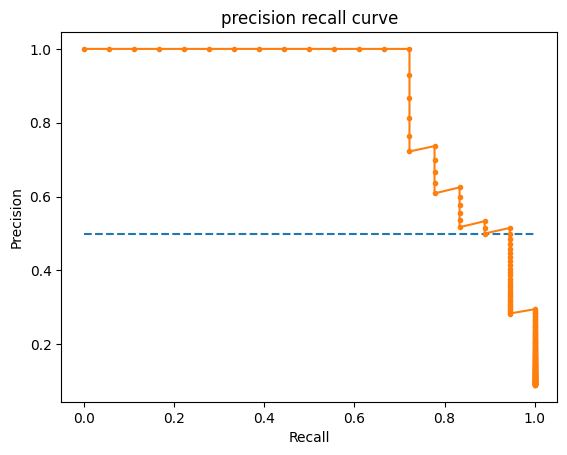

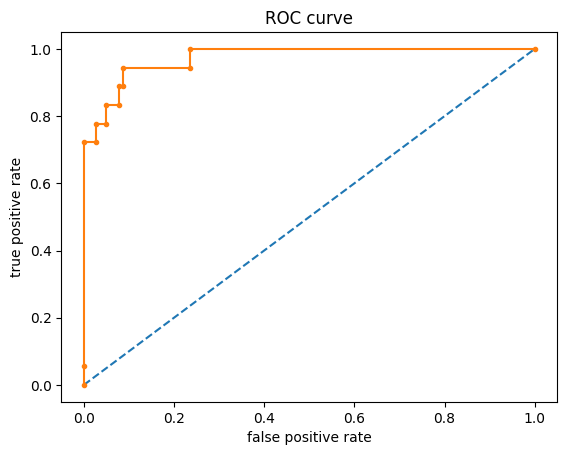

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve


def logistic(X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=1)
    lr=LogisticRegression()
    lr.fit(X_train,y_train)
    prob=lr.predict_proba(X_test)
    return (prob[:,1],y_test)

probs,y_test=logistic(X,y)

def plot_pre_curve(y_test,probs):
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    plt.plot([0, 1], [0.5, 0.5], linestyle='--')
    # plot the precision-recall curve for the model
    plt.plot(recall, precision, marker='.')
    plt.title("precision recall curve")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    # show the plot
    plt.show()
    
def plot_roc(y_test,prob):
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    # plot no skill
    plt.plot([0, 1], [0, 1], linestyle='--')
    # plot the roc curve for the model
    plt.plot(fpr, tpr, marker='.')
    plt.title("ROC curve")
    plt.xlabel('false positive rate')
    plt.ylabel('true positive rate')
    # show the plot
    plt.show()



plot_pre_curve(y_test,probs)

plot_roc(y_test,probs)

T-SNE took 0.24 s
PCA took 0.0033 s
Truncated SVD took 0.0024 s


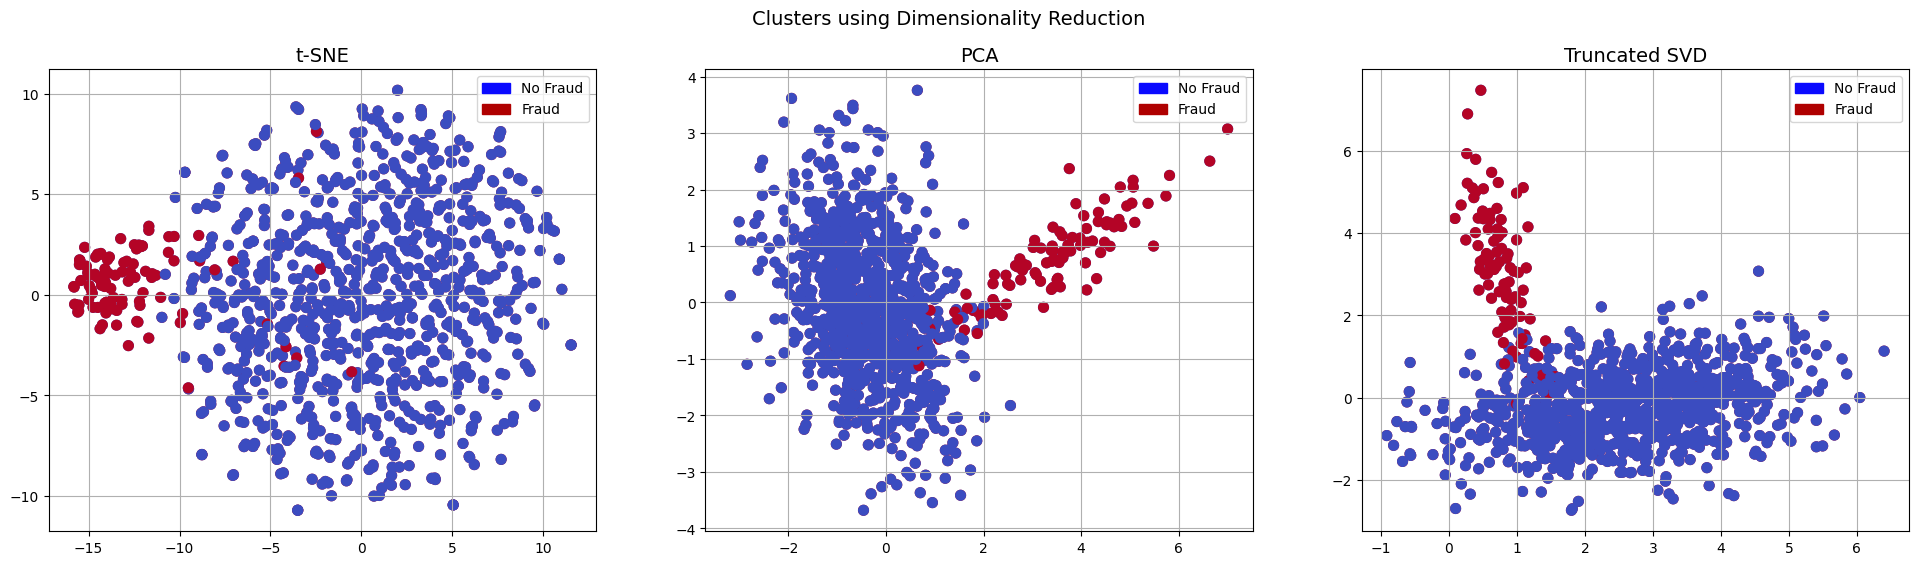

In [ ]:
import time
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches


def plot_2d_space(X_train, y_train,X=X,y=y ,label='Classes'):   
    colors = ['#1F77B4', '#FF7F0E']
    markers = ['o', 's']
    
    fig,(ax1,ax2)=plt.subplots(1,2, figsize=(8,4))
   
    for l, c, m in zip(np.unique(y), colors, markers):
        ax1.scatter(
            X_train[y_train==l, 0],
            X_train[y_train==l, 1],
            c=c, label=l, marker=m
        )
    for l, c, m in zip(np.unique(y), colors, markers):
        ax2.scatter(
            X[y==l, 0],
            X[y==l, 1],
            c=c, label=l, marker=m
        )
   
    ax1.set_title(label)
    ax2.set_title('original data')
    plt.legend(loc='upper right')
    plt.show()


# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))


f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])

# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()



Random under-sampling with imbalanced-learn


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import numpy as np

# initialize undersampler
rus = RandomUnderSampler(random_state=42)

# fit and resample
X_res, y_res = rus.fit_resample(X, y)

# indices of kept samples in the original dataset
kept_indices = rus.sample_indices_

# optional: indices of dropped samples
all_indices = np.arange(len(X))
dropped_indices = np.setdiff1d(all_indices, kept_indices)

print("Number of dropped indices:", len(dropped_indices))


Number of dropped indices: 800


- Let's try fit and predict on this data and observe the outcome.



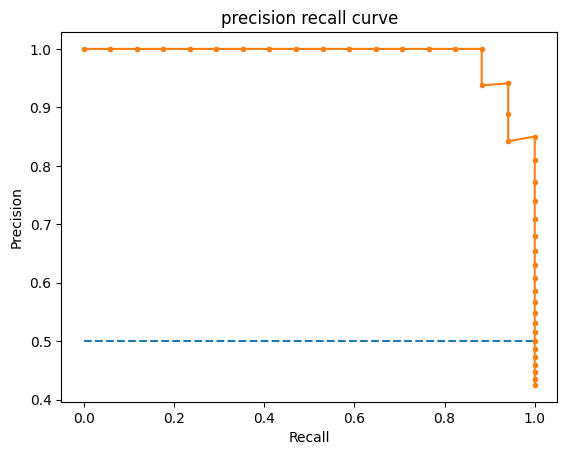

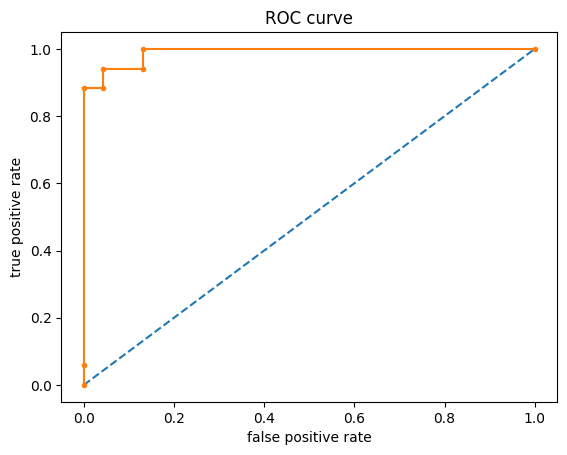

In [ ]:
probs,y_test=logistic(X_res,y_res)
plot_pre_curve(y_test,probs)
plot_roc(y_test,probs)


Random over-sampling with imbalanced-learn


The new data contains 1800 rows.
Class distribution after oversampling: {0: 900, 1: 900}


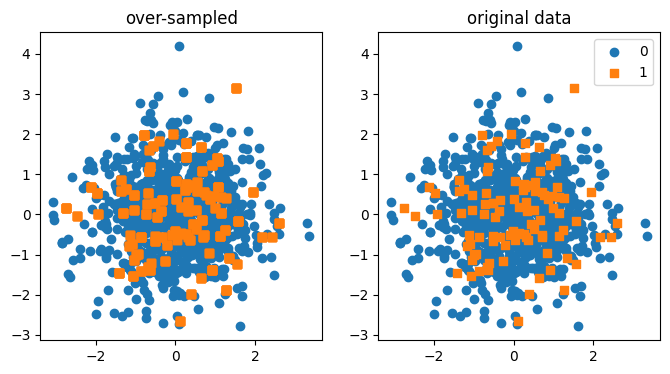

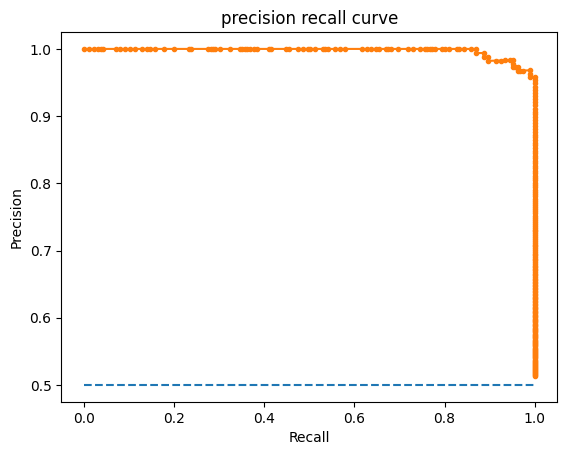

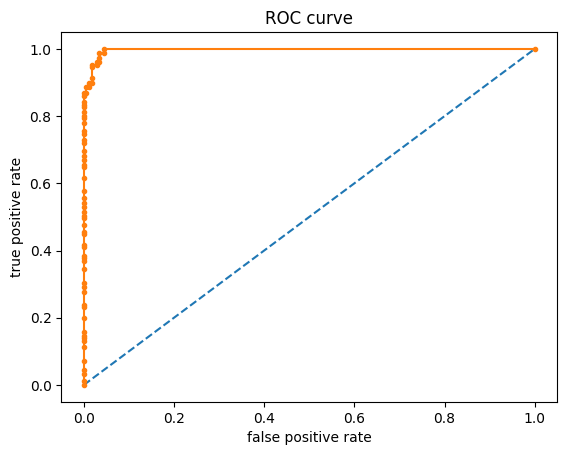

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

# Initialize oversampler
ros = RandomOverSampler(random_state=42)

# Resample
X_ran, y_ran = ros.fit_resample(X, y)

print(f'The new data contains {X_ran.shape[0]} rows.')

# Optional: check class distribution
unique, counts = np.unique(y_ran, return_counts=True)
print("Class distribution after oversampling:", dict(zip(unique, counts)))

# Plot 2D space (assumes you have plot_2d_space defined)
plot_2d_space(X_ran, y_ran, X, y, 'over-sampled')
probs,y_test=logistic(X_ran,y_ran)
plot_pre_curve(y_test,probs)
plot_roc(y_test,probs)



Under-sampling: Tomek links

Tomek links are pairs of very close instances, but of opposite classes. Removing the instances of the majority class of each pair increases the space between the two classes, facilitating the classification process.

Number of dropped samples: 4


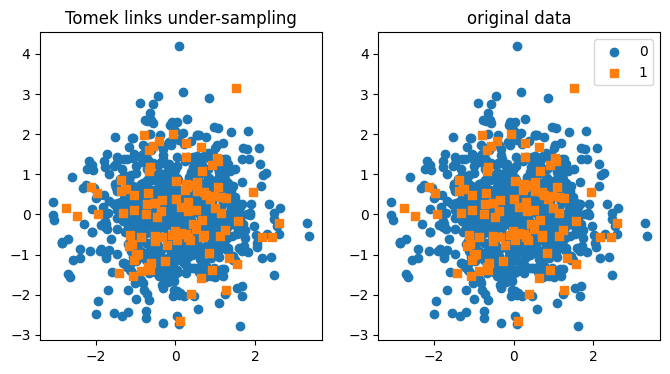

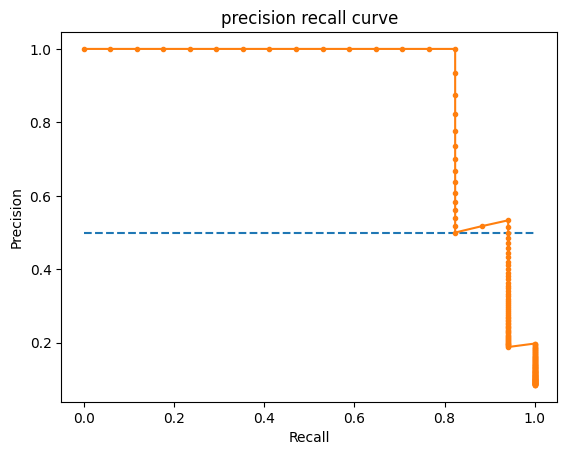

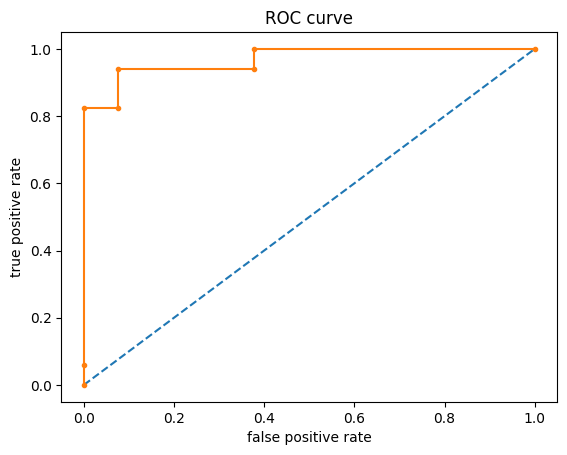

In [ ]:
from imblearn.under_sampling import TomekLinks
import numpy as np

# Initialize sampler
tl = TomekLinks(sampling_strategy='majority')  # 'ratio' is old, now use sampling_strategy

# Fit and resample
X_tl, y_tl = tl.fit_resample(X, y)

# Indices of samples kept
kept_indices = tl.sample_indices_

# Optional: indices of removed samples
all_indices = np.arange(len(X))
dropped_indices = np.setdiff1d(all_indices, kept_indices)
print("Number of dropped samples:", len(dropped_indices))

# Plot 2D space (assumes plot_2d_space is defined)
plot_2d_space(X_tl, y_tl, X, y, 'Tomek links under-sampling')

probs,y_test=logistic(X_tl,y_tl)
plot_pre_curve(y_test,probs)
plot_roc(y_test,probs)


Over-sampling: SMOTE

SMOTE (Synthetic Minority Oversampling TEchnique) consists of synthesizing elements for the minority class, based on those that already exist. It works randomly picingk a point from the minority class and computing the k-nearest neighbors for this point. The synthetic points are added between the chosen point and its neighbors.


<mark>Very nice kernel indeed. However, oversampling (SMOTE) should only be applied after splitting the data into folds imo. Applying SMOTE before splitting leaks data (the oversampled portion) to the train sets and therefore, overfitting the validation sets, hence the very high AUC as being shown.</mark>


<mark>Nice kernel! For oversampling, I've found that SMOTE combined with edited nearest neighbors (ENN) tends to perform slightly better than SMOTE, but takes longer to run. It's definitely worth looking into. Here's the code for that: https://imbalanced-learn.readthedocs.io/en/stable/generated/imblearn.combine.SMOTEENN.html</mark>

Class distribution after SMOTE: {0: 900, 1: 900}


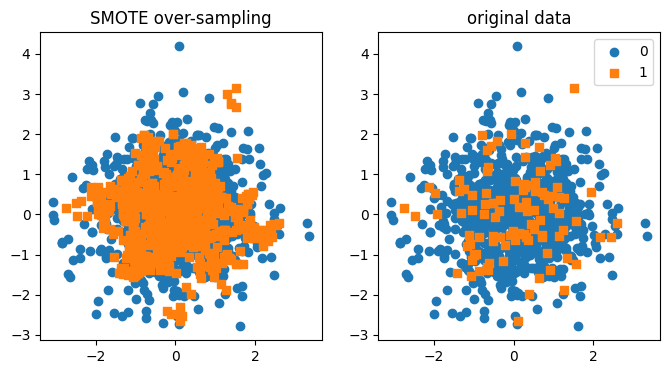

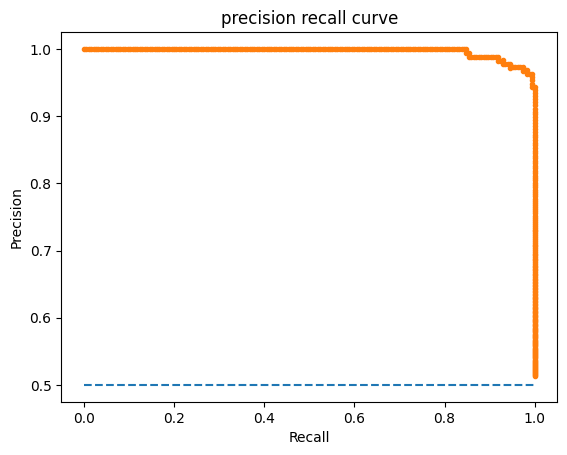

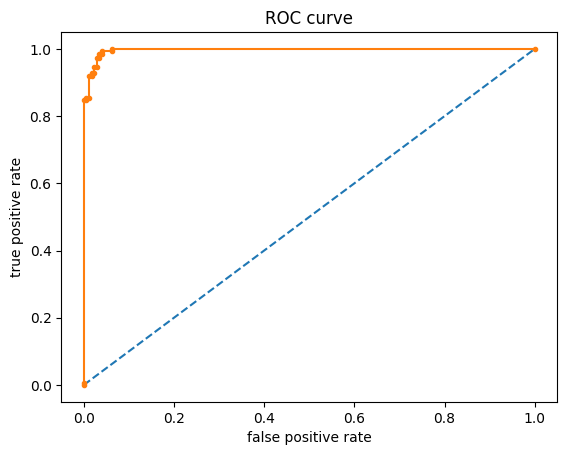

In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Initialize SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

# Fit and resample
X_sm, y_sm = smote.fit_resample(X, y)

# Optional: check class distribution after SMOTE
unique, counts = np.unique(y_sm, return_counts=True)
print("Class distribution after SMOTE:", dict(zip(unique, counts)))

# Plot 2D space (assumes plot_2d_space is defined)
plot_2d_space(X_sm, y_sm, X, y, 'SMOTE over-sampling')


probs,y_test=logistic(X_sm,y_sm)
plot_pre_curve(y_test,probs)

plot_roc(y_test,probs)

# Fill missing values

In [ ]:
X_train[cat_cols] = X_train[cat_cols].fillna('Unknown')
X_test[cat_cols] = X_test[cat_cols].fillna('Unknown')

This need special treatment

In [ ]:
# print(X_train['attitude_worried_shutdown'].value_counts())
# print(X_train['current_problem_cash_flow'].value_counts())

# New Features

# V1
showed good improvment

In [ ]:
from sklearn.model_selection import KFold
import numpy as np


TARGET = 'has_condition'
orig = X_train.copy()
orig[TARGET] = y_train
BASE = X_train.columns.tolist()
def kfold_target_encoding(X, y, col, n_splits=5):
    X_new = X.copy()
    global_mean = y.mean()
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_new[f"te_{col}"] = np.nan
    
    for train_idx, val_idx in kf.split(X):
        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        mean_map = X_tr.groupby(col).apply(lambda x: y_tr.loc[x.index].mean())

        X_new.iloc[val_idx, X_new.columns.get_loc(f"te_{col}")] = X_val[col].map(mean_map)

    X_new[f"te_{col}"] = X_new[f"te_{col}"].fillna(global_mean)
    return X_new[f"te_{col}"]


for col in BASE:
    X_train[f"te_{col}"] = kfold_target_encoding(X_train, y_train, col)



global_mean = y_train.mean()

for col in BASE:
    mean_map = X_train.groupby(col)[f"te_{col}"].mean()
    X_test[f"te_{col}"] = X_test[col].map(mean_map).fillna(global_mean)


for col in BASE:
    count_map = X_train[col].value_counts()
    X_train[f"count_{col}"] = X_train[col].map(count_map)
    X_test[f"count_{col}"]  = X_test[col].map(count_map).fillna(0)


ORIG = [f"te_{col}" for col in BASE] + [f"count_{col}" for col in BASE]
FEATURES = BASE + ORIG




In [ ]:
new_features = list(set(X_train.columns) - set(X_train_original.columns))
print("New features added:")
print(new_features)
print(X_train[new_features].dtypes)


New features added:
['lifestyle_risk', 'count_ldl_chol', 'bp_category', 'te_pulse_rate', 'te_ethnic_group', 'count_income_class', 'te_has_cardiovascular', 'bp_bmi', 'age_group', 'count_daily_screen_hrs', 'count_whr', 'count_hdl_chol', 'count_nutrition_index', 'count_ethnic_group', 'te_tobacco_use', 'bmi_category', 'hypertension_stage', 'te_has_hypertension', 'count_family_diabetes', 'count_body_mass_idx', 'count_bp_systolic', 'age_chol', 'te_whr', 'te_bp_diastolic', 'hypertension_flag', 'te_weekly_alcohol', 'count_tobacco_use', 'count_bp_diastolic', 'te_total_chol', 'count_has_hypertension', 'lifestyle_level', 'te_family_diabetes', 'bp_ratio', 'te_daily_screen_hrs', 'te_daily_sleep_hrs', 'bmi_chol', 'count_weekly_exercise_min', 'count_pulse_rate', 'te_bp_systolic', 'count_daily_sleep_hrs', 'age_bmi', 'age_category', 'te_years_old', 'te_body_mass_idx', 'bmi_squared', 'te_weekly_exercise_min', 'medical_risk', 'count_work_status', 'medical_history_count', 'count_weekly_alcohol', 'age_squa

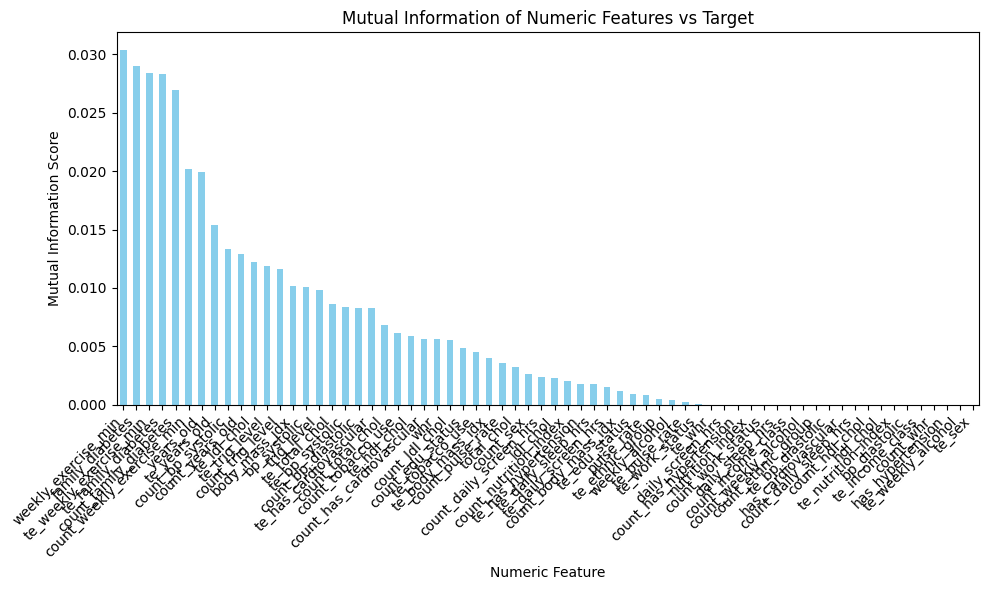

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

# Numeric features
num_cols = X_train.select_dtypes(include='number').columns
X_num = X_train[num_cols].copy()

# Simple imputer: fill NaN with median (robust)
imputer = SimpleImputer(strategy='median')
X_num_imputed = pd.DataFrame(imputer.fit_transform(X_num), columns=num_cols)

from sklearn.feature_selection import mutual_info_classif


mi_scores = mutual_info_classif(X_num_imputed, y_train, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
mi_series.plot(kind='bar', color='skyblue')
plt.title("Mutual Information of Numeric Features vs Target")
plt.ylabel("Mutual Information Score")
plt.xlabel("Numeric Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



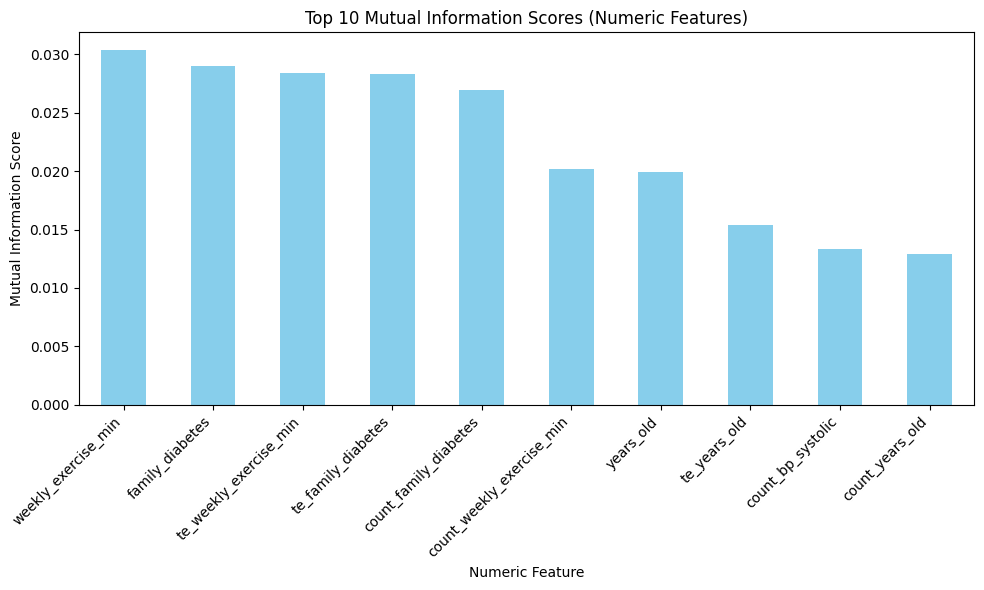

In [ ]:
# Take top 10 features
top10_mi = mi_series.head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top10_mi.plot(kind='bar', color='skyblue')
plt.title("Top 10 Mutual Information Scores (Numeric Features)")
plt.ylabel("Mutual Information Score")
plt.xlabel("Numeric Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


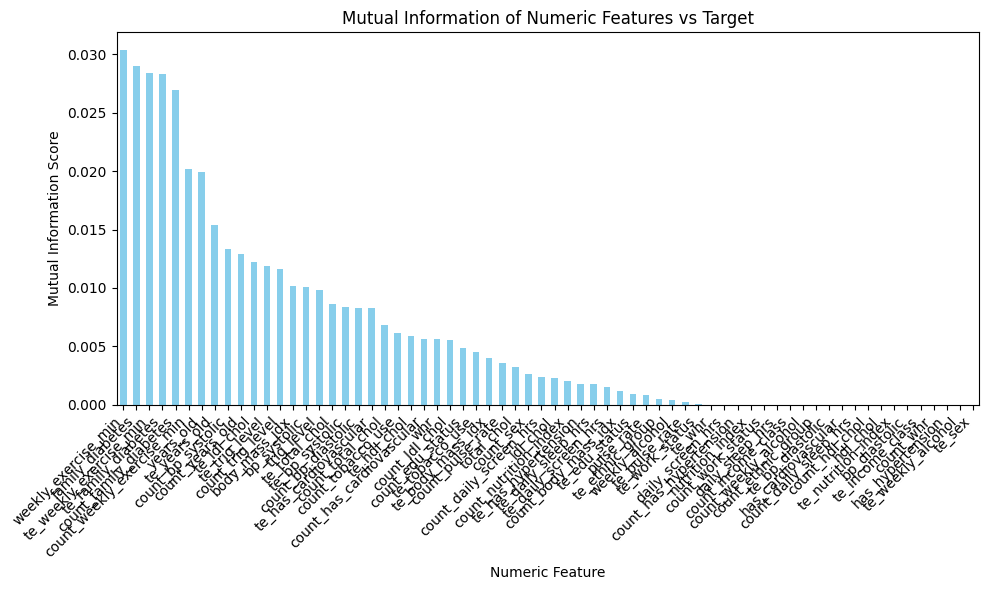

Columns with MI < 0.005: ['count_edu_status', 'te_tobacco_use', 'te_body_mass_idx', 'count_pulse_rate', 'total_chol', 'count_sex', 'count_daily_screen_hrs', 'ldl_chol', 'count_nutrition_index', 'te_has_hypertension', 'te_daily_sleep_hrs', 'te_daily_screen_hrs', 'count_body_mass_idx', 'te_edu_status', 'pulse_rate', 'te_ethnic_group', 'weekly_alcohol', 'te_pulse_rate', 'te_work_status', 'te_whr', 'daily_screen_hrs', 'count_has_hypertension', 'nutrition_index', 'count_work_status', 'daily_sleep_hrs', 'count_income_class', 'count_weekly_alcohol', 'count_ethnic_group', 'te_bp_diastolic', 'has_cardiovascular', 'count_daily_sleep_hrs', 'count_hdl_chol', 'hdl_chol', 'te_nutrition_index', 'bp_diastolic', 'te_income_class', 'count_whr', 'has_hypertension', 'te_weekly_alcohol', 'te_sex']


In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# ---------------------------
# Numeric features
# ---------------------------
num_cols = X_train.select_dtypes(include='number').columns
X_num = X_train[num_cols].copy()

# Fill NaN with median
imputer = SimpleImputer(strategy='median')
X_num_imputed = pd.DataFrame(imputer.fit_transform(X_num), columns=num_cols)

# ---------------------------
# Compute mutual information
# ---------------------------
# Ensure target is numeric
if y_train.dtype == 'object':
    y_encoded, _ = pd.factorize(y_train)
else:
    y_encoded = y_train.values

mi_scores = mutual_info_classif(X_num_imputed, y_encoded, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False)

# ---------------------------
# Plot MI
# ---------------------------
plt.figure(figsize=(10,6))
mi_series.plot(kind='bar', color='skyblue')
plt.title("Mutual Information of Numeric Features vs Target")
plt.ylabel("Mutual Information Score")
plt.xlabel("Numeric Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---------------------------
# Columns with MI < 0.005
# ---------------------------
low_mi_cols = mi_series[mi_series < 0.005].index.tolist()
print("Columns with MI < 0.005:", low_mi_cols)


Index(['sex', 'ethnic_group', 'edu_status', 'income_class', 'tobacco_use',
       'work_status'],
      dtype='object')


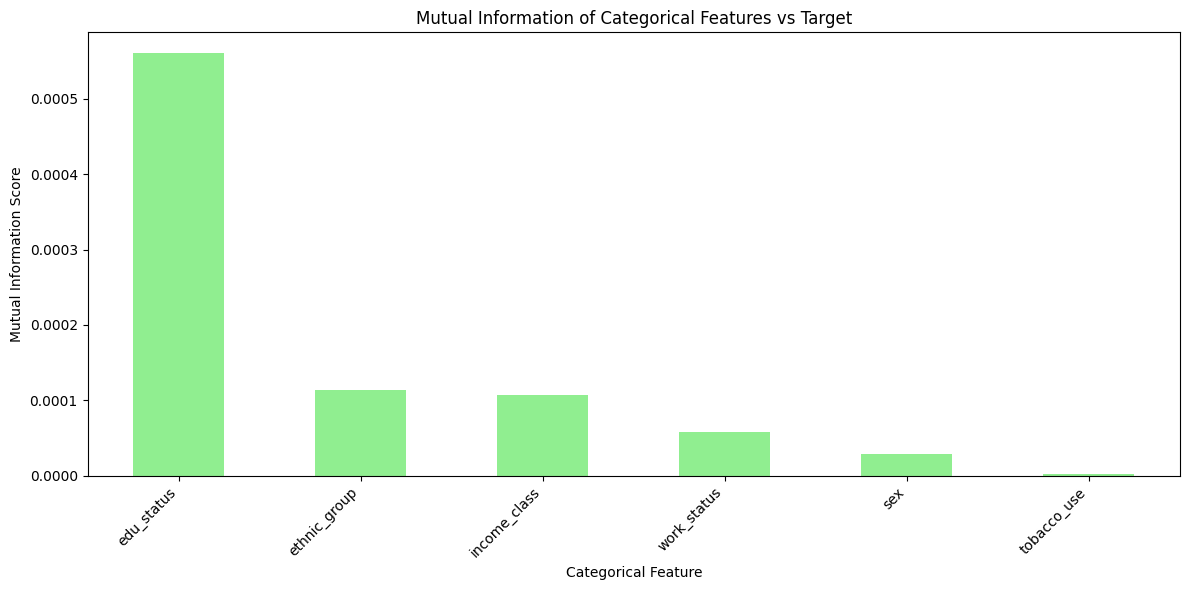

Top categorical features by MI: ['edu_status', 'ethnic_group', 'income_class', 'work_status', 'sex', 'tobacco_use']


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import matplotlib.pyplot as plt

# Copy dataset
train_df = X_train.copy()
train_df['Target'] = y_train

# Categorical features
cat_cols = train_df.select_dtypes(include=['object', 'category', 'bool']).columns
X_cat = train_df[cat_cols].copy()
print(cat_cols)

for col in X_cat.columns:
    if pd.api.types.is_categorical_dtype(X_cat[col]):
        # Add "Missing" as a category
        X_cat[col] = X_cat[col].cat.add_categories("Missing")
        
# Now fill missing values
X_cat.fillna("Missing", inplace=True)


X_cat = X_cat.astype(str)
# Encode categorical features numerically
encoder = OrdinalEncoder()
X_cat_encoded = pd.DataFrame(encoder.fit_transform(X_cat), columns=cat_cols)


y = train_df['Target']

mi_scores_cat = mutual_info_classif(X_cat_encoded, y, discrete_features=True, random_state=42)
mi_cat_series = pd.Series(mi_scores_cat, index=cat_cols).sort_values(ascending=False)


plt.figure(figsize=(12,6))
mi_cat_series.plot(kind='bar', color='lightgreen')
plt.title("Mutual Information of Categorical Features vs Target")
plt.ylabel("Mutual Information Score")
plt.xlabel("Categorical Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Select top 6 categorical features
top_categorical = mi_cat_series.head(6).index.tolist()
print("Top categorical features by MI:", top_categorical)

In [ ]:
# List of low-MI columns
low_mi_cols = [
    'chol_ratio', 'count_whr', 'chol_squared', 'count_trig_level', 'count_body_mass_idx',
    'te_has_cardiovascular', 'te_total_chol', 'bp_category', 'nutrition_index', 'te_trig_level',
    'te_income_class', 'cholesterol_ratio', 'hypertension_stage', 'count_work_status',
    'count_ethnic_group', 'count_total_chol', 'hdl_chol', 'count_bp_diastolic', 'weekly_alcohol',
     'hypertension_flag', 'chol_hdl', 'te_has_hypertension', 'te_weekly_alcohol',
    'te_whr', 'whr', 'daily_screen_hrs', 'edu_status', 'count_nutrition_index', 'count_ldl_chol',
    'te_work_status', 'te_bp_diastolic', 'has_hypertension', 'te_hdl_chol', 'te_pulse_rate',
    'count_daily_screen_hrs', 'te_ethnic_group', 'te_body_mass_idx',
    'te_daily_screen_hrs', 'te_daily_sleep_hrs', 'te_nutrition_index', 'te_sex', 'te_tobacco_use',
    'te_edu_status', 'has_cardiovascular', 'work_status', 'count_has_cardiovascular',
    'count_has_hypertension', 'sex', 'tobacco_use', 'count_tobacco_use', 'count_weekly_alcohol',
    'income_class', 'count_sex', 'count_hdl_chol', 'count_daily_sleep_hrs', 'count_pulse_rate'
]

# Drop from X_train and X_test
X_train = X_train.drop(columns=[col for col in low_mi_cols if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in low_mi_cols if col in X_test.columns])

print("Shape of X_train after dropping low-MI columns:", X_train.shape)
print("Shape of X_test after dropping low-MI columns:", X_test.shape)


Shape of X_train after dropping low-MI columns: (18964, 39)
Shape of X_test after dropping low-MI columns: (4742, 39)


In [ ]:
X_train.shape

(18964, 37)

In [ ]:
import pandas as pd
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

X_train shape: (476169, 59)
X_test shape: (119043, 59)


In [ ]:
X_train_encoded.shape

(476169, 59)

In [ ]:

# =========================
# 4️⃣ Impute missing values
# =========================
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_ft),
                               columns=X_train_ft.columns, index=X_train_ft.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_ft),
                              columns=X_test_ft.columns, index=X_test_ft.index)

# =========================
# 5️⃣ Scale numeric features
# =========================
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed),
                              columns=X_train_imputed.columns, index=X_train_imputed.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed),
                             columns=X_test_imputed.columns, index=X_test_imputed.index)

# =========================
# 6️⃣ Train Random Forest
# =========================
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# =========================
# 7️⃣ Evaluate
# =========================
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Log Loss:", log_loss(y_test, y_pred_proba))

# =========================
# ✅ X_train_scaled and X_test_scaled now contain original + interaction features
# You can use them for any other model
# =========================


,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
id,,,,,,,,,,,,,,,,,,,,,
1265,C,27,No,No,No,No,No,40000.0,10000,30000,...,Never had,Never had,Never had,False,<NA>,NaN,NaN,False,NaN,NaN
5303,B,34,Don’t know or N/A,Don’t know or N/A,No,Don't know,Yes,97.0,300,97,...,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,False,Never had,Never had
4512,D,39,Yes,Yes,No,Yes,No,2500.0,4800,288000,...,NaN,NaN,NaN,False,0,Never had,Have now,<NA>,NaN,NaN
7452,D,38,No,Yes,No,Don't know,Don't know,500.0,5400,7200,...,NaN,NaN,NaN,True,2,Never had,Have now,<NA>,NaN,NaN
5765,C,36,Don’t know or N/A,No,No,Don't know,Don't know,700000.0,17000,8400000,...,Never had,Never had,Used to have but don't have now,True,<NA>,NaN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2344,D,27,Yes,Yes,No,Don't know,No,30.0,1080,1800,...,NaN,NaN,NaN,False,11,Never had,Have now,True,NaN,NaN
9076,D,52,Yes,No,No,No,Yes,NaN,300,2500,...,NaN,NaN,NaN,True,8,Never had,Never had,<NA>,NaN,NaN
5343,A,43,No,No,No,No,Yes,600.0,1000,2500,...,Have now,Never had,Never had,<NA>,8,Never had,Have now,<NA>,Never had,Never had


## AutoFeat

In [ ]:
import pandas as pd
from autofeat import AutoFeatClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, log_loss

# 1️⃣ Prepare features and target
X = df.drop(columns=['Target', 'ID', 'id'])
y = df['Target'].map({'Low':0, 'Medium':1, 'High':2})

# 2️⃣ Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3️⃣ Identify numeric and categorical
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# 4️⃣ Impute missing values
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# 5️⃣ Encode categorical as integers
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# 6️⃣ Apply AutoFeat
af_clf = AutoFeatClassifier(verbose=1, feateng_steps=2)
X_train_af = af_clf.fit_transform(X_train, y_train)
X_test_af = af_clf.transform(X_test)




2025-12-27 00:47:55,958 INFO: [AutoFeat] The 2 step feature engineering process could generate up to 33670 features.
2025-12-27 00:47:55,959 INFO: [AutoFeat] With 7694 data points this new feature matrix would use about 1.04 gb of space.
2025-12-27 00:47:55,965 INFO: [feateng] Step 1: transformation of original features


2025-12-27 00:47:58,516 INFO: [feateng] Generated 110 transformed features from 37 original features - done.
2025-12-27 00:47:58,520 INFO: [feateng] Step 2: first combination of features


2025-12-27 00:48:06,529 INFO: [feateng] Generated 10701 feature combinations from 10731 original feature tuples - done.


2025-12-27 00:48:08,668 INFO: [feateng] Generated altogether 10841 new features in 2 steps
2025-12-27 00:48:08,669 INFO: [feateng] Removing correlated features, as well as additions at the highest level
2025-12-27 00:48:19,499 INFO: [feateng] Generated a total of 7782 additional features


[featsel] Scaling data...

2025-12-27 00:48:23,896 INFO: [featsel] Feature selection run 1/5


done.


In [ ]:

# Train a simple classifier on AutoFeat features
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_transformed, y_train)

# Evaluate
y_pred = rf_model.predict(X_test_transformed)
y_pred_proba = rf_model.predict_proba(X_test_transformed)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_pred_proba))
